# 소득과 입지, 주거 구조로 캘리포니아 주택가격을 예측할 수 있는가

**작성자:** bolly0809-coder &nbsp;&nbsp;|&nbsp;&nbsp; **작성일:** 2026-09-02

[프로젝트 요약 · 핵심 결과 · 참고자료 · 회고](README.md)

데이터 품질 점검부터 EDA, 전처리, 모델 비교, 최종 CatBoost 진단과 SHAP 해석까지 순서대로 정리한 분석 노트북이다.

**열람 안내:** 그래프·표·모델 평가 결과는 노트북에 포함되어 있어 별도 파일 없이 확인할 수 있다. 각 단계에서 실행·저장한 코드와 출력을 합쳤으며, 실행 번호는 당시 단계별 기록을 유지했다. 통합 파일을 새로 전체 실행한 결과는 아니다.

**재실행 안내:** Python 3.13 환경에서 별도로 보유한 `helpers` 모듈과 `jussam` 및 분석 패키지가 필요하다. 이 공개 폴더에는 분석 모듈·전체 데이터·학습 모델을 배포하지 않는다. 모델링 단계의 저장 결과를 최종 평가 단계에서 읽으며, 학습과 튜닝에는 시간이 걸릴 수 있다.

## 분석 목차

[01. 분석 개요와 데이터 품질 점검](#stage-01) · [02. 탐색적 데이터 분석 (EDA)](#stage-02) · [03. 분석용 데이터 전처리](#stage-03) · [04. 회귀모델링과 하이퍼파라미터 튜닝](#stage-04) · [05. 최종모델 진단과 결과 해석](#stage-05)


<a id="stage-01"></a>

## #1. 분석 개요와 데이터 품질 점검

> 데이터의 구조·타입·중복·결측치를 점검하고 분석에 사용할 기초 통계량을 정리합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | jussam `california_housing` |
| 핵심 작업 | 구조 점검, 중복·결측치 처리, 범주형·연속형 기술통계 |
| 산출물 | 품질 점검 데이터와 기술통계표 |

**분석 목차:** [01. 분석 개요와 데이터 품질 점검](#stage-01) · [02. 탐색적 데이터 분석 (EDA)](#stage-02) · [03. 분석용 데이터 전처리](#stage-03) · [04. 회귀모델링과 하이퍼파라미터 튜닝](#stage-04) · [05. 최종모델 진단과 결과 해석](#stage-05)

---

### #01. 준비작업

#### 1. 라이브러리 참조


In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 2. 데이터 불러오기

In [2]:
origin = load_data("california_housing")
origin.head()

📚 1990년 미국 인구조사(Census)를 기반으로 캘리포니아 각 지역의 인구·주택·소득 특성과 주택 중위가격을 담아, 회귀 분석과 머신러닝 모델 실습에 널리 사용되는 대표적인 주택 가격 데이터 (출처: https://www.kaggle.com/datasets/camnugent/california-housing-prices)

    field               description
--  ------------------  --------------
 0  longitude           경도
 1  latitude            위도
 2  housing_median_age  주택 중위 연령
 3  total_rooms         총 방 수
 4  total_bedrooms      총 침실 수
 5  population          인구
 6  households          가구 수
 7  median_income       중위 소득
 8  median_house_value  주택 중위 가격



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41,880,129.000,322,126,8.325,452600,NEAR BAY
1,-122.220,37.860,21,7099,1106.000,2401,1138,8.301,358500,NEAR BAY
2,-122.240,37.850,52,1467,190.000,496,177,7.257,352100,NEAR BAY
3,-122.250,37.850,52,1274,235.000,558,219,5.643,341300,NEAR BAY
4,-122.250,37.850,52,1627,280.000,565,259,3.846,342200,NEAR BAY


### #02. 데이터 구조 점검

#### 1. 데이터 크기

In [3]:
print(f"데이터 크기: {origin.shape}")

데이터 크기: (20640, 10)


#### 2. 데이터 타입 점검

In [4]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  int64   
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


#### 3. 중복값 점검

In [5]:
df1 = my_qtcheck.check_duplicates(origin)

중복된 행의 수: 0


#### 4. 형식·표기·단위 점검 (1) - 연속형 변수

In [6]:
# 값을 검사할 필드 목록
fields = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

minmax = [] # 최소값과 최대값을 저장할 리스트

for field in fields:
    min_value = df1[field].min()
    max_value = df1[field].max()
    minmax.append({"min": min_value, "max": max_value})

# 최소값과 최대값을 데이터 프레임으로 변환하여 출력
minmax_df = DataFrame(minmax, index=fields)
minmax_df

,min,max
housing_median_age,1.000,52.000
total_rooms,2.000,39320.000
total_bedrooms,1.000,6445.000
population,3.000,35682.000
households,1.000,6082.000
median_income,0.500,15.000
median_house_value,14999.000,500001.000


#### 5. 형식·표기·단위 점검 (1) - 명목형 변수

In [7]:
df1['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### #03. 데이터 품질 점검

#### 1. 결측치 확인

In [8]:
my_qtcheck.check_missing_values(df1)

,Missing Count,Missing Ratio (%)
longitude,0,0.000
latitude,0,0.000
housing_median_age,0,0.000
total_rooms,0,0.000
total_bedrooms,207,1.003
population,0,0.000
households,0,0.000
median_income,0,0.000
median_house_value,0,0.000
ocean_proximity,0,0.000


#### 2. 결측치 제거

- 결측치 5% 미만이므로 삭제하고 진행

In [9]:
df2 = df1.dropna(subset=["total_bedrooms"])
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
longitude,0,0.000
latitude,0,0.000
housing_median_age,0,0.000
total_rooms,0,0.000
total_bedrooms,0,0.000
population,0,0.000
households,0,0.000
median_income,0,0.000
median_house_value,0,0.000
ocean_proximity,0,0.000


#### 3. 품질 점검 데이터셋 저장

In [10]:
df2.to_excel("california_housing_qtcheck.xlsx", index=False)

### #04. 기술 통계량

#### 1. 범주형 변수의 기술 통계량

In [11]:
category_desc = my_qtcheck.categorical_summary(df2, 
        save_path="california_housing_categorical_summary.xlsx")
category_desc

📊 컬럼 'ocean_proximity'의 value_counts():


,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
ISLAND,5
NEAR BAY,2270
NEAR OCEAN,2628


,ocean_proximity
count,20433
unique,5
top,<1H OCEAN
freq,9034


#### 2. 연속형 변수의 기술 통계량

In [12]:
desc_df = my_qtcheck.numerical_summary(df2, 
        save_path="california_housing_numerical_summary.xlsx")
desc_df.T

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000,20433.000,20433.000,20433.000,20433.000,20433.000,20433.000,20433.000,20433.000
mean,-119.571,35.633,28.633,2636.504,537.871,1424.947,499.433,3.871,206864.413
std,2.004,2.136,12.592,2185.270,421.385,1133.208,382.299,1.899,115435.667
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1450.000,296.000,787.000,280.000,2.564,119500.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.537,179700.000
75%,-118.010,37.720,37.000,3143.000,647.000,1722.000,604.000,4.744,264700.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000
rel_diff,-0.009,0.040,0.013,0.240,0.236,0.222,0.221,0.095,0.151
rdiff_flag,similar,similar,similar,diff,diff,diff,diff,similar,diff


##### 💡인사이트

##### (1) 중심 수준 — `rel_diff`로 평균과 중앙값의 거리를 잰다

- `rel_diff = |평균 − 중앙값| ÷ 중앙값` : 평균이 중앙값에서 **상대적으로 얼마나 벗어났는가**.
- 규모 변수(방 수 0.240 · 침실 수 0.236 · 인구 0.222 · 가구 수 0.221)는 평균이 중앙값보다 **22 ~ 24% 크다.**
- 주택 가격 0.151, 중위 소득 0.095, 주택 연령 0.013 순으로 격차가 줄어든다.

##### (2) 퍼짐과 안정성 — `rdiff_flag` 판정에 따라 처리를 나눈다

| 판정 | 기준 | 해당 변수 | 처리 방침 |
|---|---|---|---|
| `similar` | rel_diff < 0.1 | housing_median_age, median_income, longitude, latitude | **평균을 대표값으로 사용 가능** (결측 대체도 평균 허용) |
| `diff` | 0.1 ≤ rel_diff < 0.5 | total_rooms, total_bedrooms, population, households, median_house_value | **대표값·결측 대체 모두 중앙값**, 로그 변환 검토 |
| `large_diff` | rel_diff ≥ 0.5 | 없음 | — |

- `large_diff`가 하나도 없다 → 평균이 완전히 무너진 변수는 없고, **9개 중 5개만 중앙값 기준으로 전환**하면 된다.
- 단 `median_income`은 rel_diff 0.095로 **기준선 0.1 코앞의 경계값**이므로 `similar`로 단정하지 말고 관찰한다.
- 퍼짐의 크기는 변동계수(CV = 표준편차 ÷ 평균)로 확인한다. 규모 변수 **0.77 ~ 0.83(매우 불안정)** > 주택 가격 0.56 > 소득 0.49 > 주택 연령 **0.44(가장 안정)**.
- `diff` + 높은 CV가 겹치는 규모 변수는 **가구당 방 수·가구당 인구** 같은 비율형 파생변수로 정규화한다.

##### (3) 이상치 비율 — 대략적인 예측치

- IQR × 1.5 경계로 계산한 **사전 추정치**다. 실제 제거 전에 규모를 가늠하는 용도로만 본다.
- 상한 이상치: 방 수 6.3% · 침실 수 6.2% · 가구 수 5.9% · 인구 5.8% · 주택 가격 5.2% · 소득 3.3%.
- **하한 이상치는 전 변수 0%**, 위도·경도·주택 연령은 상하한 모두 0%.
- `rdiff_flag = diff`인 변수가 곧 이상치 5% 이상인 변수와 일치한다 → **두 지표가 같은 결론**을 가리킨다.

##### (4) 꼬리 방향

- 위도·경도·주택 연령은 `symmetric`, 나머지는 전부 `right tail` → **우측 꼬리만 존재**한다.
- 규모 변수는 왜도 3.4 ~ 5.0, 첨도 22 ~ 74로 극단적이다. 인구는 중앙값 1,166명 대비 최대 35,682명(**약 31배**) → `log_need = log`.
- `median_income`은 rel_diff는 `similar`이지만 왜도 1.645로 우측 꼬리다 → **중심 지표만으로 분포 형태를 판단할 수 없다.**
- **상한 절단 주의**: 주택 가격 500,001 달러에 985건(4.8%), 주택 연령 52년에 1,265건(6.2%)이 몰려 있다. 분포의 자연스러운 끝이 아니라 조사 시 **잘라낸 값**이므로, 주택 가격 꼬리가 완만해 보이는 것(왜도 0.978)을 그대로 믿으면 안 된다.
- **종합**: 이상치가 전부 상단에만 있으므로 이후 분석은 **상위 이상치 처리(중앙값 기준 전환 · 로그 변환 · 비율형 파생변수 · 절단 인지)** 에 집중한다.

<a id="stage-02"></a>

## #2. 탐색적 데이터 분석 (EDA)

> 단변량·이변량·다변량 분석을 통해 주택가격과 관련된 변수 및 전처리 방향을 결정합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | 품질 점검 완료 데이터와 기술통계표 |
| 핵심 작업 | 분포 확인, 상관분석, ANOVA, 독립변수 간 상관 점검 |
| 산출물 | 변수 채택 근거와 파생변수 설계 방향 |

**분석 목차:** [01. 분석 개요와 데이터 품질 점검](#stage-01) · [02. 탐색적 데이터 분석 (EDA)](#stage-02) · [03. 분석용 데이터 전처리](#stage-03) · [04. 회귀모델링과 하이퍼파라미터 튜닝](#stage-04) · [05. 최종모델 진단과 결과 해석](#stage-05)

---

### #01. 준비작업

#### 1. 라이브러리 참조


In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 2. 품질 점검 완료 데이터 셋 불러오기

In [2]:
origin = load_data("california_housing_qtcheck")
num_desc = load_data("california_housing_numerical_summary")
cat_desc = load_data("california_housing_categorical_summary")

📚 캘리포니아 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field               description
--  ------------------  --------------
 0  longitude           경도
 1  latitude            위도
 2  housing_median_age  주택 중위 연령
 3  total_rooms         총 방 수
 4  total_bedrooms      총 침실 수
 5  population          인구
 6  households          가구 수
 7  median_income       중위 소득
 8  median_house_value  주택 중위 가격
 9  ocean_proximity     해양 근처 위치

📚 캘리포니아 주택 가격 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 캘리포니아 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


#### 3. 타입 변환 (범주형 확정)

- 범주형 기술통계량 표의 컬럼명이 범주형 변수 목록이다.

In [3]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


#### 4. 서열척도 적용 (필요에 따라 수행)

- 범주형 범주에 대해서 서열척도를 적용할 변수에 대한 타입변환
  - 도메인지식이 필요하다
- 서열척도를 적용하지 않더라도 모델링에 영향을 주지는 않는다.
  - 시각화 출력 순서 유지 등을 위해서 처리

In [4]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


#### 5. 변수 유형 분류

- 분석에 사용할 변수를 범주형과 연속형으로 나눈다.
- 데이터에는 있지만 분석 대상으로 삼지 않을 변수는 `exclude_cols`에 나열해 두 목록에서 함께 제거한다.

In [5]:
target = "median_house_value"   # 종속변수 이름
target_is_continuous = True     # 종속변수 연속형 여부

# 분석 대상에서 제외할 변수
# -> 식별자(ID), 다른 변수와 중복되는 항목, 일반 변수로 다룰 수 없는 값 등을 나열한다.
# -> 이번 데이터셋에서는 위경도가 여기에 해당한다.
exclude_cols = ["longitude", "latitude"]

nominal_cols = my_qtcheck.get_categorical_column_names(df)  # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)    # 연속형 변수

if target_is_continuous:               # 종속변수가 연속형 변수라면?
    continuous_cols.remove(target)     # 연속형 변수 이름에서 종속변수 항목 제거 
else:                                  # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target)        # 범주형 변수 이름에서 종속변수 항목 제거

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다.
# -> 범주형에도 적용하므로 제외 대상이 범주형인 경우에도 그대로 동작한다.
continuous_cols = [c for c in continuous_cols if c not in exclude_cols]
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))
print("범주형   :", nominal_cols)
print("연속형   :", continuous_cols)
print("제외     :", exclude_cols)

종속변수 : median_house_value
종속변수 유형: 연속형
범주형   : ['ocean_proximity']
연속형   : ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
제외     : ['longitude', 'latitude']


#### 5. 컬럼 의미를 정리한 딕셔너리

In [6]:
column_means = {
    "median_house_value": "주택 중위 가격 (USD)",
    "longitude":          "경도",
    "latitude":           "위도",
    "housing_median_age": "주택 중위 연령",
    "total_rooms":        "총 방 수",
    "total_bedrooms":     "총 침실 수",
    "population":         "인구",
    "households":         "가구 수",
    "median_income":      "중위 소득",
    "ocean_proximity":    "해양 근접도"
}

#### 7. EDA 범위 정리

| 종속유형      | 독립유형      | 분석 유형 | 대상 변수                              | 적용 여부 | 비고                    |
|-----------|-----------|-------|------------------------------------|-------|-----------------------|
| 연속형       | 연속형       | 상관분석  | 연속형 독립변수 6종 → median_house_value   | 적용  | 종속·설명 모두 연속형          |
| 연속형       | 범주형(2집단)  | T검정   | -                                  | 미적용 | 2집단 범주형 없음            |
| 연속형       | 범주형(3집단+) | ANOVA | ocean_proximity → median_house_value | 적용  | 5집단 범주형 1종            |
| 범주형(2집단)  | 연속형       | T검정   | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(2집단)  | 범주형(2집단)  | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(2집단)  | 범주형(3집단+) | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(3집단+) | 연속형       | ANOVA | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(3집단+) | 범주형(2집단)  | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |
| 범주형(3집단+) | 범주형(3집단+) | 교차분석  | -                                  | 미적용 | 종속변수 타입이 연속형          |

- 종속변수 `median_house_value`가 연속형이므로 상위 3개 행만 후보가 되고, 그 중 해당 독립유형 변수가 실제로 존재하는 행만 적용된다.
- 연속형 독립변수 6종: `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`
- 범주형 독립변수 1종: `ocean_proximity` (5개 범주). 2집단이 아니므로 T검정은 건너뛰고 ANOVA만 수행한다.
  - 단, `ISLAND` 범주는 5건뿐이므로 사후검정 결과 해석 시 주의가 필요하다.
- `longitude`, `latitude` 2종은 `exclude_cols`에 지정해 위 표의 대상에서 제외했다.

##### 위·경도를 제외한 이유

- 위·경도는 하나의 개별 값이 아니라 **두 값이 함께 만드는 좌표** 정보이다.
- 단조 관계가 아니므로, 상관계수·왜도·이상치처럼 **변수를 하나씩 보는 진단으로는 신호를 잡을 수 없다.**
- 그러므로 표준 연속형 트랙에서 빼고, **공간자기상관 검정으로 공간 구조의 존재를 확인한 뒤 좌표를 군집화해 공간특성 변수로 다시 투입**해야 한다.


In [7]:
num_desc

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
longitude,20433.000,-119.571,2.004,-124.350,-121.800,-118.490,-118.010,-114.310,-0.009,similar,3.790,-112.325,-127.485,0,0.000,0,0.000,0,0.000,-0.296,symmetric,-1.333,platykurtic,none
latitude,20433.000,35.633,2.136,32.540,33.930,34.260,37.720,41.950,0.040,similar,3.790,43.405,28.245,0,0.000,0,0.000,0,0.000,0.465,symmetric,-1.120,platykurtic,none
housing_median_age,20433.000,28.633,12.592,1.000,18.000,29.000,37.000,52.000,0.013,similar,19.000,65.500,-10.500,0,0.000,0,0.000,0,0.000,0.062,symmetric,-0.801,platykurtic,none
total_rooms,20433.000,2636.504,2185.270,2.000,1450.000,2127.000,3143.000,39320.000,0.240,diff,1693.000,5682.500,-1089.500,1290,0.063,0,0.000,1290,0.063,4.159,right tail,32.714,leptokurtic,log
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000,0.236,diff,351.000,1173.500,-230.500,1271,0.062,0,0.000,1271,0.062,3.460,right tail,21.986,leptokurtic,log
population,20433.000,1424.947,1133.208,3.000,787.000,1166.000,1722.000,35682.000,0.222,diff,935.000,3124.500,-615.500,1190,0.058,0,0.000,1190,0.058,4.960,right tail,74.061,leptokurtic,log
households,20433.000,499.433,382.299,1.000,280.000,409.000,604.000,6082.000,0.221,diff,324.000,1090.000,-206.000,1210,0.059,0,0.000,1210,0.059,3.414,right tail,22.094,leptokurtic,log
median_income,20433.000,3.871,1.899,0.500,2.564,3.537,4.744,15.000,0.095,similar,2.180,8.014,-0.707,670,0.033,0,0.000,670,0.033,1.645,right tail,4.943,leptokurtic,log
median_house_value,20433.000,206864.413,115435.667,14999.000,119500.000,179700.000,264700.000,500001.000,0.151,diff,145200.000,482500.000,-98300.000,1064,0.052,0,0.000,1064,0.052,0.978,right tail,0.328,leptokurtic,log


### #02. 단변량 분석

#### 1. 연속형 종속변수에 대한 단변량 분석

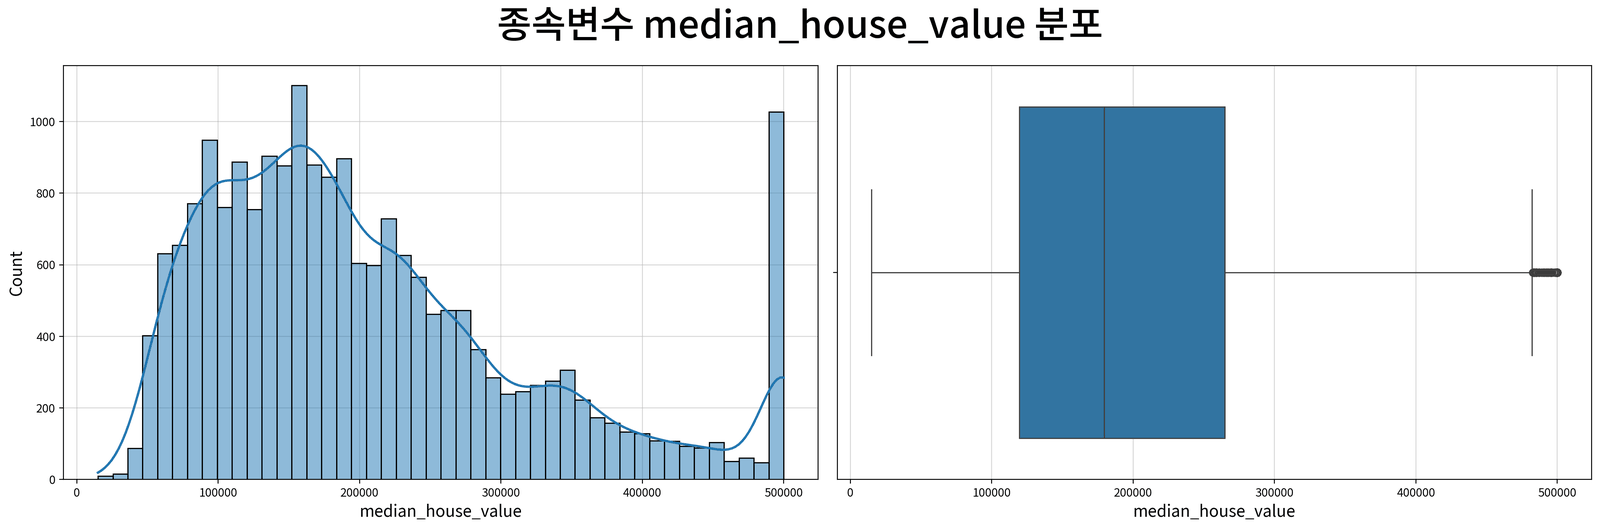

,median_house_value
count,20433.000
mean,206864.413
std,115435.667
min,14999.000
25%,119500.000
50%,179700.000
75%,264700.000
max,500001.000
rel_diff,0.151
rdiff_flag,diff


In [8]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
            title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

##### 인사이트

| 점검 항목 | `median_house_value` 관찰값 |
|---|---|
| 분포 모양 | 왜도 +0.978 (우편향), 첨도 0.328 (다소 뾰족함) |
| 봉우리 수 | 단봉 (중앙값 179,700\$ / 평균 206,864\$ 로 평균이 위로 끌림) |
| 이상치 | 상단 1,064건(5.2%) / 하단 0건 |
| 이산점(군집) | 500,001\$에 958건(4.7%) 집중. 최댓값 한 점에 쌓인 인위적 군집 |

- 상한 절단(censoring): 500,001\$는 실제 가격이 아니라 조사 상한에서 잘린 값이다. 우편향(+0.978)의 상당 부분이 이 절단에서 나온다.
  - 상단 이상치 1,064건 중 958건(90%)이 이 한 값이므로, IQR 이상치로 보고 제거하면 고가 구간이 통째로 사라진다.
- 조치: 로그 변환으로 우편향을 완화하고, 500,001 절단 구간은 제거하는 대신 별도 플래그로 관리한다. 모델 평가 시 해당 구간의 과소예측을 감안한다.


#### 2. 연속형 독립변수에 대한 단변량 분석

- 반복문을 통해 모든 연속형 변수에 대해 시각화와 기술 통계량을 일괄 생성한다.

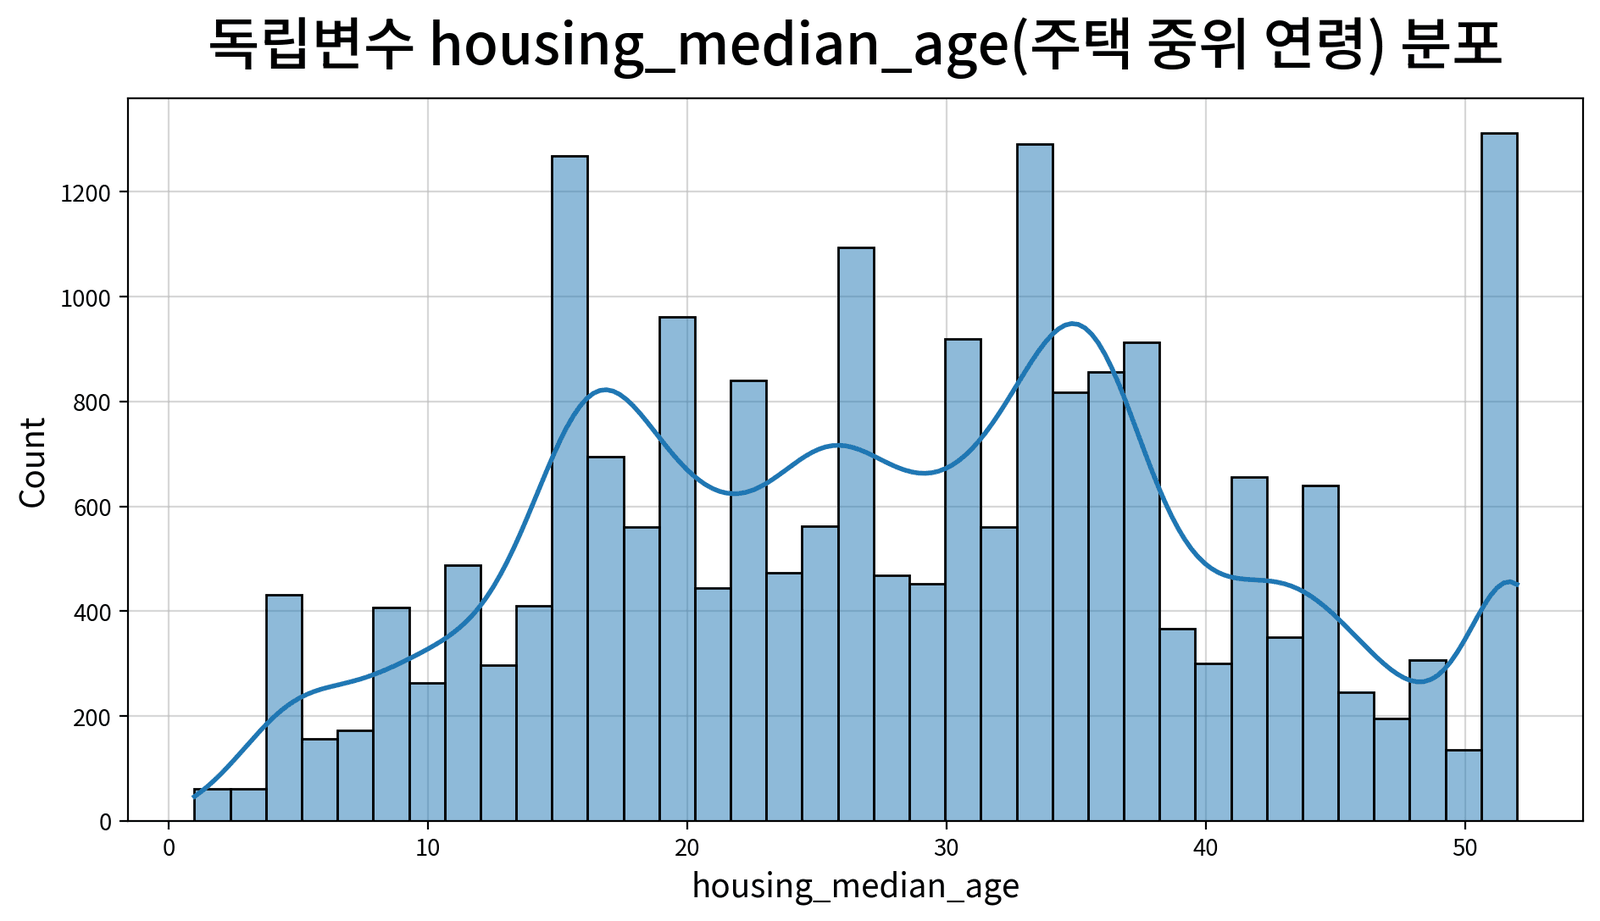

,housing_median_age
count,20433.000
mean,28.633
std,12.592
min,1.000
25%,18.000
50%,29.000
75%,37.000
max,52.000
rel_diff,0.013
rdiff_flag,similar


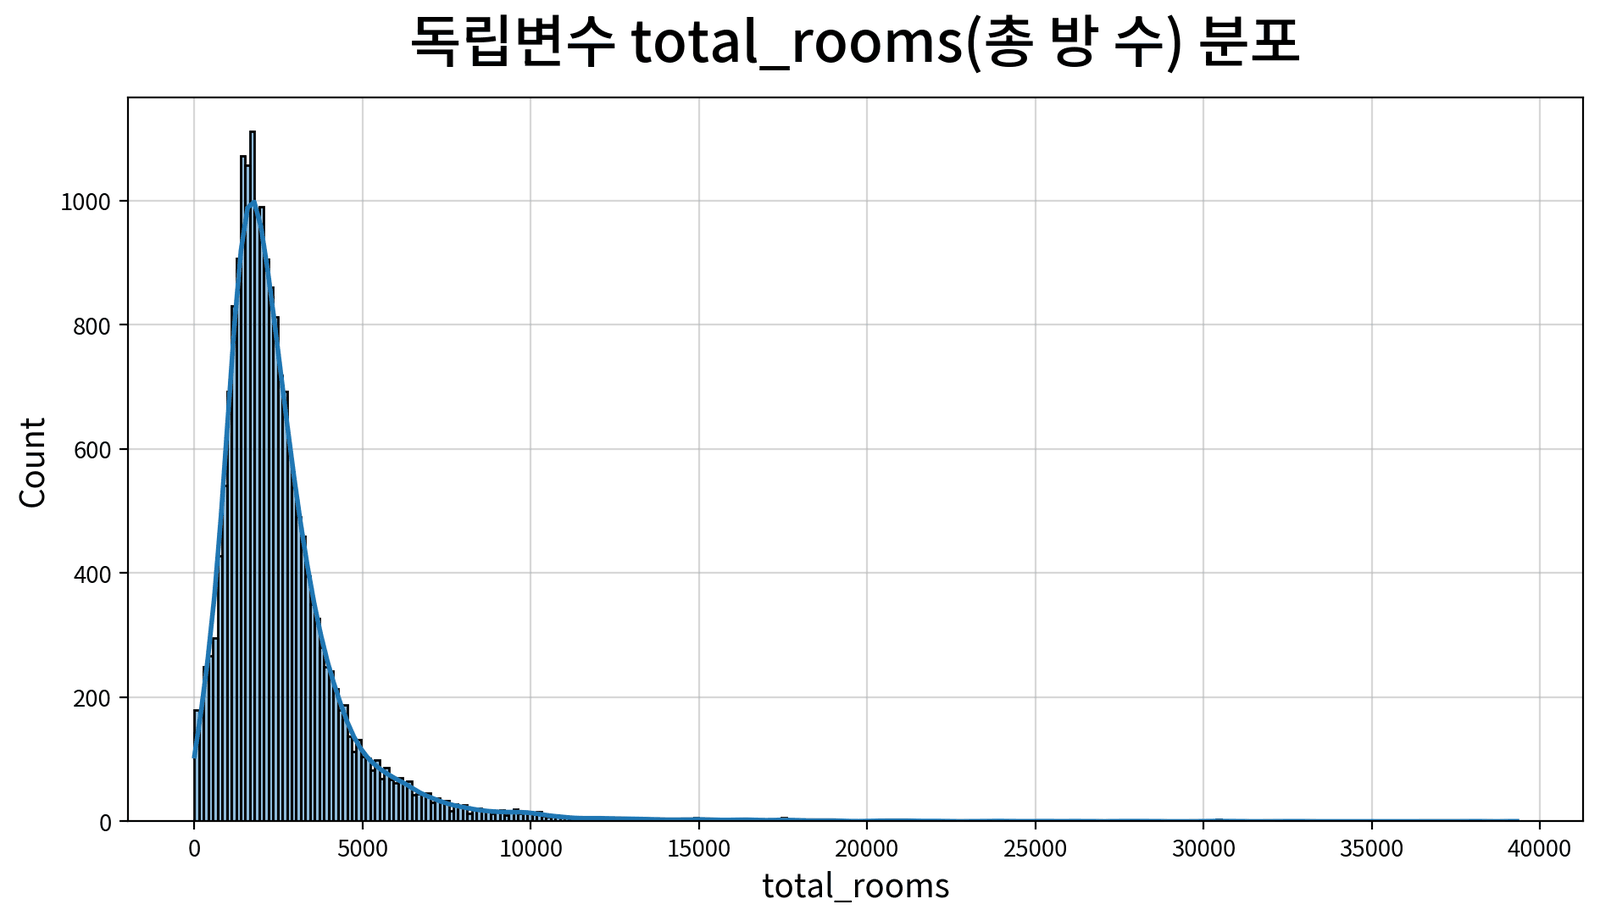

,total_rooms
count,20433.000
mean,2636.504
std,2185.270
min,2.000
25%,1450.000
50%,2127.000
75%,3143.000
max,39320.000
rel_diff,0.240
rdiff_flag,diff


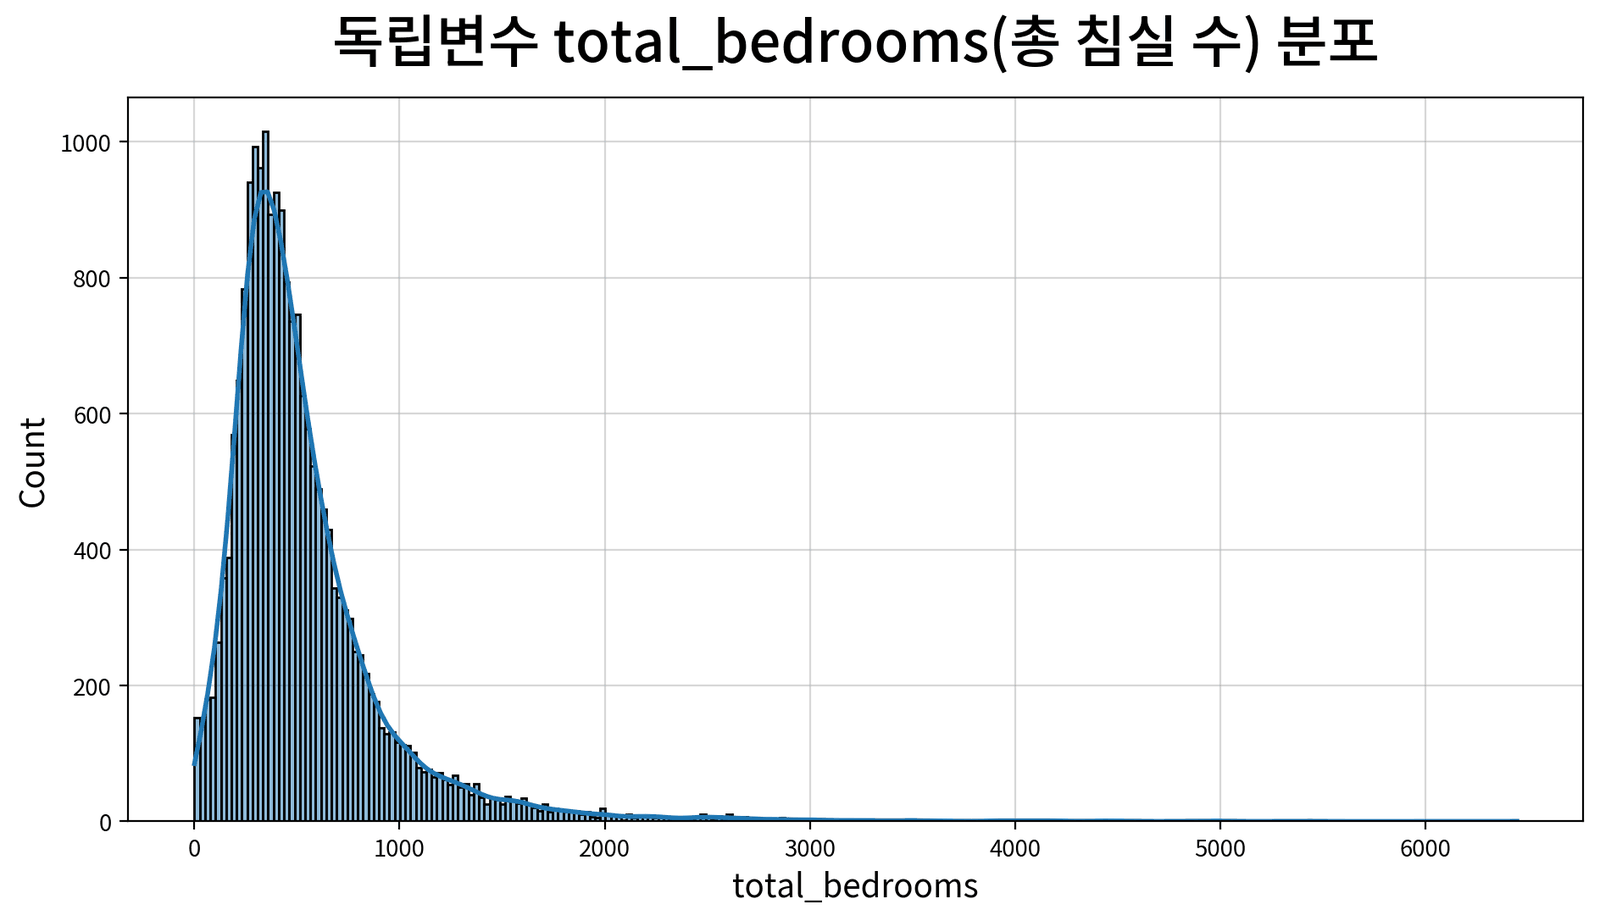

,total_bedrooms
count,20433.000
mean,537.871
std,421.385
min,1.000
25%,296.000
50%,435.000
75%,647.000
max,6445.000
rel_diff,0.236
rdiff_flag,diff


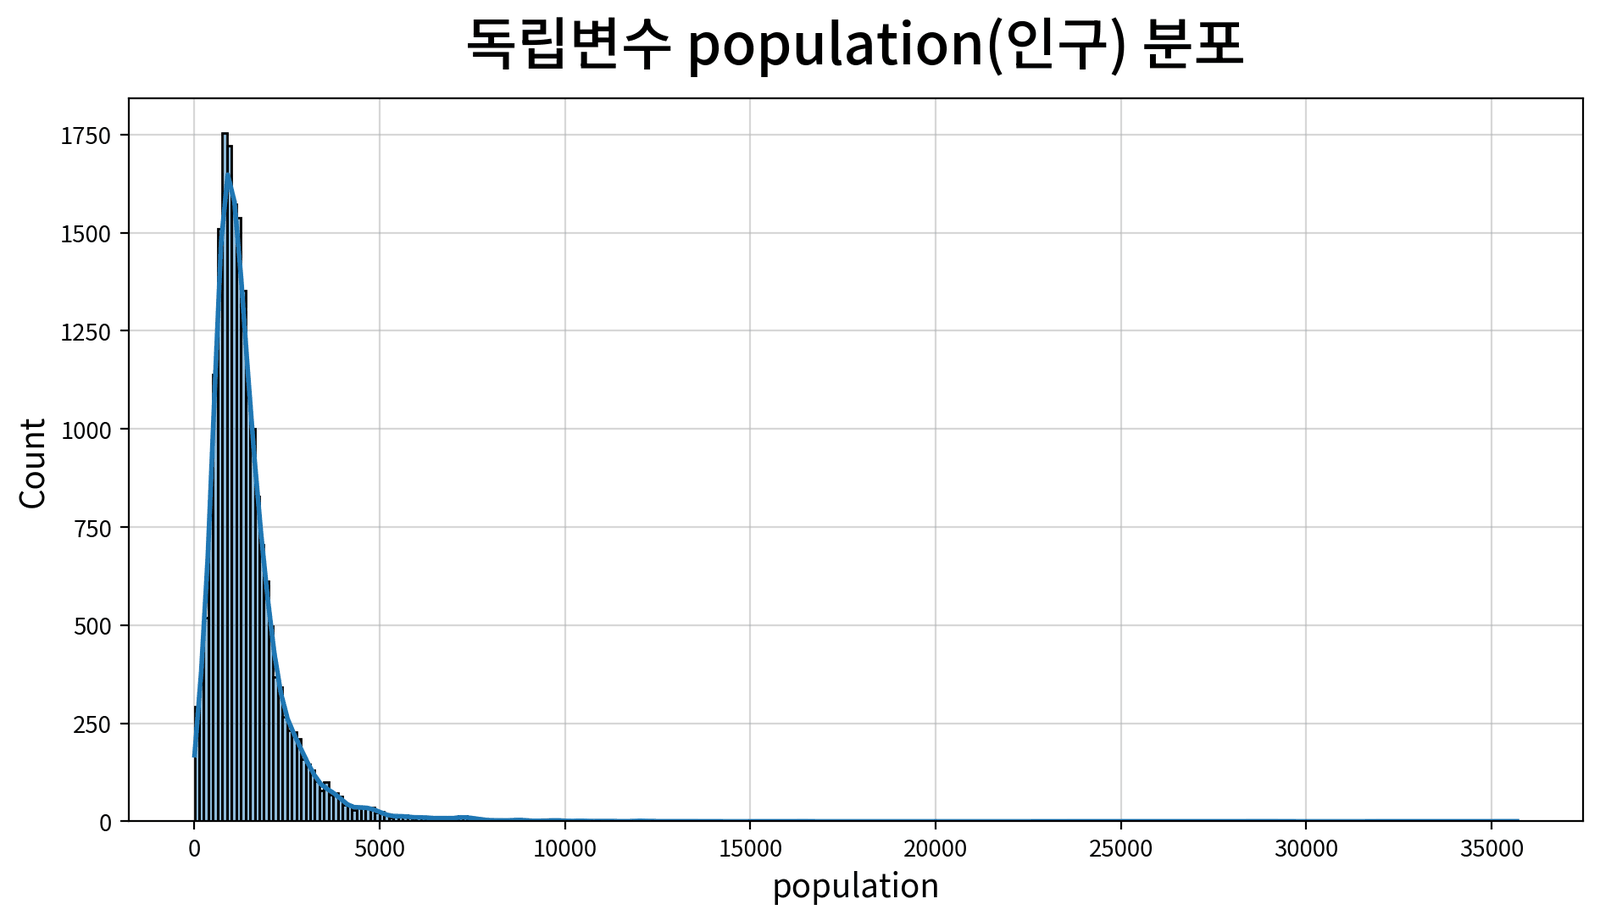

,population
count,20433.000
mean,1424.947
std,1133.208
min,3.000
25%,787.000
50%,1166.000
75%,1722.000
max,35682.000
rel_diff,0.222
rdiff_flag,diff


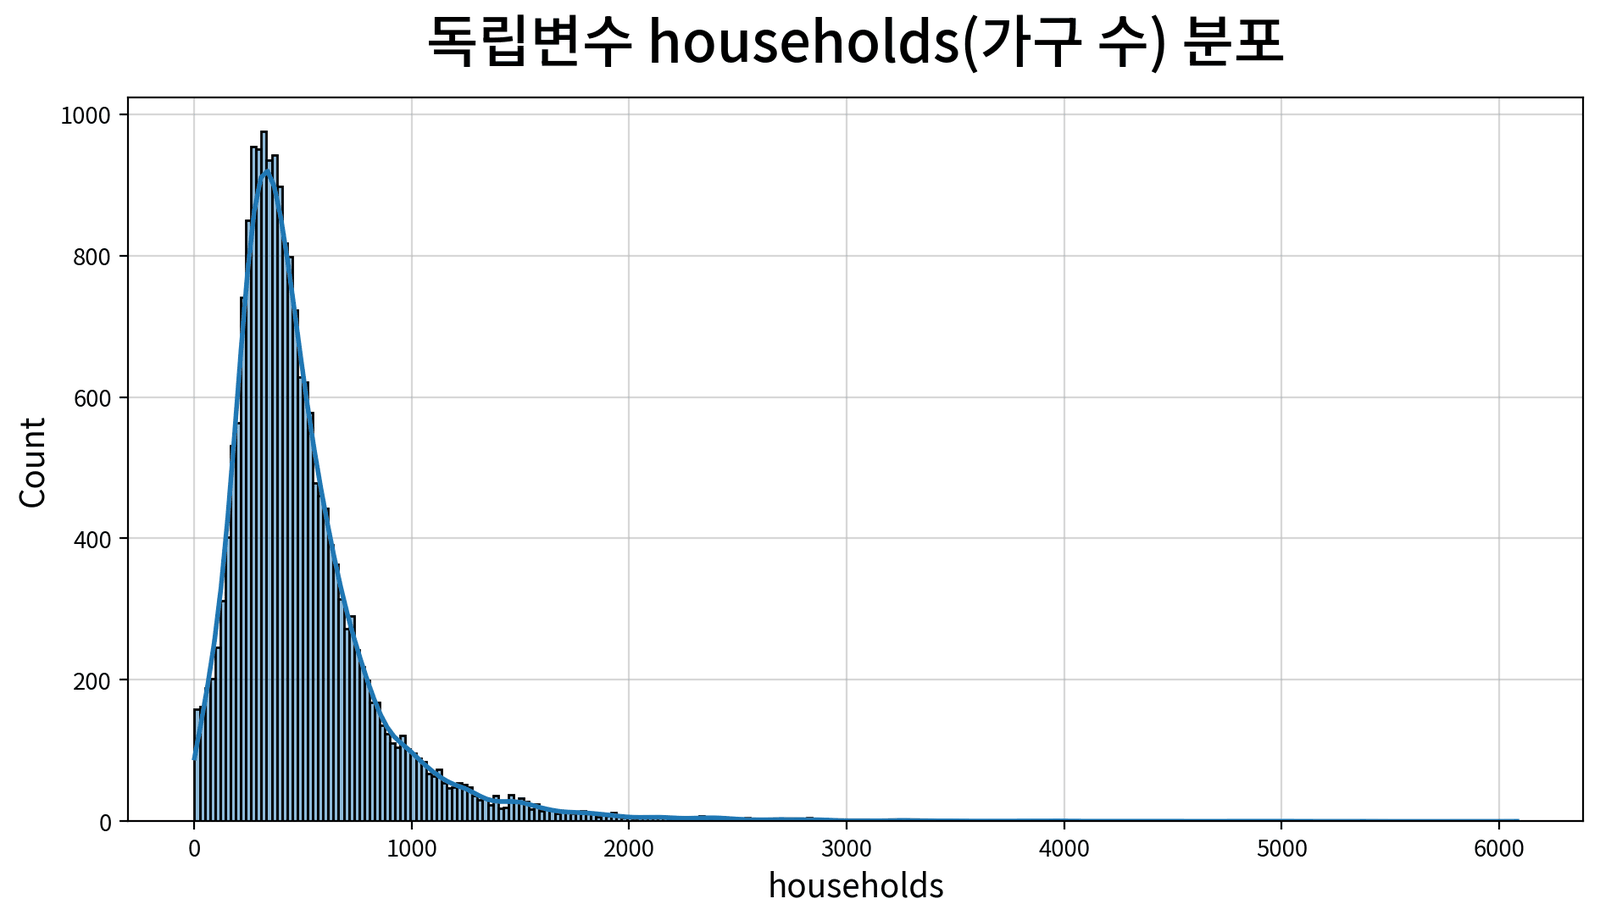

,households
count,20433.000
mean,499.433
std,382.299
min,1.000
25%,280.000
50%,409.000
75%,604.000
max,6082.000
rel_diff,0.221
rdiff_flag,diff


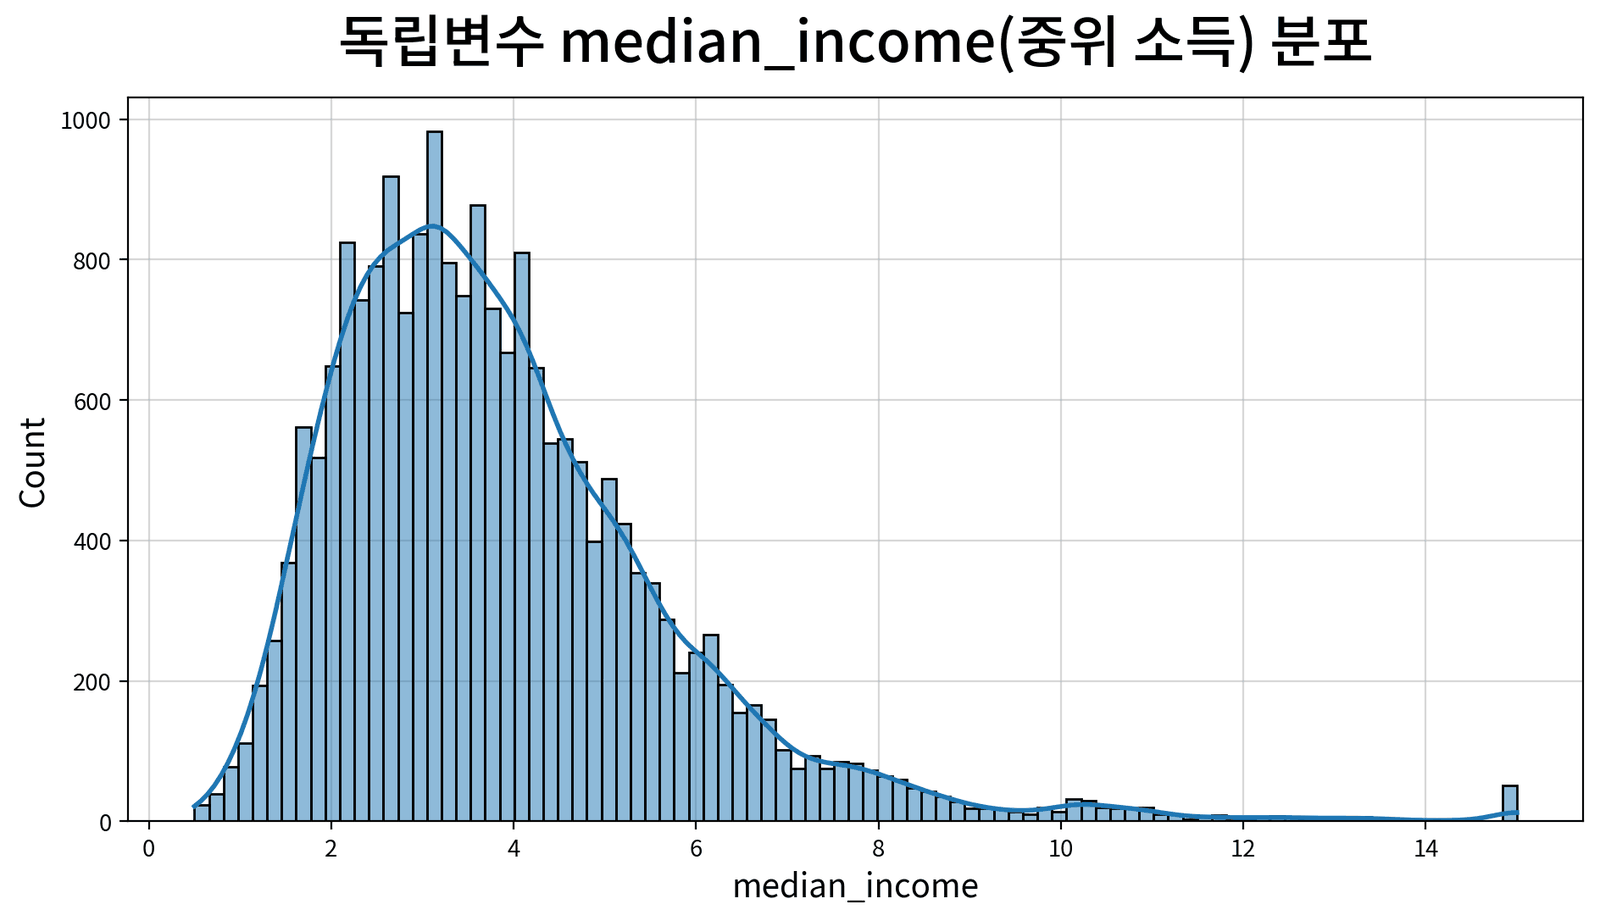

,median_income
count,20433.000
mean,3.871
std,1.899
min,0.500
25%,2.564
50%,3.537
75%,4.744
max,15.000
rel_diff,0.095
rdiff_flag,similar


In [9]:
for f in continuous_cols:
    # 히스토그램 및 박스플롯을 1행 2열 서브플롯으로 구성하는 경우
    #fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
    #            title=f"독립변수 {f}({column_means[f]}) 분포")
    #my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    #my_plot.boxplot(data=df, x=f, ax=ax[1])
    #my_plot.show()

    # 히스토그램만 그리는 경우
    my_plot.histplot(data=df, x=f, kde=True, width=960, height=560,
                    title=f"독립변수 {f}({column_means[f]}) 분포")

    display(num_desc[num_desc.index == f].T)

##### 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 수 | 이상치 | 이산점(군집) | 판단·조치 |
|---|---|---|---|---|---|
| `housing_median_age` | 거의 대칭 (+0.062) | 넓게 퍼진 평탄형 (첨도 -0.801) | 없음 (0건) | 52년에 1,265건(6.2%) 집중 | 변환 불필요. 52 = 상한 절단 주의 |
| `total_rooms` | 강한 우편향 (+4.16) | 단봉 + 긴 우측 꼬리 | 많음 (6.3%) | 없음 (연속) | 로그 변환(log) |
| `total_bedrooms` | 강한 우편향 (+3.46) | 단봉 + 긴 우측 꼬리 | 많음 (6.2%) | 없음 (연속) | 로그 변환(log) |
| `population` | 가장 강한 우편향 (+4.96) | 단봉 + 극단 꼬리 (첨도 74.1) | 많음 (5.8%) | 없음 (연속) | 로그 변환(log) |
| `households` | 강한 우편향 (+3.41) | 단봉 + 긴 우측 꼬리 | 많음 (5.9%) | 없음 (연속) | 로그 변환(log) |
| `median_income` | 중간 우편향 (+1.65) | 단봉 (중앙값 3.54) | 다소 있음 (3.3%) | 15.0에 50건 집중 | 로그 변환 + 15.0 상한 절단 인지 |

- `total_rooms`·`total_bedrooms`·`population`·`households` 4종이 모두 같은 모양(강한 우편향에 6% 내외의 상단 이상치)이다. 넷 다 구역(block)에 몇 개가 있는지를 세는 총량 변수라서, 인구가 많은 구역 하나가 4개 변수를 동시에 키운다. 다변량 단계에서 공선성을 확인해야 한다.
- 총량 변수의 이상치는 오류값이 아니다. `population` 최댓값 35,682명은 실제로 인구가 많은 구역일 뿐 물리적으로 불가능한 값이 아니다. 제거 대상이 아니라 로그 변환 대상이다.
- `housing_median_age`의 52년 집중(6.2%)은 종속변수의 500,001\$와 같은 상한 절단이다. 53년 이상은 모두 52로 기록되었다.
- `median_income`의 15.0 집중(50건)도 상한 절단(단위 = 만 달러)이다. 건수가 적어 영향은 제한적이다.


#### 3. 범주형 독립변수에 대한 단변량 분석

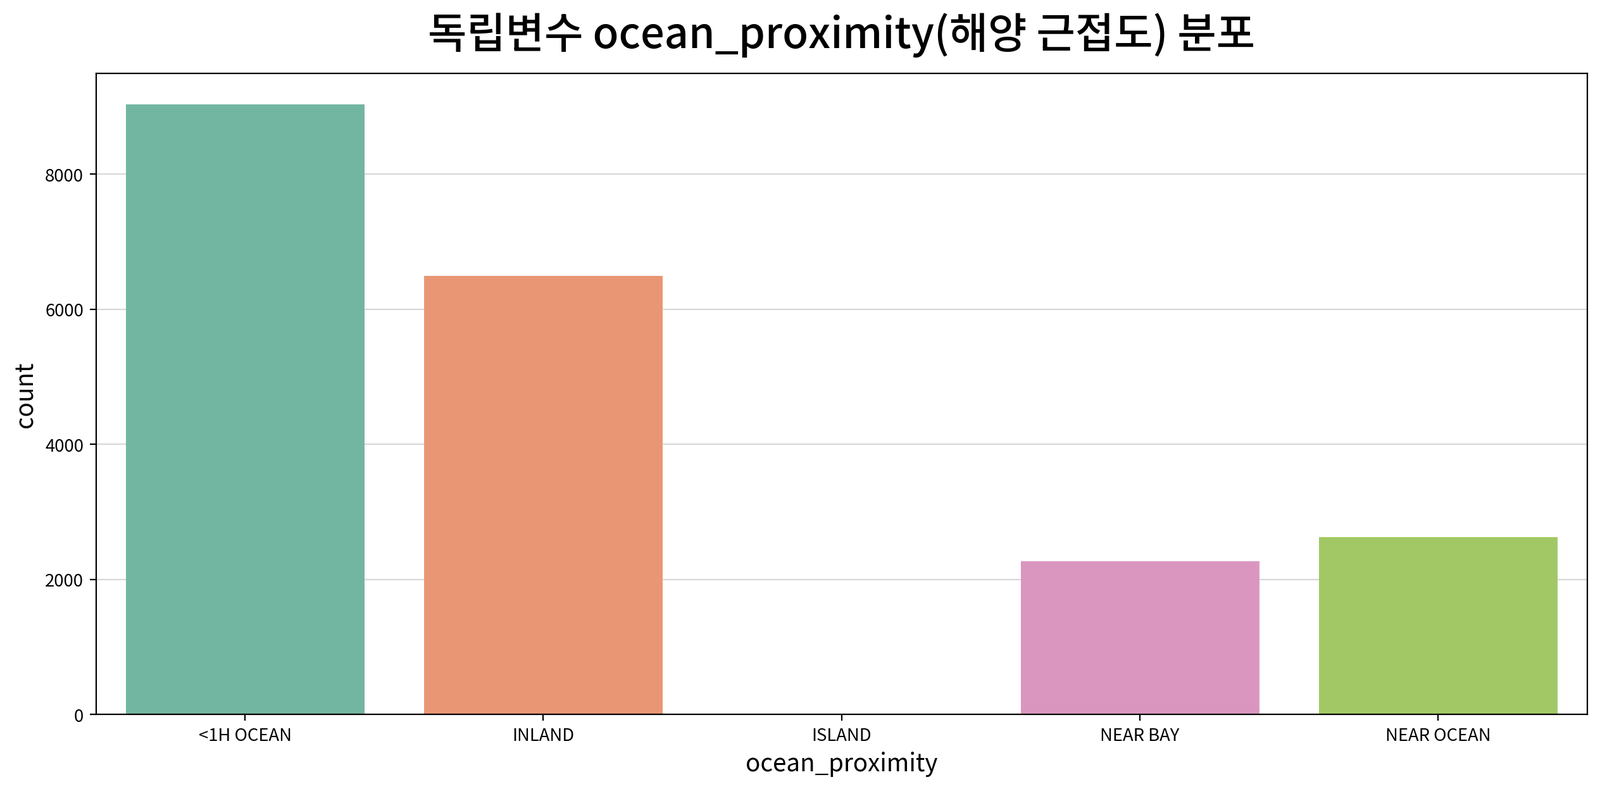

,count,unique,top,freq
ocean_proximity,20433,5,<1H OCEAN,9034


,빈도,비율
ocean_proximity,,
<1H OCEAN,9034,0.442
INLAND,6496,0.318
NEAR OCEAN,2628,0.129
NEAR BAY,2270,0.111
ISLAND,5,0.000


In [10]:
for n in nominal_cols:
    # 범주형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", 
                      title=f"독립변수 {n}({column_means[n]}) 분포")

    # 범주형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

##### 인사이트

| 변수 | 범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|---|
| `ocean_proximity` | 5 | \<1H OCEAN 9,034 (44.2%) | ISLAND 5 (0.02%) | 극심한 불균형 | 3집단 이상이므로 ANOVA 대상 |

- 범주 구성: `<1H OCEAN` 9,034(44.2%) / `INLAND` 6,496(31.8%) / `NEAR OCEAN` 2,628(12.9%) / `NEAR BAY` 2,270(11.1%) / `ISLAND` 5(0.02%)
- `ISLAND` 5건이 문제다. 표본이 5개뿐이라 집단 평균의 신뢰구간이 지나치게 넓고, 사후검정에서 이 범주가 낀 쌍은 평균 차이가 크게 나와도 유의하지 않게 나올 수 있다(검정력 부족).
  - 조치: 해석에서 제외하거나 `NEAR OCEAN` 등 인접 범주와 병합한 뒤 재검정한다. 더미 인코딩을 하면 5건짜리 열이 하나 생기므로 병합하는 편이 안전하다.
- 나머지 4개 범주는 상위 2개가 76%를 차지하지만 각 범주가 2,000건 이상이라 검정에는 충분하다.


### #03. 이변량 분석

#### 1. 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

#### ▶︎ housing_median_age(주택 중위 연령) → median_house_value

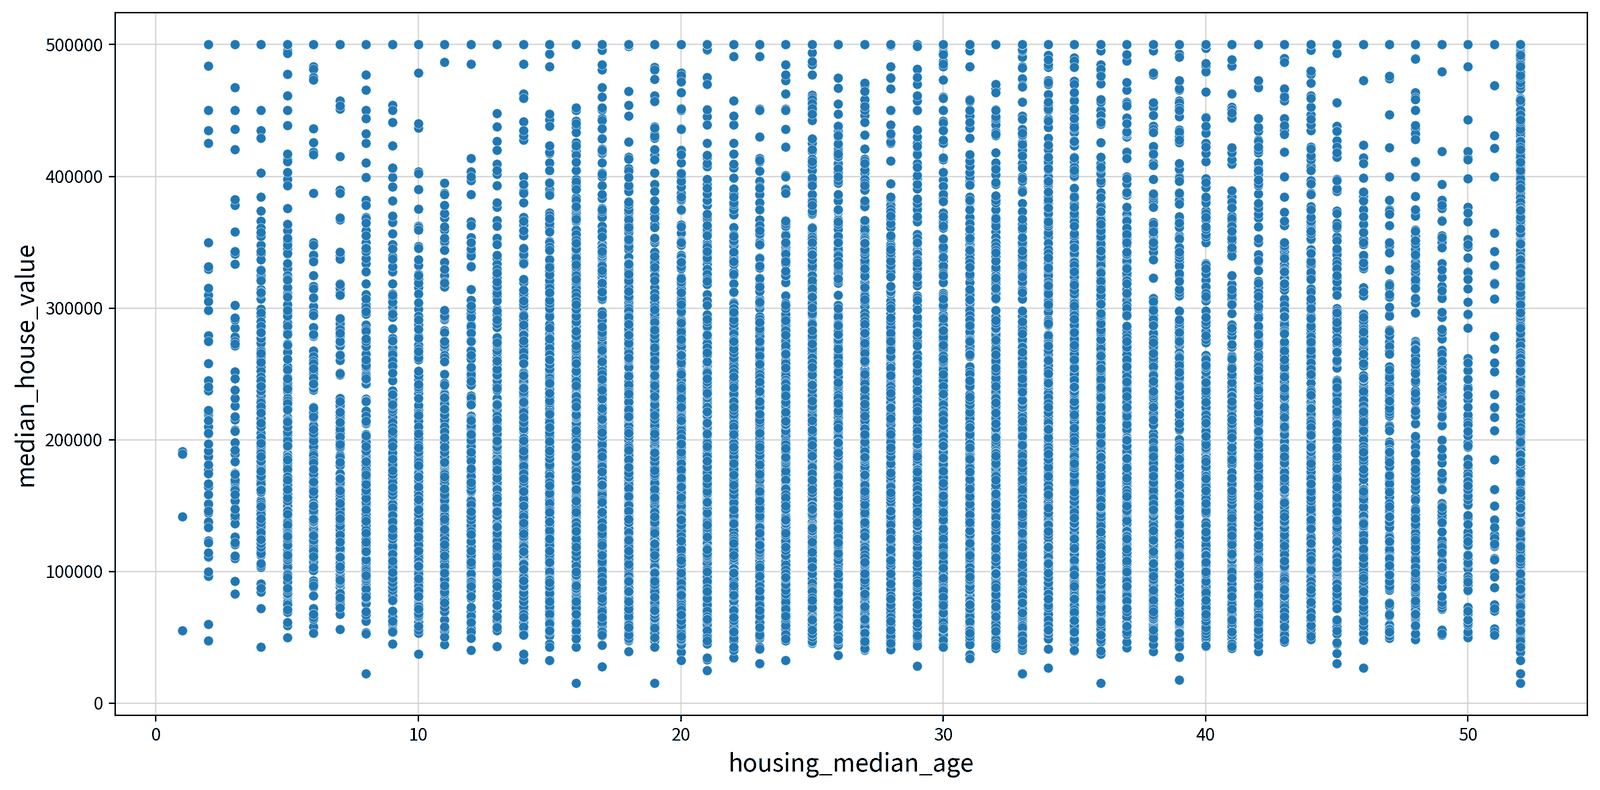

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
housing_median_age,median_house_value,Spearman,0.075,0.000,Weak,True,False,False,False,False,False


#### ▶︎ total_rooms(총 방 수) → median_house_value

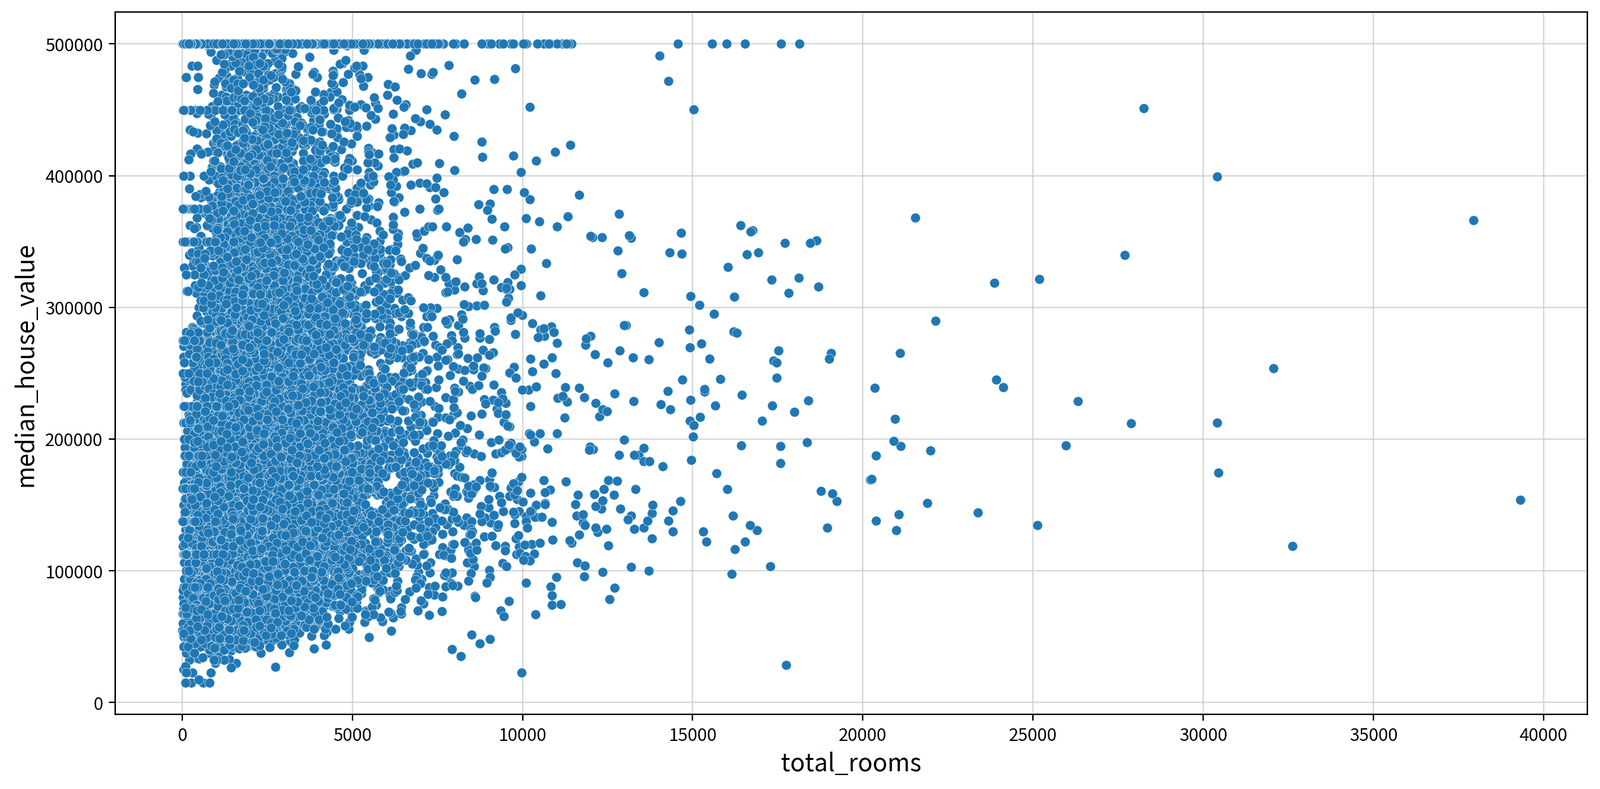

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
total_rooms,median_house_value,Spearman,0.205,0.000,Weak,True,False,False,False,False,True


#### ▶︎ total_bedrooms(총 침실 수) → median_house_value

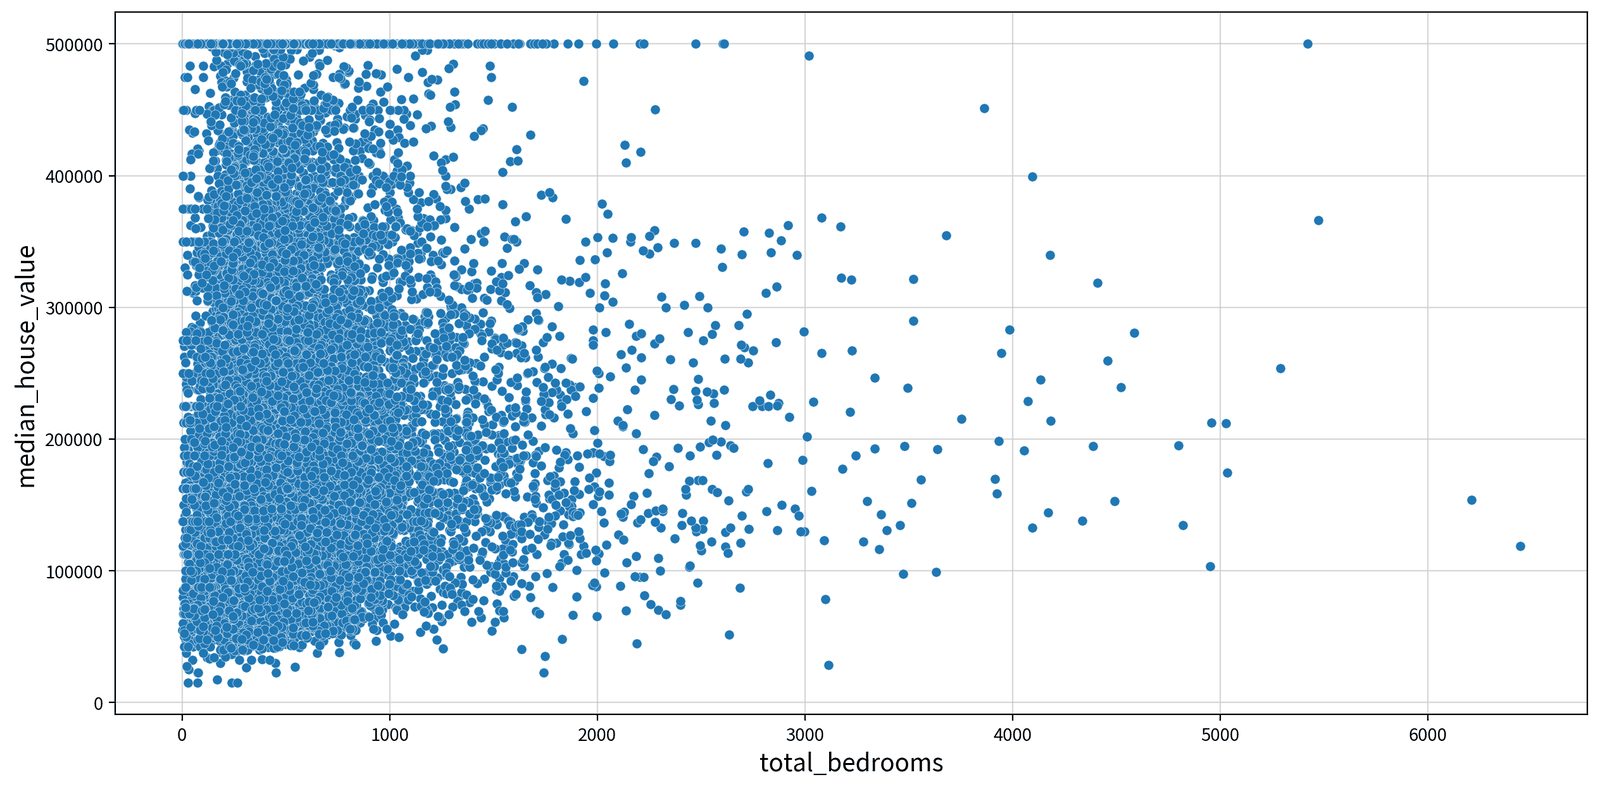

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
total_bedrooms,median_house_value,Spearman,0.086,0.000,Weak,True,False,False,False,False,True


#### ▶︎ population(인구) → median_house_value

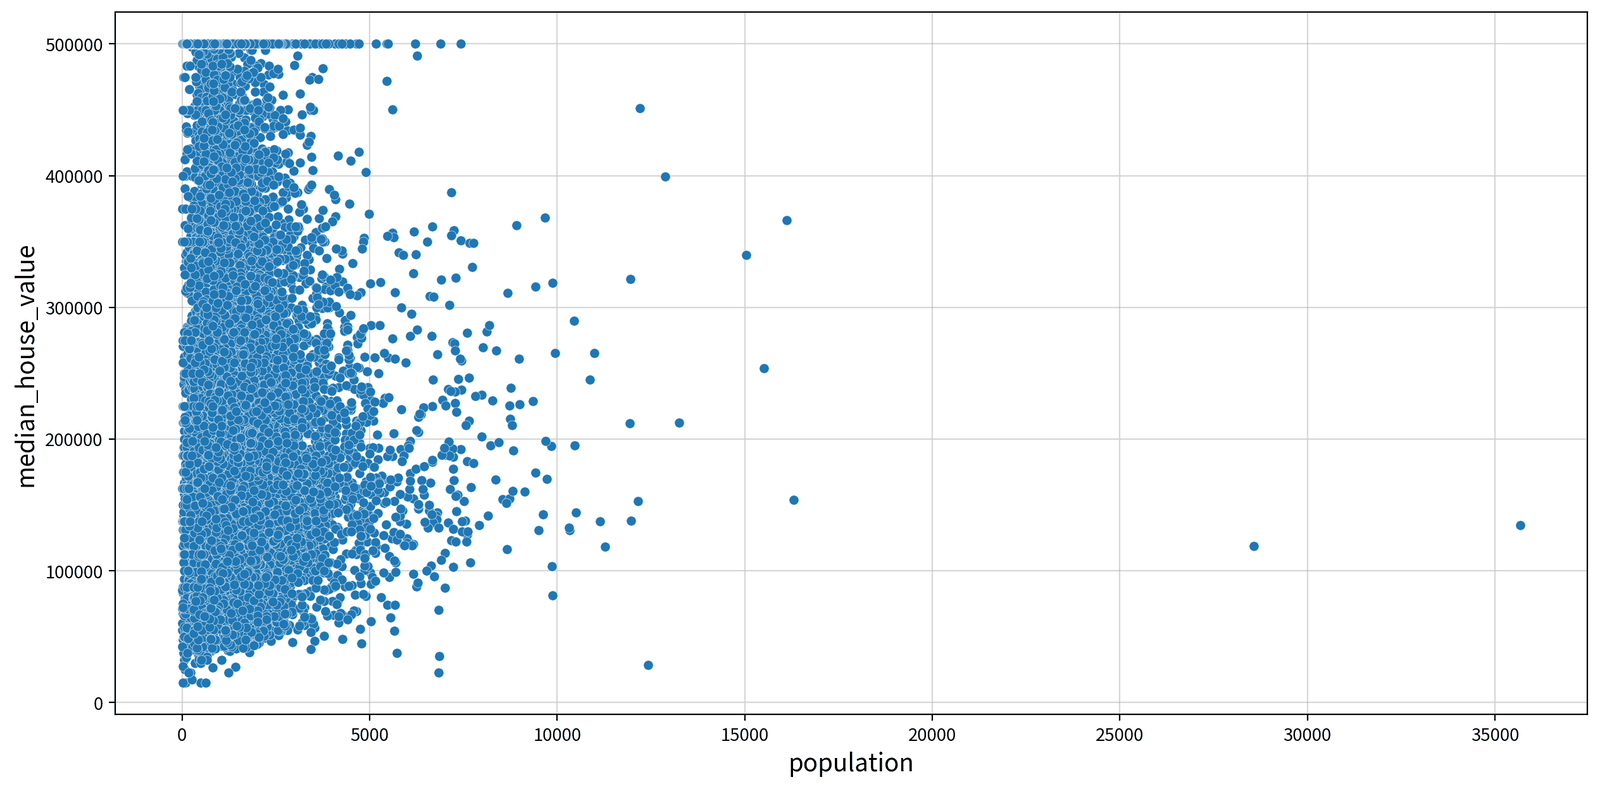

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
population,median_house_value,Spearman,0.003,0.681,Weak,False,False,False,True,False,True


#### ▶︎ households(가구 수) → median_house_value

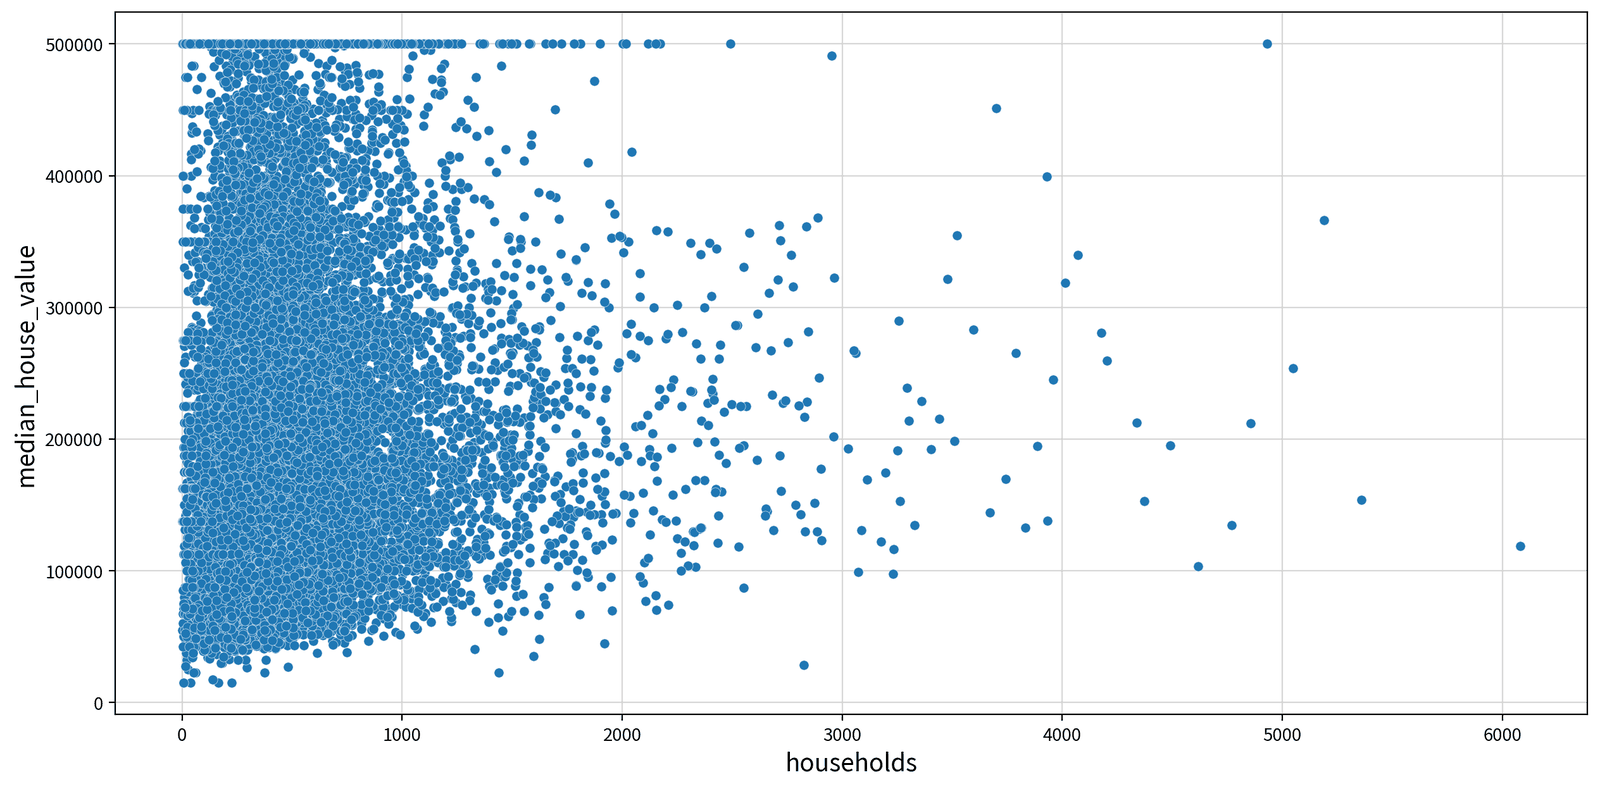

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
households,median_house_value,Spearman,0.112,0.000,Weak,True,False,False,False,False,True


#### ▶︎ median_income(중위 소득) → median_house_value

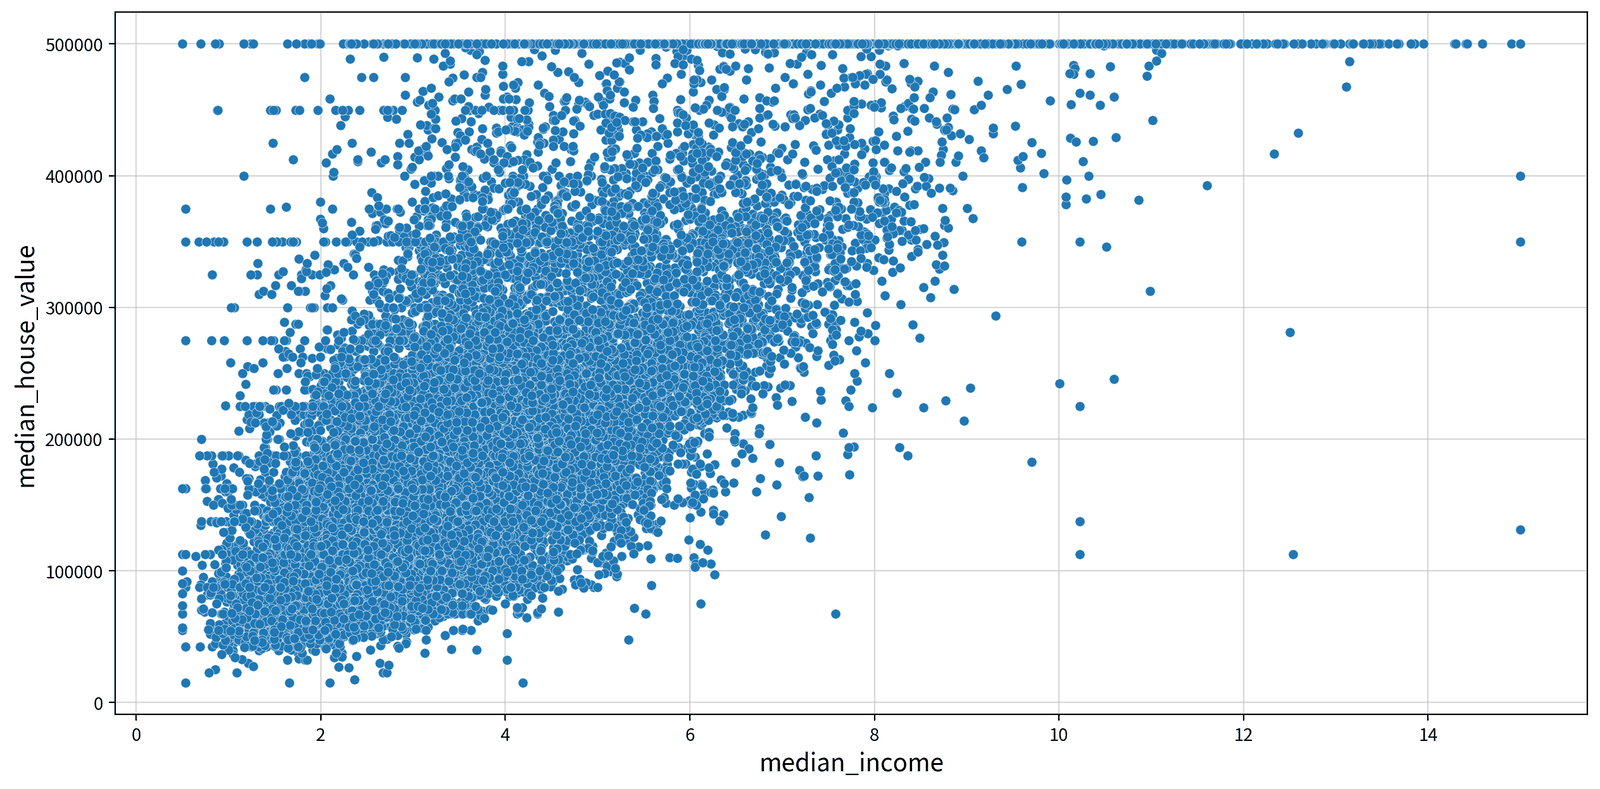

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
median_income,median_house_value,Spearman,0.677,0.000,Moderate,True,False,False,False,False,True


In [11]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
                        linewidth=0.2, size=30)
    
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

##### 인사이트

| 변수 | method | coef | strength | p-value | significant | normality | linearity | influential_outlier | high_skew |
|---|---|---|---|---|---|---|---|---|---|
| `median_income` | Spearman | **0.677** | **Moderate** | 0.000 | True | False | False | False | True |
| `total_rooms` | Spearman | 0.205 | Weak | 0.000 | True | False | False | False | True |
| `households` | Spearman | 0.112 | Weak | 0.000 | True | False | False | False | True |
| `total_bedrooms` | Spearman | 0.086 | Weak | 0.000 | True | False | False | False | True |
| `housing_median_age` | Spearman | 0.075 | Weak | 0.000 | True | False | False | False | **False** |
| `population` | Spearman | 0.003 | Weak | **0.681** | **False** | False | **True** | False | True |

###### 결과표에서 읽은 것

- **`strength`가 Weak이 아닌 변수는 `median_income` 하나뿐이다.** 유일한 Moderate이며, `coef`=0.677은 2위 `total_rooms`(0.205)의 3배가 넘는다. 나머지 5종은 0.003~0.205 구간에 모여 전부 Weak으로 라벨된다.
  → 근거: `strength`·`coef` 열
- **`significant`=False인 변수는 `population` 하나뿐이다.** `p-value`=0.681로, 나머지 5종이 모두 0.000인 것과 대비된다. `coef`도 0.003으로 6종 중 최저다.
  → 근거: `significant`·`p-value`·`coef` 열
- **`linearity`=True인 변수도 `population` 하나뿐이다.** 나머지 5종은 모두 False다. 유의하지 않은 변수에서만 선형성이 충족으로 나온 조합이므로, 이 True를 관계의 근거로 쓰지 않는다.
  → 근거: `linearity` 열
- **`influential_outlier`는 6종 모두 False다.** 단변량 분석의 `num_desc`에서 총량 변수마다 IQR 이상치가 5.8~6.3% 존재했으나, 그 행들을 제외해도 Pearson r 변화량이 0.1 미만이라는 뜻이다(판정 기준은 `helpers/my_stats.py`).
  → 근거: `influential_outlier` 열 + `num_desc`의 `outliers_ratio`
- **`high_skew`=False인 변수는 `housing_median_age` 하나뿐이다.** `num_desc`의 왜도(`housing_median_age` +0.062 / `total_rooms` +4.159 / `total_bedrooms` +3.460 / `population` +4.960 / `households` +3.414 / `median_income` +1.645)와 |왜도|>1 기준이 일치한다. 이 변수에서 Spearman이 채택된 사유는 왜도가 아니라 정규성 미충족이다.
  → 근거: `high_skew` 열 + `num_desc`의 `skew` 열

###### 산점도에서 읽은 것

- **상단 500,001$ 선의 수평 점열이 모든 산점도에서 공통 관찰됨**
  - 절단된 데이터임을 확인
- **`median_income` : 좌하→우상 방향의 추세** 
  - 점 구름의 하단 경계가 x가 커질수록 함께 올라가고, 세로 폭도 함께 넓어진다. 나머지 5종에는 이런 방향성이 없다.
- **총량 변수 3종(`total_rooms`·`total_bedrooms`·`households`)과 `population`은 좌측에 밀집하고 우측 긴 꼬리**
- **`housing_median_age`는 세로 줄무늬로 나타난다.**
  - x가 정수 눈금에만 값을 갖기 때문이며, 각 줄의 y 분포 범위가 x 전 구간에서 비슷

#### 2. T-Test (x: 2집단 범주형 독립변수 → y: 종속변수)

In [12]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                    group1=wide_df.columns[0], group2=wide_df.columns[1]))

##### 인사이트

> 이 데이터셋에는 해당 없음


#### 3. ANOVA (x: 3집단 범주형 독립변수 → y: 종속변수)

In [13]:
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df, y=target, between=n))
        
        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶︎ ocean_proximity(해양 근접도) → median_house_value

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_stats.py:91: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,ocean_proximity,4,31.918,2055.803,0.000,0.238,Large


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_stats.py:91: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


비교한 조합 쌍: 10개
유의한 쌍: 7개
평균 차이가 가장 큰 쌍: (INLAND) vs (ISLAND) -> 차이 255543.137, 효과크기 Large, p-value 0.010
평균 차이가 가장 작은 쌍: (INLAND) vs (ISLAND)-> 차이 255543.137, 효과크기 Large, p-value 0.010


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,<1H OCEAN,INLAND,240267.991,124896.863,115371.128,1415.614,81.499,15420.197,0.000,1.243,True,Large
1,Games-Howell,<1H OCEAN,ISLAND,240267.991,380440.000,-140172.009,36044.653,-3.889,4.008,0.076,-1.320,False,Large
2,Games-Howell,<1H OCEAN,NEAR BAY,240267.991,259279.292,-19011.301,2810.217,-6.765,3172.951,0.000,-0.173,True,Negligible
3,Games-Howell,<1H OCEAN,NEAR OCEAN,240267.991,249042.355,-8774.364,2638.754,-3.325,3846.759,0.008,-0.080,True,Negligible
4,Games-Howell,INLAND,ISLAND,124896.863,380440.000,-255543.137,36037.816,-7.091,4.005,0.010,-3.647,True,Large
5,Games-Howell,INLAND,NEAR BAY,124896.863,259279.292,-134382.429,2721.117,-49.385,2801.345,0.000,-1.547,True,Large
6,Games-Howell,INLAND,NEAR OCEAN,124896.863,249042.355,-124145.492,2543.654,-48.806,3343.938,0.000,-1.404,True,Large
7,Games-Howell,ISLAND,NEAR BAY,380440.000,259279.292,121160.708,36119.489,3.354,4.041,0.118,0.986,False,Large
8,Games-Howell,ISLAND,NEAR OCEAN,380440.000,249042.355,131397.645,36106.554,3.639,4.035,0.093,1.072,False,Large
9,Games-Howell,NEAR BAY,NEAR OCEAN,259279.292,249042.355,10236.937,3516.182,2.911,4789.540,0.030,0.083,True,Negligible


##### 인사이트

| 변수 | 집단 차이 | 효과크기 | 사후검정 구분력 | 채택 여부 |
|---|---|---|---|---|
| `ocean_proximity` | 유의 (Welch F=2,055.8, p<0.001) | np2=0.238 (Large) | 10쌍 중 7쌍 유의. `INLAND`를 뚜렷하게 분리 | 채택 (최우선) |

- 이 데이터셋에서 가장 강한 설명변수다. 효과크기 np2=0.238(Large)로, 연속형 최강인 `median_income`(ρ=0.677)에 필적하거나 그 이상이다.
- 집단 평균은 `INLAND` 124,897\$, `<1H OCEAN` 240,268\$, `NEAR OCEAN` 249,042\$, `NEAR BAY` 259,279\$, `ISLAND` 380,440\$ 순이다.
- 실질 구조는 5집단이 아니라 내륙과 해안권의 2집단이다.
  - `INLAND`와 나머지의 차이는 모두 효과크기 Large(hedges 1.24~1.55)다.
  - 반면 해안권 3종(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)끼리는 통계적으로 유의해도 효과크기가 모두 Negligible(hedges 0.08~0.17)이다. n이 커서 유의만 뜬 것이며 실질 차이는 없다.
  - 모델링 시 해안권 3종을 하나로 병합하는 것을 검토할 만하다.
- `ISLAND`(n=5)는 판정할 수 없다. 평균은 380,440\$로 가장 높지만, 관련된 4쌍 중 `INLAND`와의 비교(p=0.010) 하나만 유의하고 나머지 3쌍은 평균 차이가 12만~14만\$나 되는데도 비유의(p=0.076~0.118)다. 차이가 없어서가 아니라 표본 5개로는 검정력이 없기 때문이므로 해석에 사용하지 않는다.


### #04. 다변량 분석

#### 1. 독립변수간 상관 분석

In [14]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
housing_median_age,1.000,-0.356,-0.306,-0.283,-0.281,-0.146
total_rooms,-0.356,1.000,0.915,0.816,0.906,0.271
total_bedrooms,-0.306,0.915,1.000,0.871,0.976,-0.006
population,-0.283,0.816,0.871,1.000,0.904,0.005
households,-0.281,0.906,0.976,0.904,1.000,0.029
median_income,-0.146,0.271,-0.006,0.005,0.029,1.000


,max-y,max-coef,count,columns
x,,,,
households,total_bedrooms,0.976,3,"total_bedrooms, total_rooms, population"
total_bedrooms,households,0.976,3,"households, total_rooms, population"
total_rooms,total_bedrooms,0.915,3,"total_bedrooms, households, population"
population,households,0.904,3,"households, total_bedrooms, total_rooms"
housing_median_age,total_rooms,-0.356,0,-
median_income,total_rooms,0.271,0,-


##### 인사이트

- 서로 상관인 변수: `total_rooms`, `total_bedrooms`, `population`, `households` 4종이 하나의 덩어리를 이룬다.
  - `households` ↔ `total_bedrooms` 0.976 (최대)
  - `total_rooms` ↔ `total_bedrooms` 0.915
  - `population` ↔ `households` 0.904
- 중복이 없는 변수: `median_income`(최대 0.271), `housing_median_age`(최대 -0.356)는 다른 변수와 겹치지 않는 독립적인 정보를 가진다.

### #05. 최종 변수 선택

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| 채택 | `ocean_proximity` | Welch ANOVA | $< 0.05$ | np2=0.238 (Large) | 해당 없음 | X | 단독 설명력 최상위. `INLAND`와 해안권의 격차가 11만\$ 이상(hedges 1.24~1.55)이므로 1순위 |
| 채택 | `median_income` | Spearman | $< 0.05$ | ρ=+0.677 (Moderate) | 우편향(+1.65) / log 변환 고려 | X (최대 0.271) | 연속형 중 유일한 실질 설명변수이고 중복도 없으므로 2순위 |
| 후보 | `total_rooms` | Spearman | $< 0.05$ | ρ=+0.205 (약함) | 강한 우편향(+4.16) / log 변환 고려 | O (total_bedrooms 0.915 / households 0.919) | 규모 축 4종 중 설명력 최상이므로 규모 축 대표로 후보 유지 |
| 후보 | `housing_median_age` | Spearman | $< 0.05$ | ρ=+0.075 (약함) | 대칭 / 변환 불필요 | X (최대 -0.356) | 설명력은 미미하나 중복이 없어 정보 가치가 있다. 계수 유의성으로 최종 판정 |
| 후보 | `households` | Spearman | $< 0.05$ | ρ=+0.112 (약함) | 강한 우편향(+3.41) / log 변환 고려 | O (total_bedrooms 0.976) | 설명력·중복 모두 열위라 규모 축 대표를 `total_rooms`에 양보. VIF 결과에 따라 대체 투입 |
| 후보 | `total_bedrooms` | Spearman | $< 0.05$ | ρ=+0.086 (약함) | 강한 우편향(+3.46) / log 변환 고려 | O (households 0.976) | 설명력·중복 모두 열위. 대표 양보 |
| 제외 | `population` | Spearman | 0.681 | ρ=+0.003 | 강한 우편향(+4.96) | O (households 0.904) | 유일한 비유의 변수. n=20,433 대표본에서도 p>0.05, ρ≈0으로 관계 자체가 없고 공선성까지 겹쳐 후보에서도 제외 |
| 별도 | `longitude`·`latitude` | - | - | - | 해당 없음 | - | 좌표 변수이므로 표준 연속형 트랙에서 제외. 공간 효과는 `ocean_proximity`가 대리하며, 파생변수화 후 재검토 (`#01-8` 참조) |

#### 종합 판단

- 1순위 2종(`ocean_proximity`·`median_income`)이 설명력의 대부분을 차지한다. 위치와 소득이 집값을 결정한다는 도메인 상식과 일치한다.
- 나머지 총량 변수 4종은 개별 설명력이 약하고(ρ<0.21) 서로 심하게 중복(ρ≥0.90)된다. 그대로 넣기보다 비율형 파생변수(가구당 방 수, 방당 침실 비율, 가구당 인구)로 재구성한 뒤 재평가하는 것이 낫다.
- **전처리 선행 과제**
  1. 종속변수의 500,001\$ 절단 구간(958건) 플래그 관리
  2. `ocean_proximity`은 해안권(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)과 비해안권(`INLAND`)으로 다시 분류하고 `ISLAND`는 해안권에 흡수시킴
  3. `housing_median_age` 52년 절단(1,265건) 인지
  4. 종속변수 및 우편향 연속형 (`median_income`·`total_rooms`·`total_bedrooms`·`population`·`households`) log 변환
  5. 위·경도에 의한 공간 특성 반영

<a id="stage-03"></a>

## #3. 분석용 데이터 전처리

> EDA 결과를 바탕으로 비율형·범주형·공간 파생변수를 만들고 모델 입력 데이터를 준비합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | 품질 점검 완료 California Housing 데이터 |
| 핵심 작업 | 파생변수 생성·검증, 공간특성 반영, 로그 변환, 범주형 라벨링 |
| 산출물 | `california_housing_features.xlsx` |

**분석 목차:** [01. 분석 개요와 데이터 품질 점검](#stage-01) · [02. 탐색적 데이터 분석 (EDA)](#stage-02) · [03. 분석용 데이터 전처리](#stage-03) · [04. 회귀모델링과 하이퍼파라미터 튜닝](#stage-04) · [05. 최종모델 진단과 결과 해석](#stage-05)

---

### EDA 단계에서의 결론

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| 채택 | `ocean_proximity` | Welch ANOVA | $< 0.05$ | np2=0.238 (Large) | 해당 없음 | X | 단독 설명력 최상위. `INLAND`와 해안권의 격차가 11만\$ 이상(hedges 1.24~1.55)이므로 1순위 |
| 채택 | `median_income` | Spearman | $< 0.05$ | ρ=+0.677 (Moderate) | 우편향(+1.65) / log 변환 고려 | X (최대 0.271) | 연속형 중 유일한 실질 설명변수이고 중복도 없으므로 2순위 |
| 후보 | `total_rooms` | Spearman | $< 0.05$ | ρ=+0.205 (약함) | 강한 우편향(+4.16) / log 변환 고려 | O (total_bedrooms 0.915 / households 0.919) | 규모 축 4종 중 설명력 최상이므로 규모 축 대표로 후보 유지 |
| 후보 | `housing_median_age` | Spearman | $< 0.05$ | ρ=+0.075 (약함) | 대칭 / 변환 불필요 | X (최대 -0.356) | 설명력은 미미하나 중복이 없어 정보 가치가 있다. 계수 유의성으로 최종 판정 |
| 후보 | `households` | Spearman | $< 0.05$ | ρ=+0.112 (약함) | 강한 우편향(+3.41) / log 변환 고려 | O (total_bedrooms 0.976) | 설명력·중복 모두 열위라 규모 축 대표를 `total_rooms`에 양보. VIF 결과에 따라 대체 투입 |
| 후보 | `total_bedrooms` | Spearman | $< 0.05$ | ρ=+0.086 (약함) | 강한 우편향(+3.46) / log 변환 고려 | O (households 0.976) | 설명력·중복 모두 열위. 대표 양보 |
| 제외 | `population` | Spearman | 0.681 | ρ=+0.003 | 강한 우편향(+4.96) | O (households 0.904) | 유일한 비유의 변수. n=20,433 대표본에서도 p>0.05, ρ≈0으로 관계 자체가 없고 공선성까지 겹쳐 후보에서도 제외 |
| 별도 | `longitude`·`latitude` | - | - | - | 해당 없음 | - | 좌표 변수이므로 표준 연속형 트랙에서 제외. 공간 효과는 `ocean_proximity`가 대리하며, 파생변수화 후 재검토 (`#01-8` 참조) |

#### 종합 판단

- 1순위 2종(`ocean_proximity`·`median_income`)이 설명력의 대부분을 차지한다. 위치와 소득이 집값을 결정한다는 도메인 상식과 일치한다.
- 나머지 총량 변수 4종은 개별 설명력이 약하고(ρ<0.21) 서로 심하게 중복(ρ≥0.90)된다. 그대로 넣기보다 비율형 파생변수(가구당 방 수, 방당 침실 비율, 가구당 인구)로 재구성한 뒤 재평가하는 것이 낫다.
- **전처리 선행 과제**
  1. 종속변수의 500,001\$ 절단 구간(958건) 플래그 관리
  2. `ocean_proximity`은 해안권(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)과 비해안권(`INLAND`)으로 다시 분류하고 `ISLAND`는 해안권에 흡수시킴
  3. `housing_median_age` 52년 절단(1,265건) 인지
  4. 종속변수 및 우편향 연속형 (`median_income`·`total_rooms`·`total_bedrooms`·`population`·`households`) log 변환
  5. 위·경도에 의한 공간 특성 반영


### #01. 준비작업

#### 1. 공간분석을 위한 패키지 설치

- geopandas: pandas처럼 표 형식 데이터를 다루되, 좌표·폴리곤·선 같은 공간 geometry 데이터를 함께 처리하는 패키지
- libpysal: 공간분석을 위한 공간가중치 행렬, 이웃 관계, 거리 기반 구조 생성
- pyproj: 위도·경도 좌표계를 다른 좌표계로 변환하거나, 좌표계 정보를 관리
- esda: Moran’s I, Geary’s C, LISA 같은 탐색적 공간데이터 분석 및 공간자기상관 분석 수행

In [1]:
!pip install -q --upgrade geopandas libpysal pyproj esda


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 2. 라이브러리 참조

In [2]:
from jussam import load_data
from helpers import *
from pandas import concat, DataFrame
from IPython.display import display, Markdown

# 공간특성의 존재 확인을 위한 라이브러리 참조
from geopandas import GeoDataFrame, read_file, points_from_xy
from libpysal.weights import Queen, Rook, KNN
from esda.moran import Moran
from pyproj import CRS

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 3. 품질 점검 완료 데이터 셋 가져오기

In [3]:
origin = load_data("california_housing_qtcheck")
num_desc = load_data("california_housing_numerical_summary")
cat_desc = load_data("california_housing_categorical_summary")

📚 캘리포니아 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field               description
--  ------------------  --------------
 0  longitude           경도
 1  latitude            위도
 2  housing_median_age  주택 중위 연령
 3  total_rooms         총 방 수
 4  total_bedrooms      총 침실 수
 5  population          인구
 6  households          가구 수
 7  median_income       중위 소득
 8  median_house_value  주택 중위 가격
 9  ocean_proximity     해양 근처 위치

📚 캘리포니아 주택 가격 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 캘리포니아 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


#### 4. 범주형 타입 변환 및 서열 척도 지정

In [4]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20433 non-null  float64 
 1   latitude            20433 non-null  float64 
 2   housing_median_age  20433 non-null  int64   
 3   total_rooms         20433 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20433 non-null  int64   
 6   households          20433 non-null  int64   
 7   median_income       20433 non-null  float64 
 8   median_house_value  20433 non-null  int64   
 9   ocean_proximity     20433 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


#### 5. 변수 유형 분류

In [5]:
target = "median_house_value"   # 종속변수 이름
target_is_continuous = True     # 종속변수 연속형 여부

# 분석 대상에서 제외할 변수
# -> 식별자(ID), 다른 변수와 중복되는 항목, 일반 변수로 다룰 수 없는 값 등을 나열한다.
exclude_cols = ["longitude", "latitude"]

nominal_cols = my_qtcheck.get_categorical_column_names(df)  # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)    # 연속형 변수

if target_is_continuous:               # 종속변수가 연속형 변수라면?
    continuous_cols.remove(target)     # 연속형 변수 이름에서 종속변수 항목 제거 
else:                                  # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target)        # 범주형 변수 이름에서 종속변수 항목 제거

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다.
# -> 범주형에도 적용하므로 제외 대상이 범주형인 경우에도 그대로 동작한다.
continuous_cols = [c for c in continuous_cols if c not in exclude_cols]
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))
print("범주형   :", nominal_cols)
print("연속형   :", continuous_cols)
print("제외     :", exclude_cols)

종속변수 : median_house_value
종속변수 유형: 연속형
범주형   : ['ocean_proximity']
연속형   : ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
제외     : ['longitude', 'latitude']


#### 6. 컬럼 의미를 정리한 딕셔너리

In [6]:
column_means = {
    "median_house_value": "주택 중위 가격 (USD)",
    "longitude":          "경도",
    "latitude":           "위도",
    "housing_median_age": "주택 중위 연령",
    "total_rooms":        "총 방 수",
    "total_bedrooms":     "총 침실 수",
    "population":         "인구",
    "households":         "가구 수",
    "median_income":      "중위 소득 (만 달러)",
    "ocean_proximity":    "해양 근접도"
}

### #02. 비율형 파생변수

#### 1. 규모 축 해제

서로 나누면 "구역이 크다"는 공통 성분이 약분되고 **구역의 성격**만 남는다.

| 파생변수 | 계산식 | 의미 |
|---|---|---|
| `rooms_per_person` | `total_rooms / population` | 1인당 방 수 → 주거 여유 공간 |
| `rooms_per_household` | `total_rooms / households` | 가구당 방 수 → 주택 규모 |
| `bedrooms_per_room` | `total_bedrooms / total_rooms` | 방 중 침실 비율 → 낮을수록 거실·기타 공간이 넓은 집 |
| `population_per_household` | `population / households` | 가구당 인구 → 과밀도 |

In [7]:
# 1인당 방 수 : 주거 여유 공간
df["rooms_per_person"] = df["total_rooms"] / df["population"]

# 가구당 방 수 : 주택 규모
df["rooms_per_household"] = df["total_rooms"] / df["households"]

# 방 중 침실 비율 : 낮을수록 거실·기타 공간이 넓은 고급 주택
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

# 가구당 인구 : 과밀도
df["population_per_household"] = df["population"] / df["households"]

df[["rooms_per_person", "rooms_per_household",
    "bedrooms_per_room", "population_per_household"]].head()

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household
0,2.733,6.984,0.147,2.556
1,2.957,6.238,0.156,2.110
2,2.958,8.288,0.130,2.802
3,2.283,5.817,0.184,2.548
4,2.880,6.282,0.172,2.181


#### 2. 컬럼 설명 딕셔너리 갱신

In [8]:
# 컬럼 의미 갱신
# 딕셔너리 객체의 update 메서드는 
#   기존 키가 존재하면 값을 갱신하고, 존재하지 않으면 새로 추가한다.
column_means.update({
    "rooms_per_person":         "1인당 방 수",
    "rooms_per_household":      "가구당 방 수",
    "bedrooms_per_room":        "방 중 침실 비율",
    "population_per_household": "가구당 인구",
})

이 코드는 앞에서 생성한 파생변수 4개의 **컬럼명과 의미**를 `column_means` 딕셔너리에 한 번에 등록한다.

- `dict.update({...})`는 전달받은 딕셔너리의 키-값 쌍을 기존 딕셔너리에 반영한다. 같은 키가 이미 있으면 설명을 새 값으로 바꾸고, 없으면 새 항목으로 추가한다.
- 여기서는 `rooms_per_person`, `rooms_per_household`, `bedrooms_per_room`, `population_per_household`가 각각 어떤 의미인지 한글 설명과 연결한다.
- 이 작업은 `df`의 컬럼이나 데이터 값을 변경하지 않는다. 이후 분석 결과나 표를 출력할 때 컬럼명을 사람이 이해하기 쉬운 설명으로 표시할 수 있도록 **설명용 메타데이터**만 갱신한다.

#### 3. 생성한 파생변수 점검

- 분모로 쓴 변수의 최솟값과, 결과에 결측·무한대가 섞이지 않았는지 확인한다.
  - 나눗셈이 성립하려면 분모에 0이 없어야 한다. → 0이 있으면 `inf(무한대)`가 발생한다.

In [9]:
# 분모로 사용한 변수의 최솟값 점검 (0이 있으면 inf 가 발생한다)
display(Markdown("### 분모로 사용한 변수의 최솟값 점검"))
print(df[["population", "households", "total_rooms"]].min())

# 파생 결과에 결측·무한대가 생기지 않았는지 확인
check = df[["rooms_per_person", "rooms_per_household",
            "bedrooms_per_room", "population_per_household"]]

display(Markdown("### 파생 결과에 결측치가 생기지 않았는지 확인"))
print(check.isna().sum())

display(Markdown("### 파생 결과에 무한대가 생기지 않았는지 확인"))
print(check.isin([float("inf"), float("-inf")]).sum())

### 분모로 사용한 변수의 최솟값 점검

population     3
households     1
total_rooms    2
dtype: int64


### 파생 결과에 결측치가 생기지 않았는지 확인

rooms_per_person            0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


### 파생 결과에 무한대가 생기지 않았는지 확인

rooms_per_person            0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64


#### 4. 1인당 구매력

- `median_income`은 **가구** 중위소득
  - 같은 소득이라도 가구원이 많으면 1인당 몫은 줄어들기 때문에, 비율형 파생변수인 **가구당 인구로 나누어 1인당 소득**을 만든다.

$$\text{income\_per\_person} = \frac{\text{median\_income}}{\text{population\_per\_household}}$$

In [10]:
# 1인당 소득 = 가구 중위소득 / 가구당 인구
df["income_per_person"] = df["median_income"] / df["population_per_household"]

# 컬럼 의미 딕셔너리 갱신
column_means["income_per_person"] = "1인당 소득 (만 달러)"

# 관련된 컬럼만 추출하여 상위 5건 확인
df[["median_income", "population_per_household", "income_per_person"]].head()

,median_income,population_per_household,income_per_person
0,8.325,2.556,3.258
1,8.301,2.110,3.935
2,7.257,2.802,2.590
3,5.643,2.548,2.215
4,3.846,2.181,1.763


### #03. 범주형 파생변수

#### 1. 상한 절단 플래그

- EDA에서 확인한 이산점(군집)은 실제 값이 아니라 조사 상한에서 잘린 값이다.
- 값을 고치거나 지우지 않고 **"여기서 잘렸다"는 표시만** 남긴다.

In [11]:
# housing_median_age(주택 중위 연령)이 52 이상이면 1, 아니면 0
df["is_age_capped"] = (df["housing_median_age"] >= 52).astype(int)

# median_income(중위 소득)이 15 이상이면 1, 아니면 0
df["is_income_capped"] = (df["median_income"] >= 15.0).astype(int)

# 컬럼 의미 딕셔너리 갱신
column_means.update({
    "is_age_capped":    "주택 연령 상한 절단 여부",
    "is_income_capped": "소득 상한 절단 여부",
})

flags = ["is_age_capped", "is_income_capped"]
summary = df[flags].sum().to_frame("건수")
summary["비율"] = (summary["건수"] / len(df)).round(4)
summary

,건수,비율
is_age_capped,1265,0.062
is_income_capped,50,0.002


#### 2. 범주 재구성

- 사후검정(Games-Howell) 결과에 따라 효과 크기가 미미한 범주를 병합한다.
  - 해안권 3종(`<1H OCEAN`·`NEAR OCEAN`·`NEAR BAY`)은 통계적으로 유의해도 효과크기가 모두 Negligible이므로 하나로 묶는다.
  - `ISLAND`는 표본 5개로는 검정력이 없으므로 해안권에 함께 흡수한다.
- 결과적으로 **2범주**(`INLAND` / `COASTAL`)로 간다.

In [12]:
# INLAND 를 제외한 나머지 범주를 COASTAL(연안)로 병합
df["ocean_area"] = df["ocean_proximity"].apply(
    lambda x: "INLAND" if x == "INLAND" else "COASTAL").astype("category")

column_means["ocean_area"] = "내륙/해안권 구분"

# 병합 전후 범주 구성
display(df["ocean_proximity"].value_counts().rename("병합 전").to_frame())
display(df["ocean_area"].value_counts().rename("병합 후").to_frame())

,병합 전
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


,병합 후
ocean_area,
COASTAL,13937
INLAND,6496


### #04. 공간자기상관 확인

#### 1. 포인트 좌표(지오메트리) 객체 생성

- 원본 데이터의 위,경도를 추출하여 지오메트리 객체를 생성한다.

In [13]:
geometry = points_from_xy(x=df["longitude"], 
                          y=df["latitude"])
geometry

<GeometryArray>
[<POINT (-122.23 37.88)>, <POINT (-122.22 37.86)>, <POINT (-122.24 37.85)>,
 <POINT (-122.25 37.85)>, <POINT (-122.25 37.85)>, <POINT (-122.25 37.85)>,
 <POINT (-122.25 37.84)>, <POINT (-122.25 37.84)>, <POINT (-122.26 37.84)>,
 <POINT (-122.25 37.84)>,
 ...
 <POINT (-121.32 39.29)>,  <POINT (-121.4 39.33)>, <POINT (-121.45 39.26)>,
 <POINT (-121.53 39.19)>, <POINT (-121.56 39.27)>, <POINT (-121.09 39.48)>,
 <POINT (-121.21 39.49)>, <POINT (-121.22 39.43)>, <POINT (-121.32 39.43)>,
 <POINT (-121.24 39.37)>]
Length: 20433, dtype: geometry

#### 2. GeoDataFrame 생성

- DataFrame에 위경도 데이터를 활용하여 공간 정보를 포함하는 GeoDataFrame으로 변환한다.
- 생성 후에는 거리 계산이 가능한 좌표계(EPSG:5186)로 변환해야 한다.

In [14]:
# 원본 데이터에서 위경도 제거
df_temp = df.drop(columns=["longitude", "latitude"])
gdf = GeoDataFrame(df_temp, geometry=geometry, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=5186) # 좌표계 변환
gdf.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person,is_age_capped,is_income_capped,ocean_area,geometry
0,41,880,129.000,322,126,8.325,452600,NEAR BAY,2.733,6.984,0.147,2.556,3.258,0,0,COASTAL,POINT (6238852.92 9120350.944)
1,21,7099,1106.000,2401,1138,8.301,358500,NEAR BAY,2.957,6.238,0.156,2.110,3.935,0,0,COASTAL,POINT (6240970.078 9123181.971)
2,52,1467,190.000,496,177,7.257,352100,NEAR BAY,2.958,8.288,0.130,2.802,2.590,1,0,COASTAL,POINT (6243735.516 9121822.738)
3,52,1274,235.000,558,219,5.643,341300,NEAR BAY,2.283,5.817,0.184,2.548,2.215,1,0,COASTAL,POINT (6244418.029 9120712.121)
4,52,1627,280.000,565,259,3.846,342200,NEAR BAY,2.880,6.282,0.172,2.181,1.763,1,0,COASTAL,POINT (6244418.029 9120712.121)


#### 3. 인접기반 공간가중치 행렬 생성

- 행 표준화 방법

| 분석 목적          | 값 | 내용                    |
|----------------|---|-----------------------|
| 일반적인 Moran’s I | R | 이웃 수 차이를 완화함 (권장)     |
| 인접 여부만 단순 반영   | B | 이웃이면 동일하게 1로 처리함      |
| 특수한 분산 보정 목적   | V | 이웃 수 차이에 따른 분산 문제를 줄임 |

In [15]:
# 공간가중치 행렬 생성
qw = Queen.from_dataframe(gdf, use_index=False)

# 행 표준화
qw.transform = "R"

# Rook 인접성 --> 인접기반
rw = Rook.from_dataframe(gdf, use_index=False)
rw.transform = "R"

#### 4. 종속변수 median_house_value에 대한 Moran's I

In [16]:
result = []     # Moran's I 결과를 저장할 리스트
y = gdf["median_house_value"]   # 분석 대상 변수

# Queen 인접성 기반 Moran's I 계산
moran_q = Moran(y, qw)
result.append({"Moran's I": moran_q.I, "p-value": moran_q.p_sim})

# Rook 인접성 기반 Moran's I 계산
moran_r = Moran(y, rw)
result.append({"Moran's I": moran_r.I, "p-value": moran_r.p_sim})

moran_df = DataFrame(result, index=["Queen", "Rook"])
moran_df

,Moran's I,p-value
Queen,0.790,0.001
Rook,0.790,0.001


> Queen 공간가중치행렬과 Rook 공간가중치행렬을 사용하여 각각 Moran's I값을 확인한 결과, 두 경우 모두 0.79로 매우 높은 양의 자기공간상관성을 띄고 있는 것으로 나타으며 p-value가 0.05보다 작아 통계적으로 유의함이 확인되었다.
> 
> 그러므로 인접한 주택끼리는 가격이 비슷하다고 할 수 있다.

### #05. 공간특성 반영

#### 1. 군집수(k) 결정

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
latitude           32.54 ~ 41.95          -1.45 ~ 2.96
longitude      -124.35 ~ -114.31          -2.39 ~ 2.63


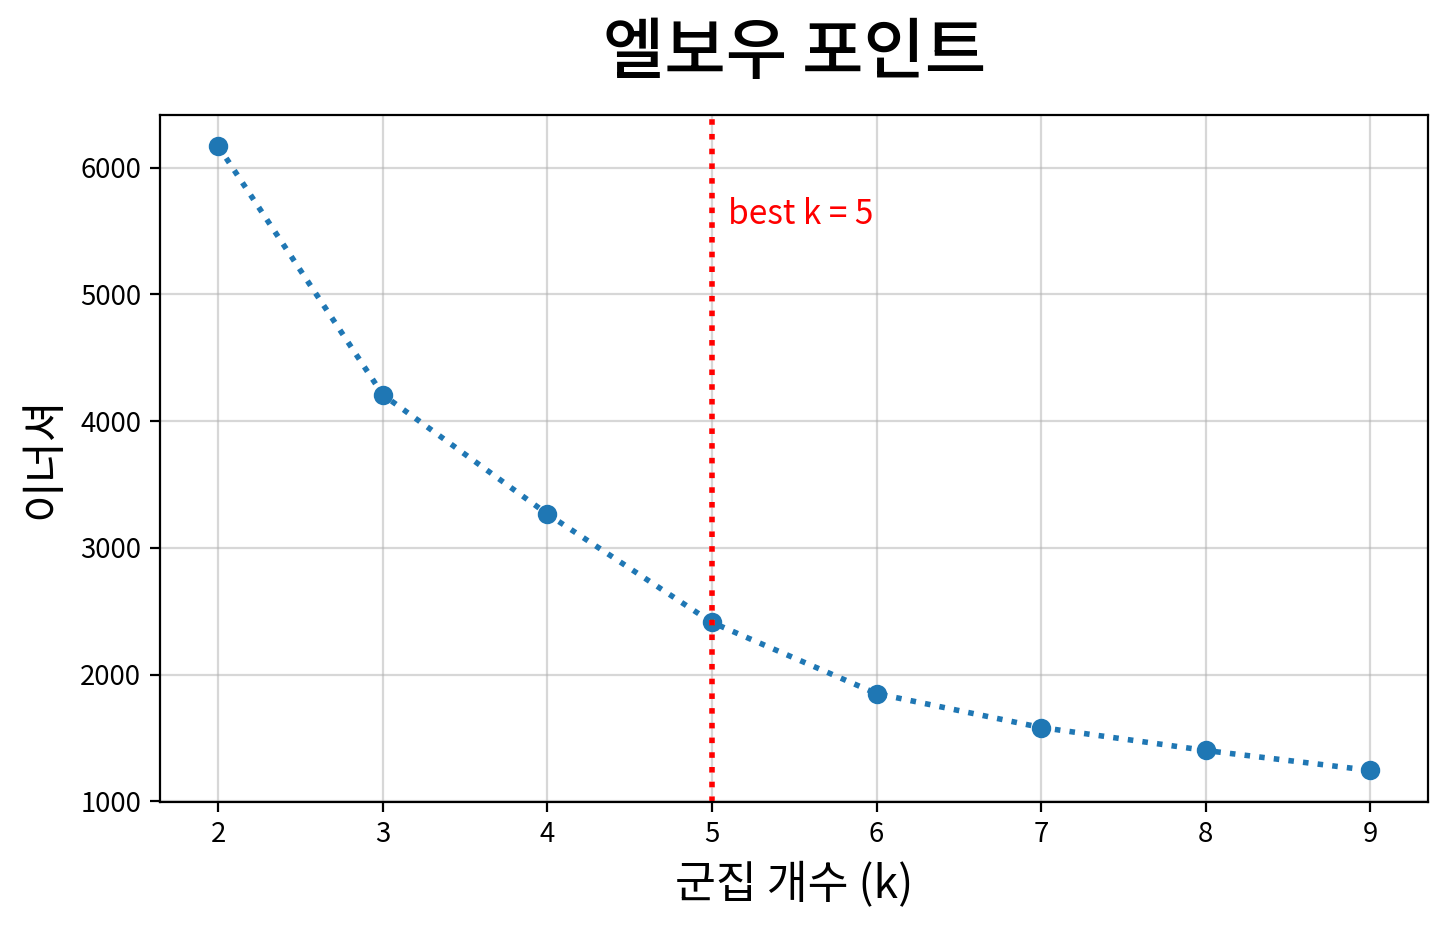

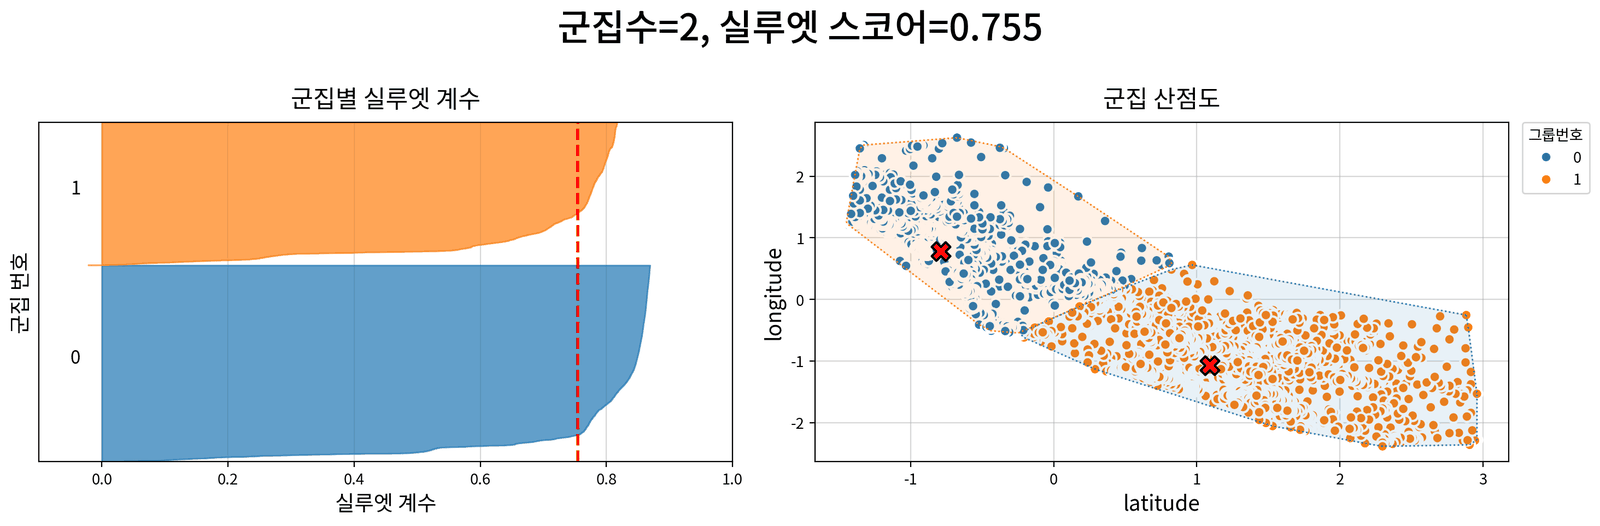

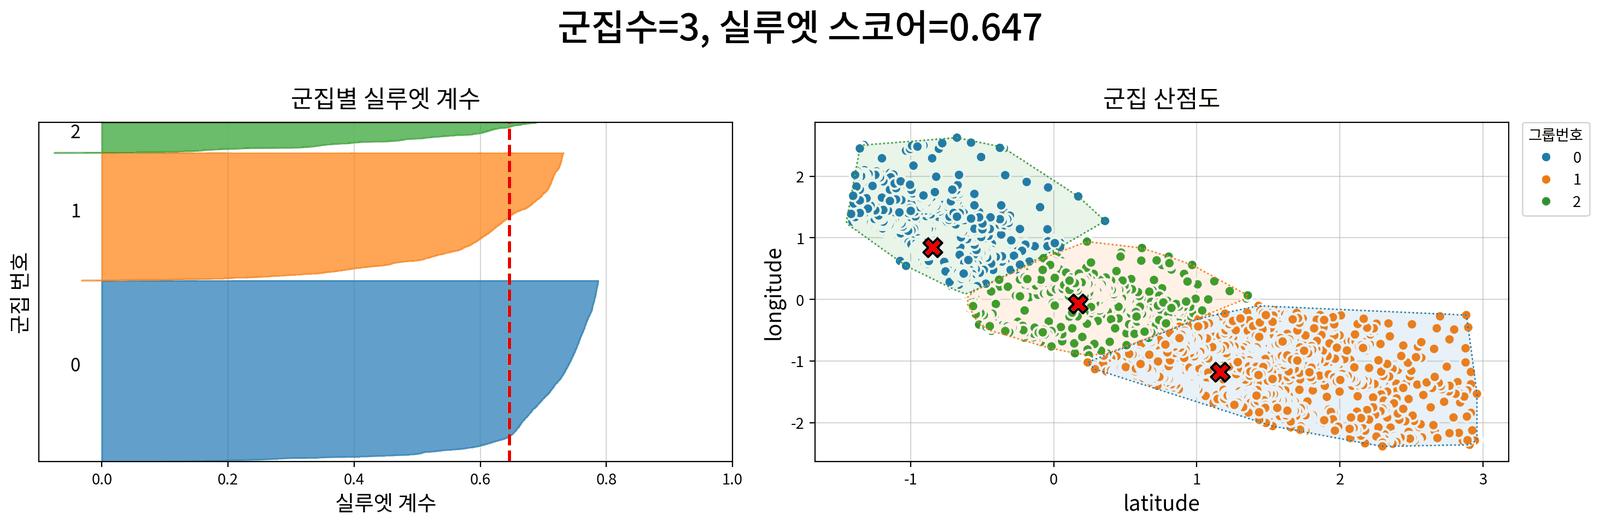

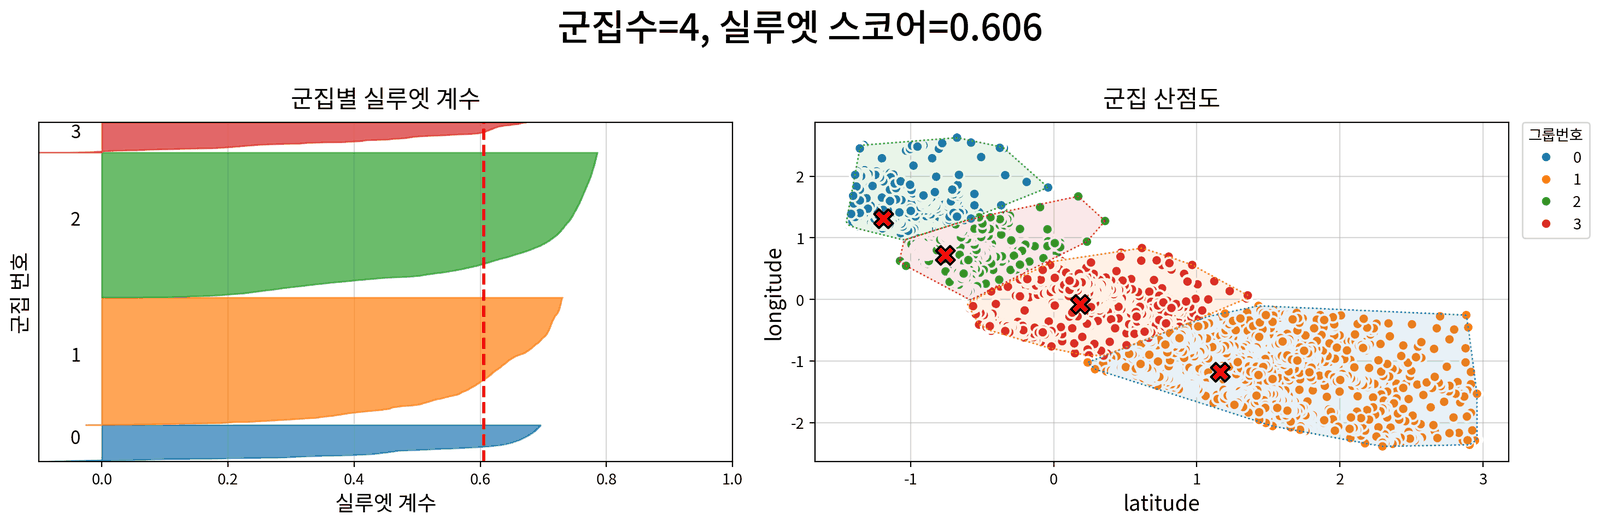

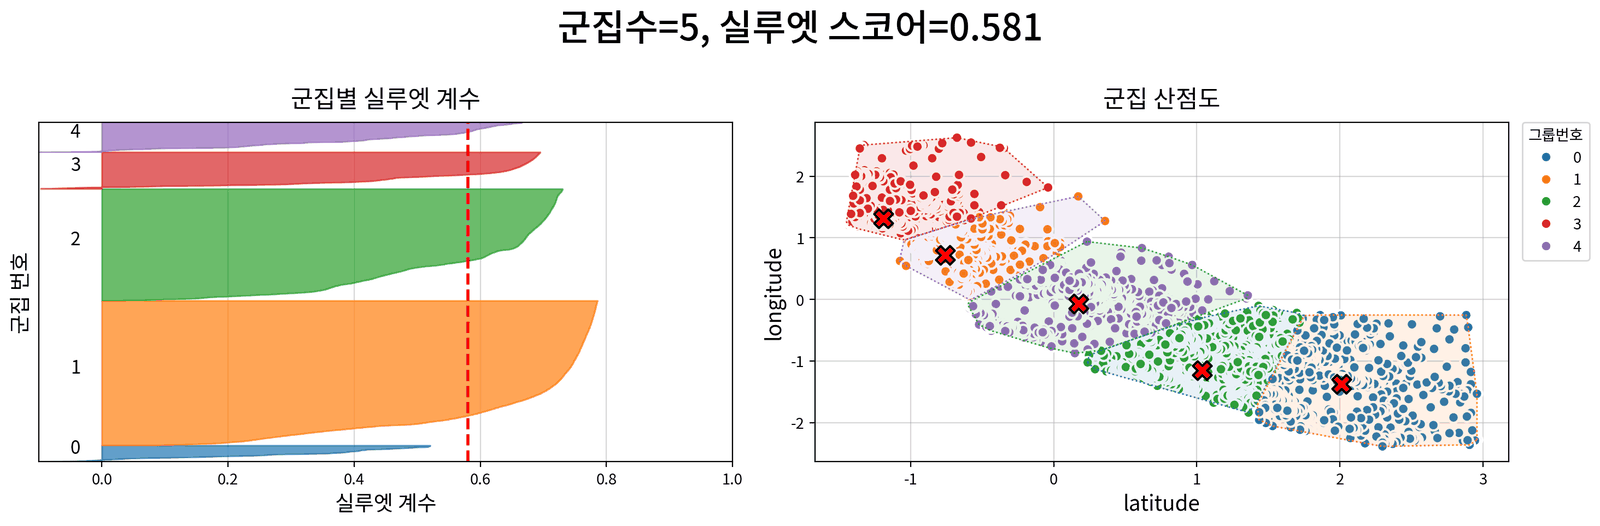

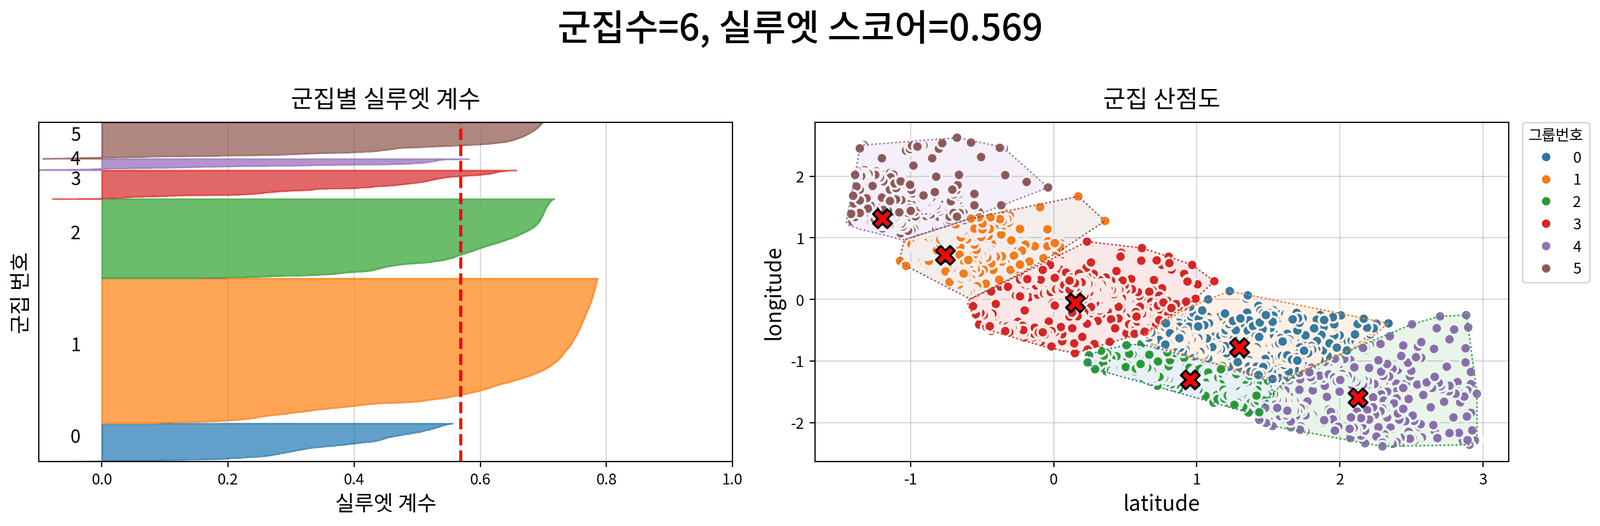

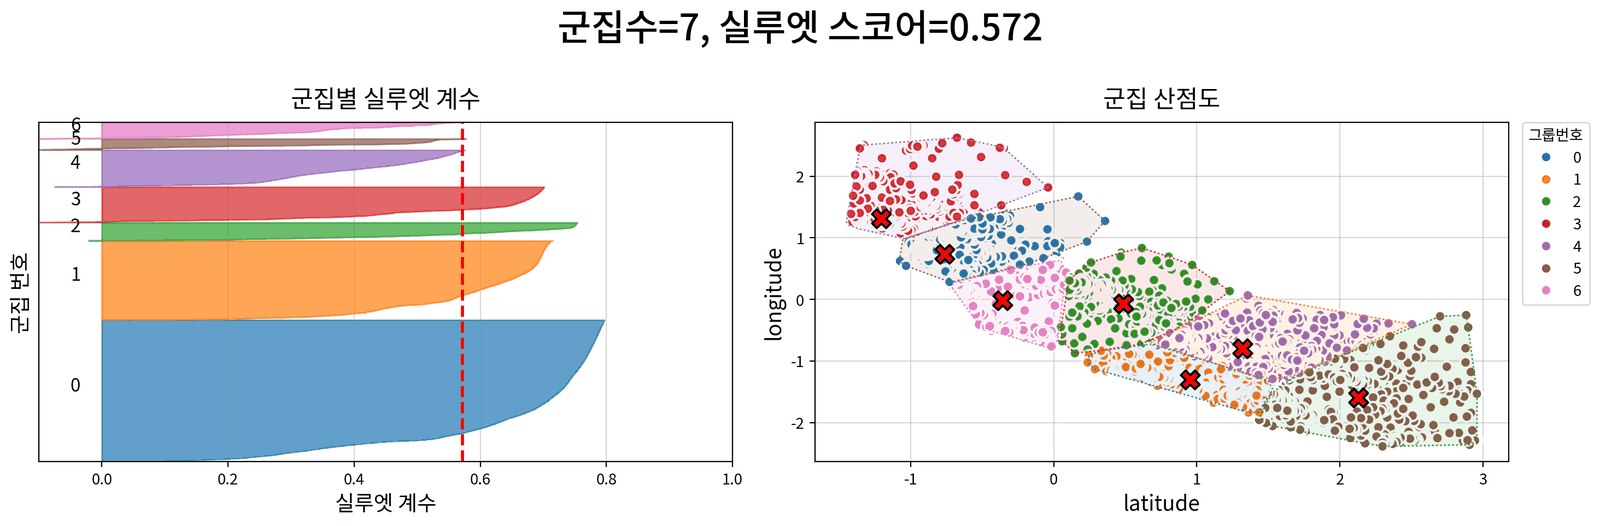

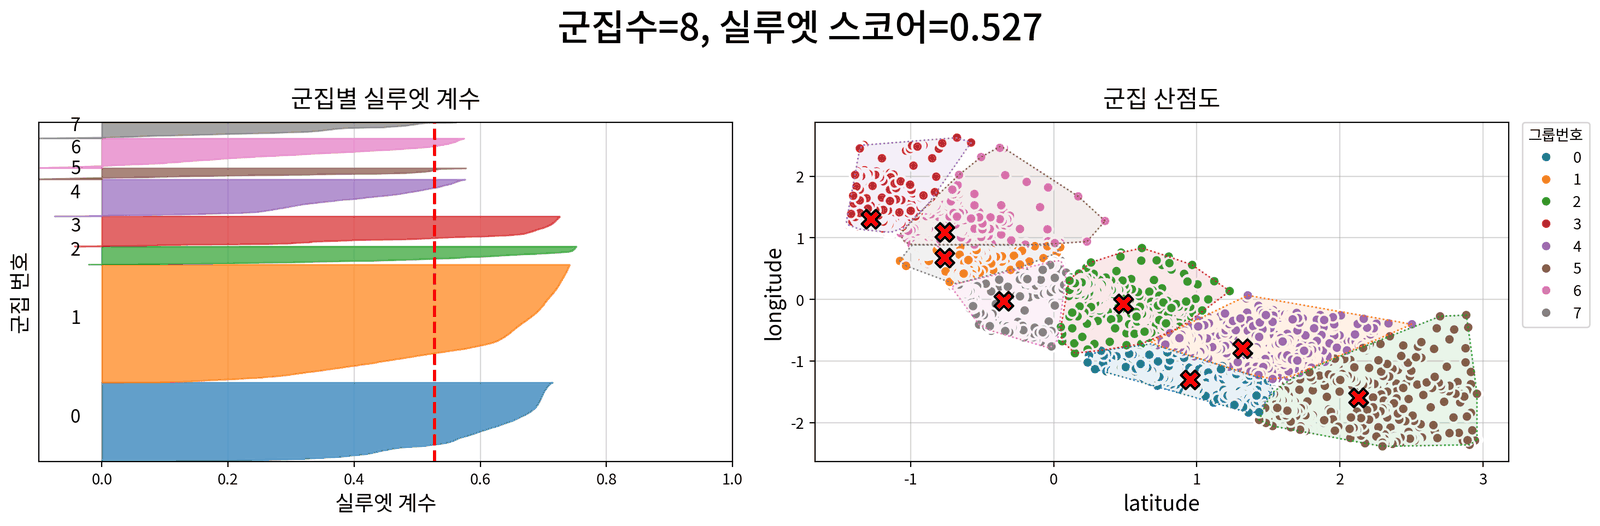

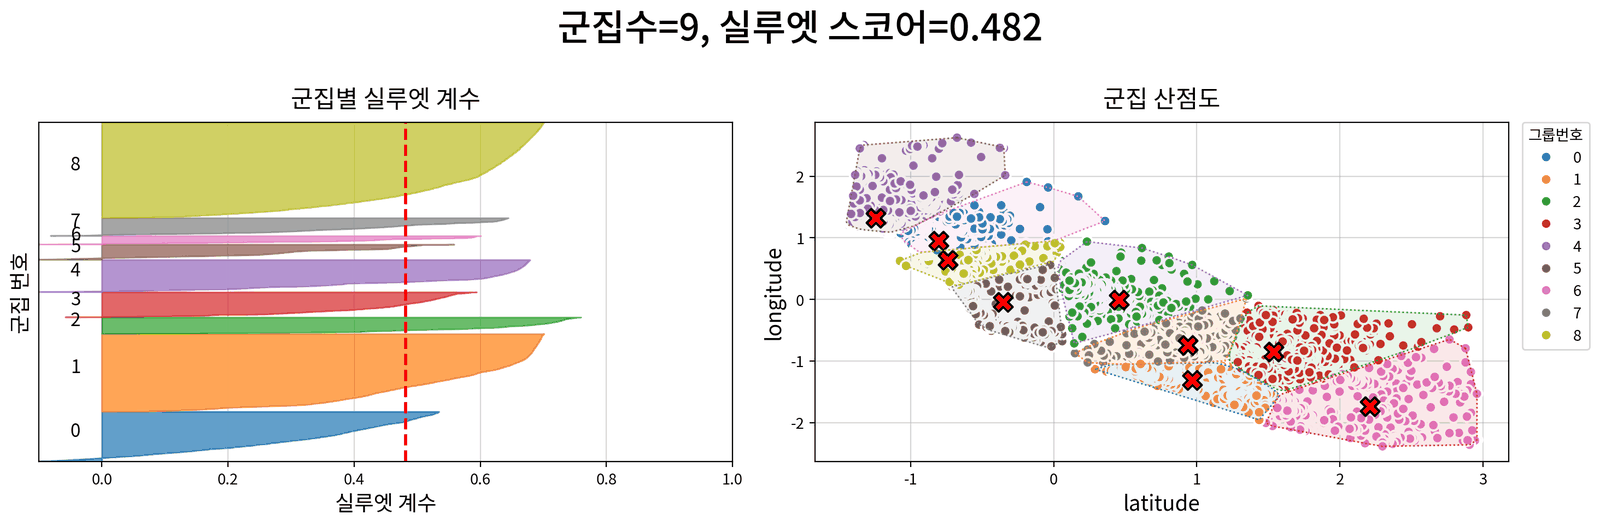

[1단계] 엘보운 포인트       : k = 5  (뭉침만 확인 -> 후보)
[2단계] 실루엣 균형지수     : k = 2  (뭉침 + 분리 + 크기 균형)
두 지표가 다른 k를 가리킵니다.
    · k = 5 : 균형지수 0.0075 (스코어 3   0.581
Name: 스코어, dtype: float64, 두께비 1.3762)
------------------------------------------------------------
>>> 최종 선택:k = 2
 (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


In [17]:
final_k, _ = my_cluster.best_k(df, klist=list(range(2, 10)), 
                               columns=['latitude', 'longitude'],
                               plot_each=True, width=740, height=480)

##### 💡 인사이트

- **k=2, 실루엣 0.755**: 📌 가장 높은 점수이고 두 군집의 구분이 가장 명확하게 보임
- **k=3, 실루엣 0.647**: 📉 2보다 점수가 내려가며, 추가 분할이 분리도 향상으로 이어지지 않음
- **k=4, 실루엣 0.606**: 📉 군집이 더 세분화되지만 품질은 계속 하락함
- **k=5, 실루엣 0.581**: 📉 엘보우와 일치하는 구간이지만, 실루엣 기준으로는 2~4보다 낮음
- **k=6, 실루엣 0.569**: 📉 추가 분할 효과가 크지 않았고 점수도 더 낮음
- **k=7, 실루엣 0.572**: 🔄 6보다 아주 약간 높지만, 전체 흐름에서는 여전히 낮은 편임
- **k=8, 실루엣 0.531**: 📉 점수가 더 떨어져 군집 품질이 약해짐
- **k=9, 실루엣 0.497**: 📉 제시된 값들 중 가장 낮아 군집 간 분리가 더 불리해짐

#### ✅ 최종 군집 수 선정

##### 🎯 k=2 양분화의 한계

- **단순성 문제**: 캘리포니아 주택시장을 단 2개 군집으로 나누면 본질적으로 "고가지역 vs 저가지역" 정도의 이분화만 가능함
- **지역적 다양성 미반영**: 제시된 플롯들에서 보면 k=2일 때 검은색과 초록색 두 덩어리로만 나뉘는데, 실제 캘리포니아 주택시장은 지역별로 더 복잡한 특성을 가지고 있을 가능성이 높음
- **파생변수로서의 유용성 부족**: 공간 특성을 반영한 파생변수를 만드는 목표라면, 2개 범주로는 모델 입력으로 활용할 때 정보량이 매우 제한적임

##### 🔄 k=5의 현실성

- **엘보우와의 일치**: k=5는 이너셔 감소 곡선의 꺾이는 지점과 일치하며, 이는 "충분한 분할"을 의미함
- **실루엣 점수 타당성**: 0.581은 k=2의 0.755보다 낮지만, 여전히 "중간 이상의 군집 품질"을 나타냄 (0.5 이상 기준)
- **실질적 해석 가능성**: k=5는 주택시장을 5개의 지리적·경제적 특성으로 나눌 수 있어 더 의미 있는 시장 분화 분석 가능

##### ✏️ 최종 선정 : **k=5**

1. 📊 **절충점**: 통계적 품질(0.581)과 실질적 유용성 사이의 최적점
2. 🗺️ **도메인 타당성**: 캘리포니아 주택시장의 다양한 지역특성을 충분히 반영
3. 🔧 **파생변수 활용성**: 모델에 입력할 때 정보손실이 적고, 해석 가능성도 높음
4. 📈 **엘보우 일치**: 통계적 근거도 함께 제시 가능

**k=2는 너무 단순하고, k=6 이상은 점수 개선 폭이 미미하므로, k=5가 가장 균형 잡힌 선택으로 여겨짐**

#### 2. 최종 군집 모형 적합

> 실루엣 점수 기준 최댓값은 `k=2`로 출력되지만, 다음 셀에서는 `final_k=5`로 재지정되어 이후 분석에 사용됩니다. 이 선택의 기준은 코드에 명시되어 있지 않습니다.


StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
latitude           32.54 ~ 41.95          -1.45 ~ 2.96
longitude      -124.35 ~ -114.31          -2.39 ~ 2.63


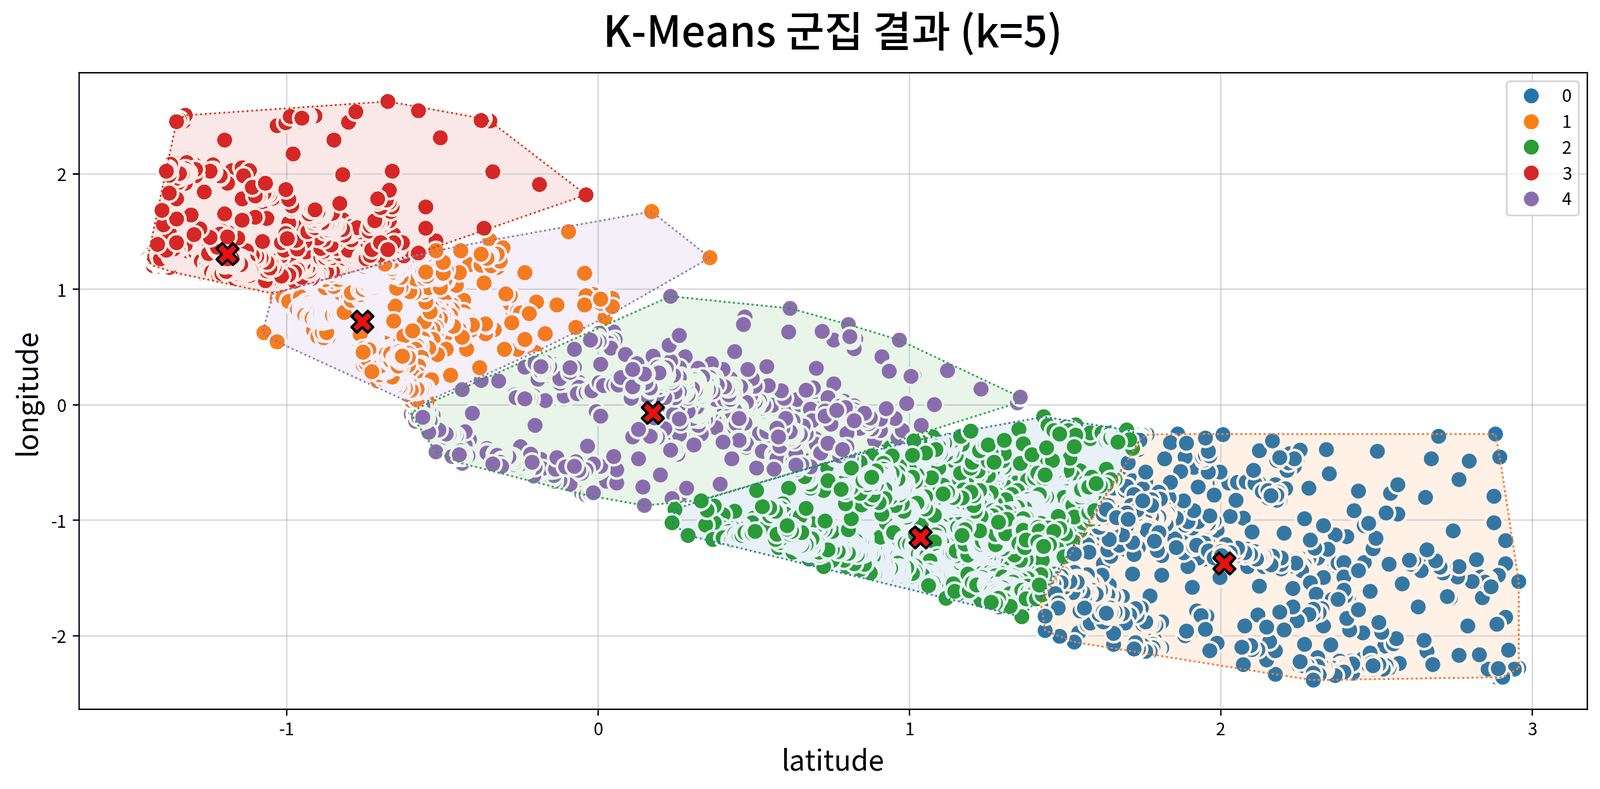

,latitude,longitude,그룹번호
0,1.052,-1.327,2
1,1.042,-1.322,2
2,1.038,-1.332,2
3,1.038,-1.337,2
4,1.038,-1.337,2
...,...,...,...
20428,1.801,-0.758,0
20429,1.805,-0.818,0
20430,1.777,-0.823,0
20431,1.777,-0.873,0


In [18]:
final_k = 5
estimator, cdf, _ = my_cluster.kmeans(df, k=final_k,
                        columns=['latitude', 'longitude'])
cdf

#### 3. 공간특성 반영 파생변수 추가

In [19]:
df["special_cluster"] = cdf["그룹번호"].astype("category")

# #02 와 같은 규칙으로 의미를 등록하고 목록 이름을 붙인다.
# -> #04 의 검증 반복문이 이 이름을 그대로 받아 쓴다.
column_means["special_cluster"] = "위경도 기반 공간 군집"
spatial_cols = ["special_cluster"]

df[['longitude', 'latitude', 'ocean_area', 'special_cluster']].head()

,longitude,latitude,ocean_area,special_cluster
0,-122.230,37.880,COASTAL,2
1,-122.220,37.860,COASTAL,2
2,-122.240,37.850,COASTAL,2
3,-122.250,37.850,COASTAL,2
4,-122.250,37.850,COASTAL,2


### #06. 파생변수 검증

#### 1. 검증 대상 분류

- 검증 대상은 새로 만든 파생변수 (원본 변수는 EDA에서 이미 확인함)

In [20]:
# 연속형 파생변수
derived_continuous = ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

# 범주형 파생변수
derived_nominal = ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']

print("연속형 파생 :", derived_continuous)
print("범주형 파생 :", derived_nominal)

연속형 파생 : ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']
범주형 파생 : ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']


#### 2. 연속형 기술 통계량

In [21]:
derived_num_desc = my_qtcheck.numerical_summary(df, columns=derived_continuous)
derived_num_desc.T

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person
count,20433.000,20433.000,20433.000,20433.000,20433.000
mean,1.978,5.431,0.213,3.072,1.409
std,1.150,2.483,0.058,10.438,0.755
min,0.003,0.846,0.100,0.692,0.008
25%,1.524,4.441,0.175,2.429,0.870
50%,1.938,5.231,0.203,2.818,1.296
75%,2.297,6.052,0.240,3.282,1.777
max,55.222,141.909,1.000,1243.333,7.550
rel_diff,0.021,0.038,0.049,0.090,0.087
rdiff_flag,similar,similar,similar,similar,similar


#### 3. 범주형 기술 통계량

- 플래그와 병합된 범주, 군집분석 결과는 값의 종류가 2개인 범주형이므로 category 타입으로 변환해 요약한다.

In [22]:
df = my_qtcheck.set_type(df, as_category=derived_nominal)

derived_cat_desc = my_qtcheck.categorical_summary(df, 
                        columns=derived_nominal, value_counts=False)
derived_cat_desc

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 20433 non-null  float64 
 1   latitude                  20433 non-null  float64 
 2   housing_median_age        20433 non-null  int64   
 3   total_rooms               20433 non-null  int64   
 4   total_bedrooms            20433 non-null  float64 
 5   population                20433 non-null  int64   
 6   households                20433 non-null  int64   
 7   median_income             20433 non-null  float64 
 8   median_house_value        20433 non-null  int64   
 9   ocean_proximity           20433 non-null  category
 10  rooms_per_person          20433 non-null  float64 
 11  rooms_per_household       20433 non-null  float64 
 12  bedrooms_per_room         20433 non-null  float64 
 13  population_per_household  20433 non-null  floa

,is_age_capped,is_income_capped,ocean_area,special_cluster
count,20433,20433,20433,20433
unique,2,2,2,5
top,0,0,COASTAL,1
freq,19168,20383,13937,8729


#### 4. 단변량 분석 (연속형 파생변수)

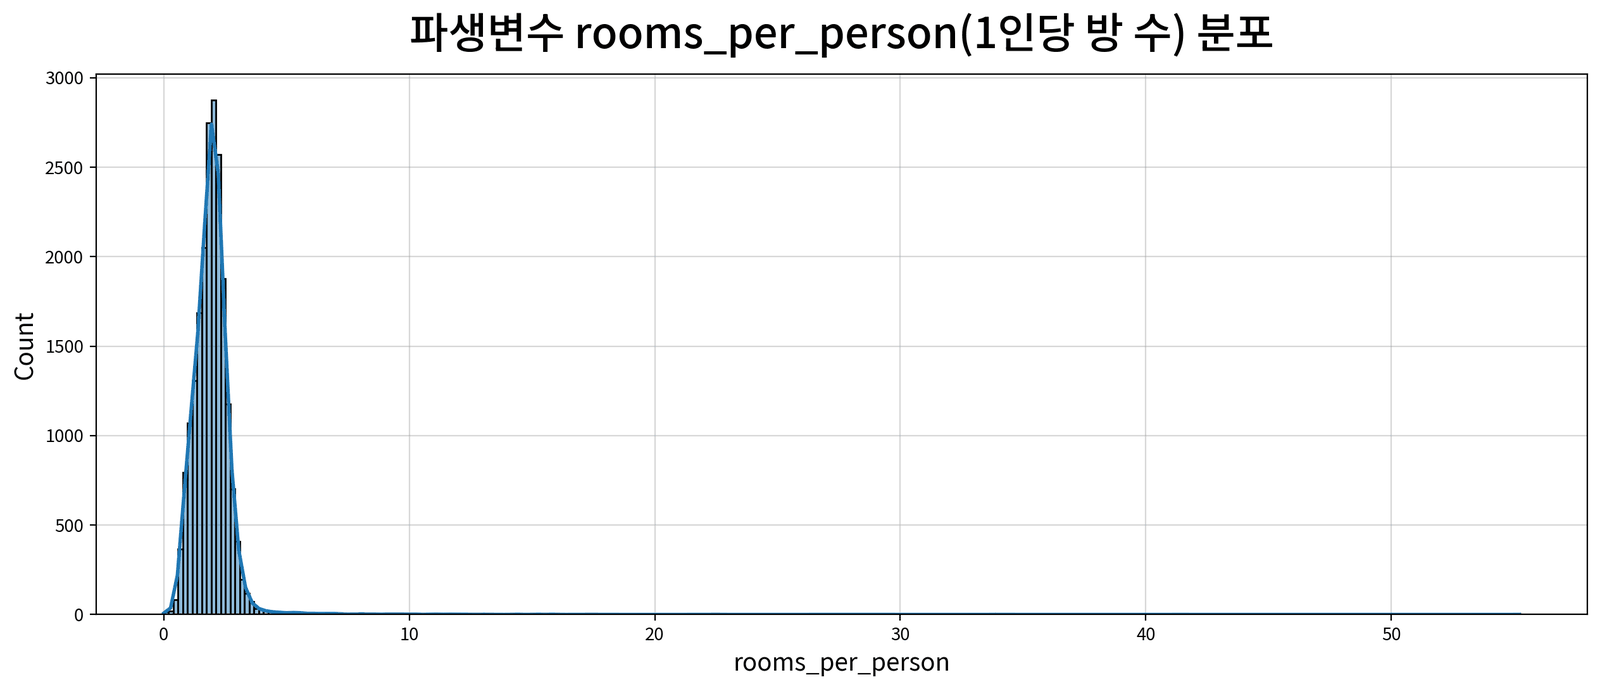

,rooms_per_person
count,20433.000
mean,1.978
std,1.150
min,0.003
25%,1.524
50%,1.938
75%,2.297
max,55.222
rel_diff,0.021
rdiff_flag,similar


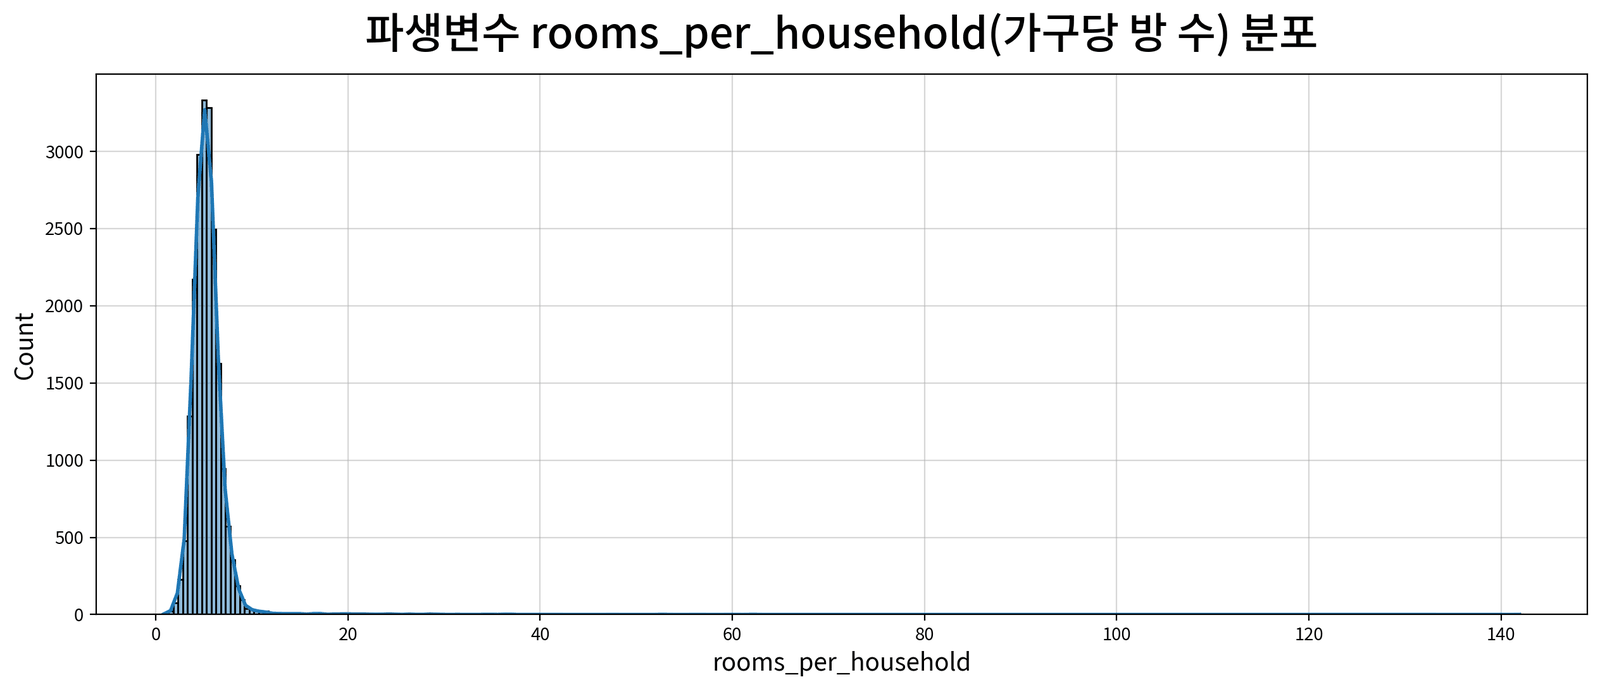

,rooms_per_household
count,20433.000
mean,5.431
std,2.483
min,0.846
25%,4.441
50%,5.231
75%,6.052
max,141.909
rel_diff,0.038
rdiff_flag,similar


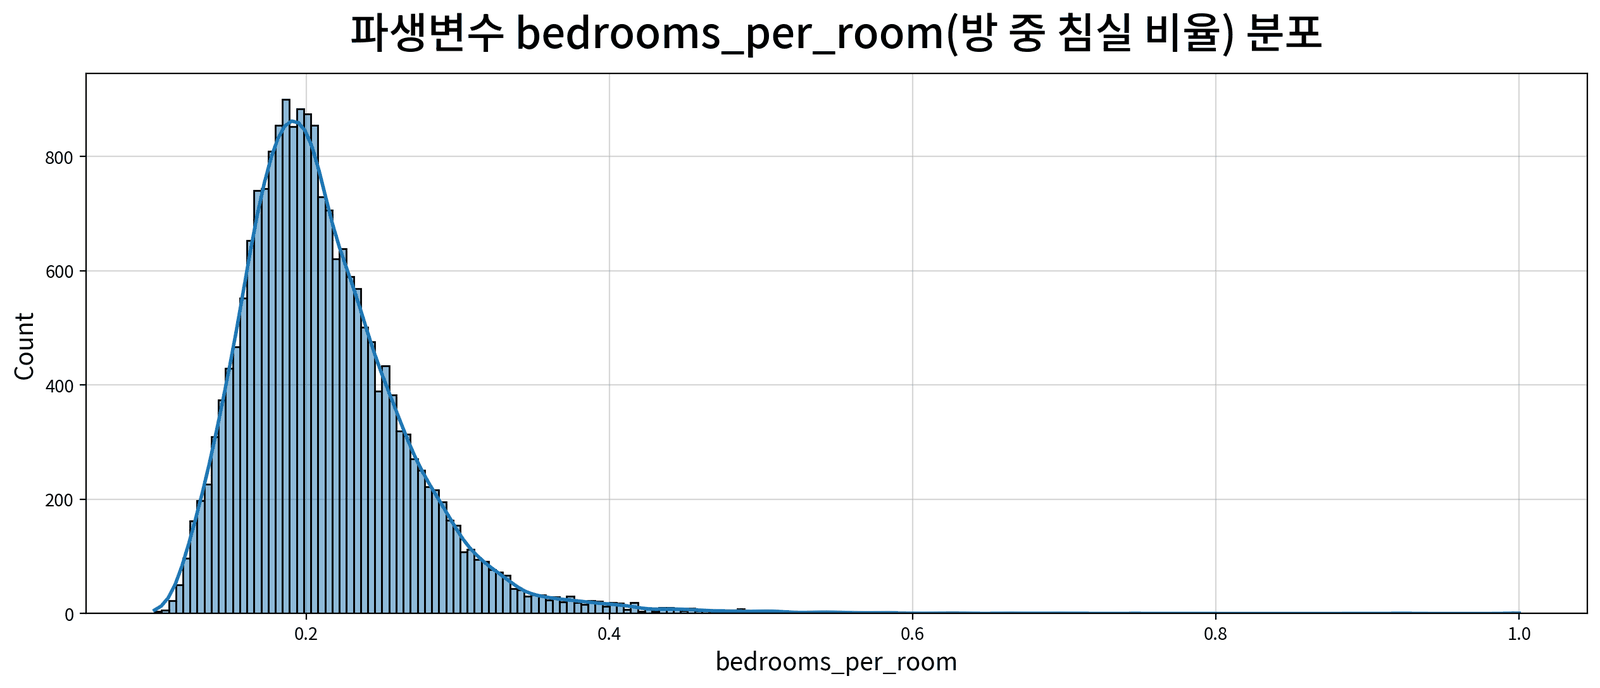

,bedrooms_per_room
count,20433.000
mean,0.213
std,0.058
min,0.100
25%,0.175
50%,0.203
75%,0.240
max,1.000
rel_diff,0.049
rdiff_flag,similar


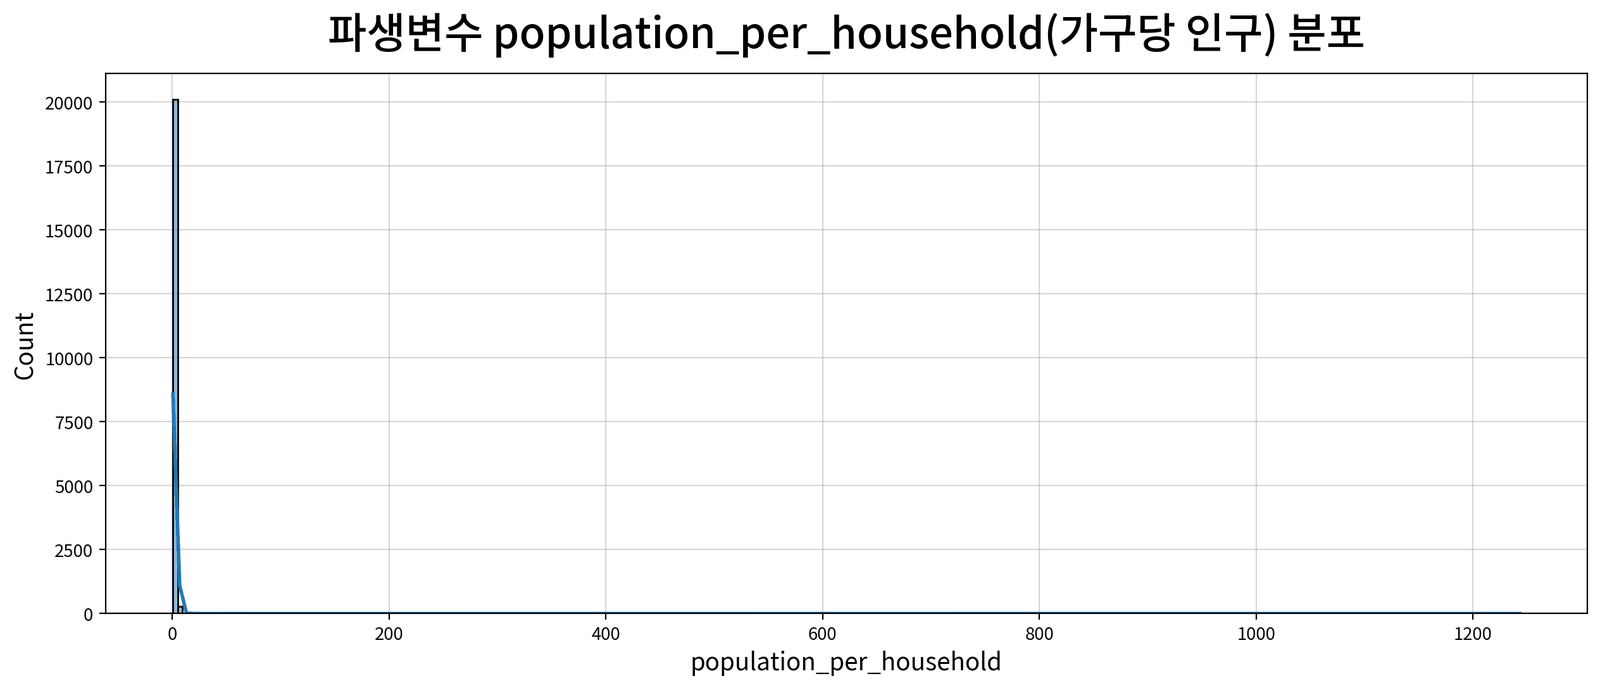

,population_per_household
count,20433.000
mean,3.072
std,10.438
min,0.692
25%,2.429
50%,2.818
75%,3.282
max,1243.333
rel_diff,0.090
rdiff_flag,similar


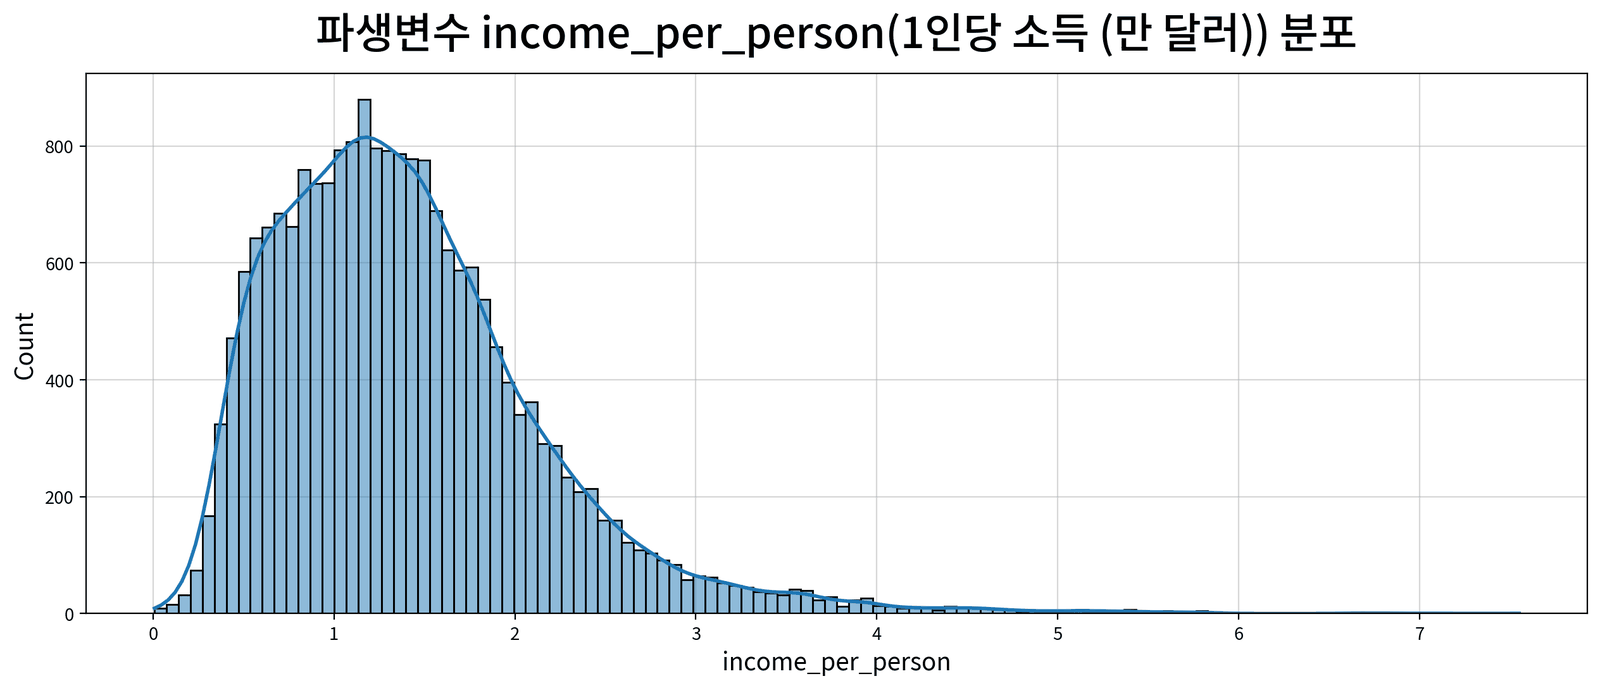

,income_per_person
count,20433.000
mean,1.409
std,0.755
min,0.008
25%,0.870
50%,1.296
75%,1.777
max,7.550
rel_diff,0.087
rdiff_flag,similar


In [23]:
for f in derived_continuous:
    # 히스토그램만 그리는 경우
    my_plot.histplot(data=df, x=f, kde=True, width=1280, height=560,
                    title=f"파생변수 {f}({column_means[f]}) 분포")

    display(derived_num_desc[derived_num_desc.index == f].T)

##### 인사이트

| 변수 | 분포 모양(왜도) | 첨도 | 이상치 | 판단·조치 |
|---|---|---|---|---|
| `income_per_person` | 중간 우편향 (+1.46) | 4.2 | 616건 (3.0%) | 5종 중 가장 온건. 원본 `median_income`(+1.65)보다 개선 |
| `bedrooms_per_room` | 우편향 (+2.25) | 14.4 | 582건 (2.8%) | 분자·분모가 같은 방향으로 움직여 비율이 안정 |
| `rooms_per_person` | 극단 우편향 (+17.76) | 597.9 | 399건 (2.0%) | 로그 변환 필요 |
| `rooms_per_household` | 극단 우편향 (+20.68) | 875.7 | 508건 (2.5%) | 로그 변환 필요 |
| `population_per_household` | 최악 (+97.16) | 10,545.2 | 709건 (3.5%) | 로그 변환 필요. 원인 확인 요망 |

#### 5. 단변량 분석 (범주형 파생변수)

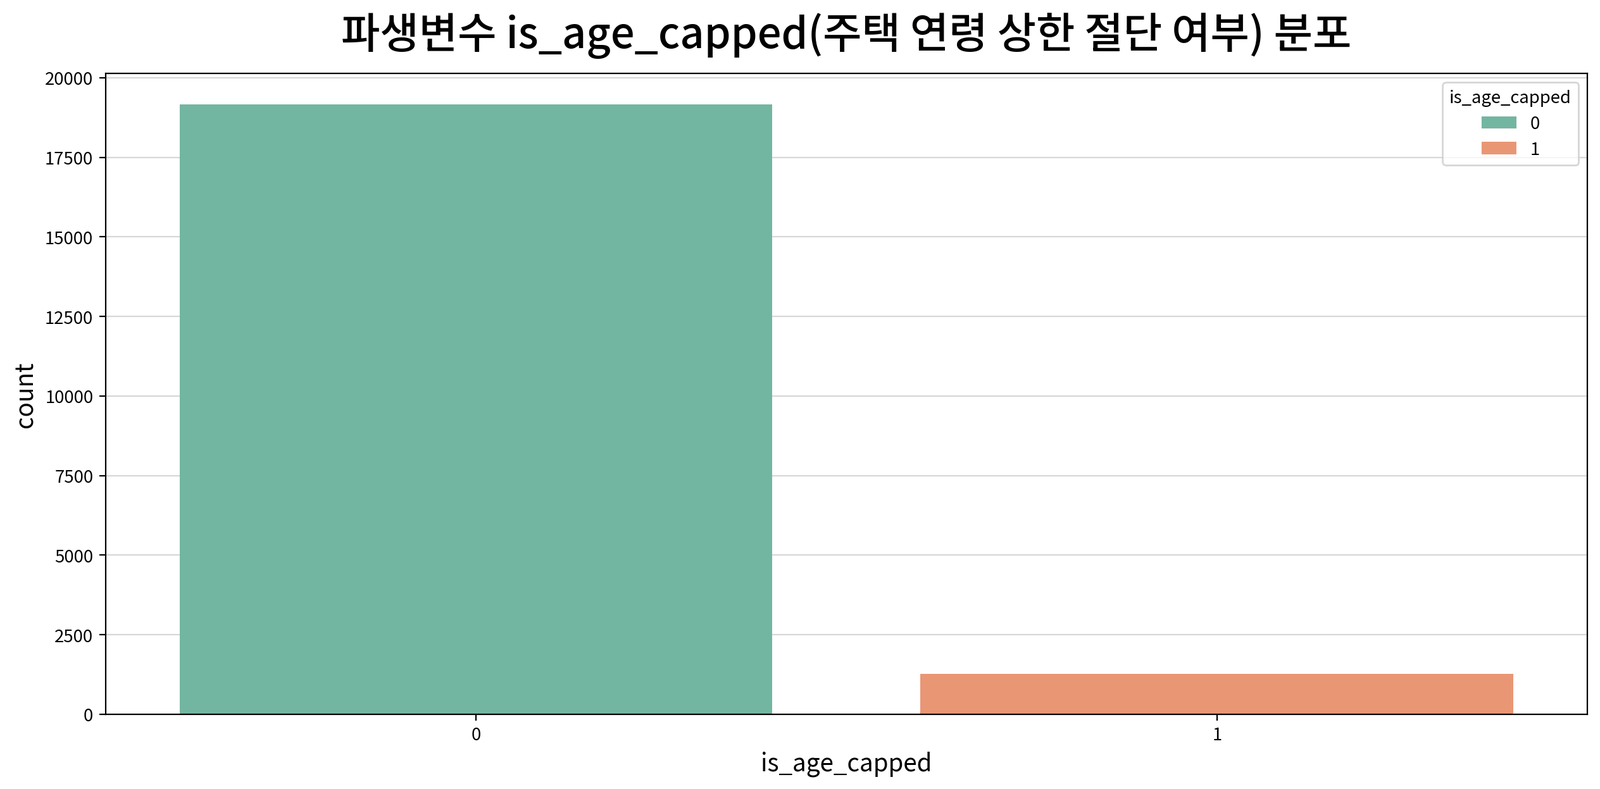

,count,unique,top,freq
is_age_capped,20433,2,0,19168


,빈도,비율
is_age_capped,,
0,19168,0.938
1,1265,0.062


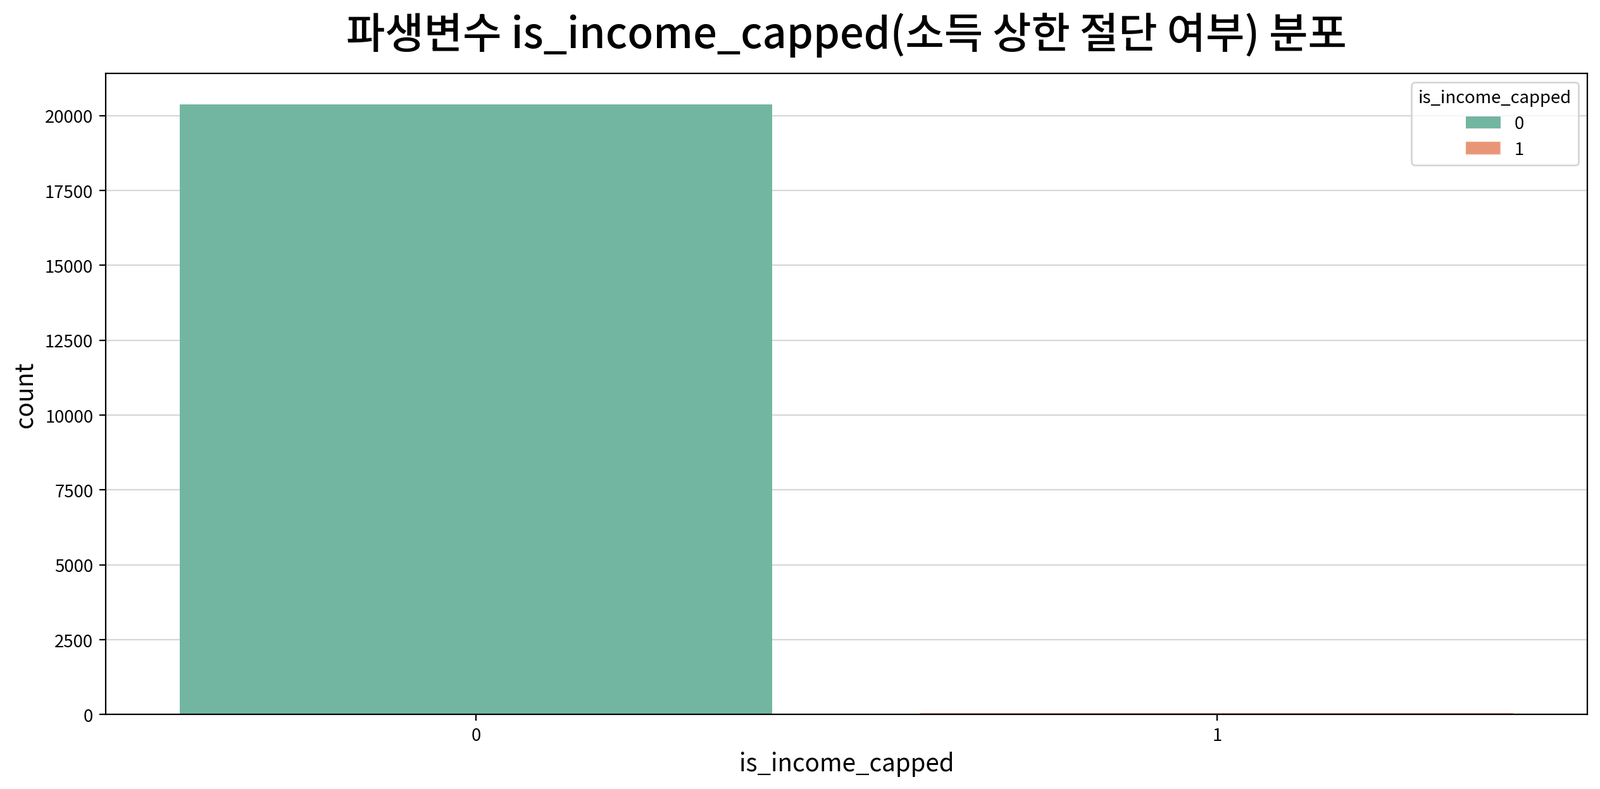

,count,unique,top,freq
is_income_capped,20433,2,0,20383


,빈도,비율
is_income_capped,,
0,20383,0.998
1,50,0.002


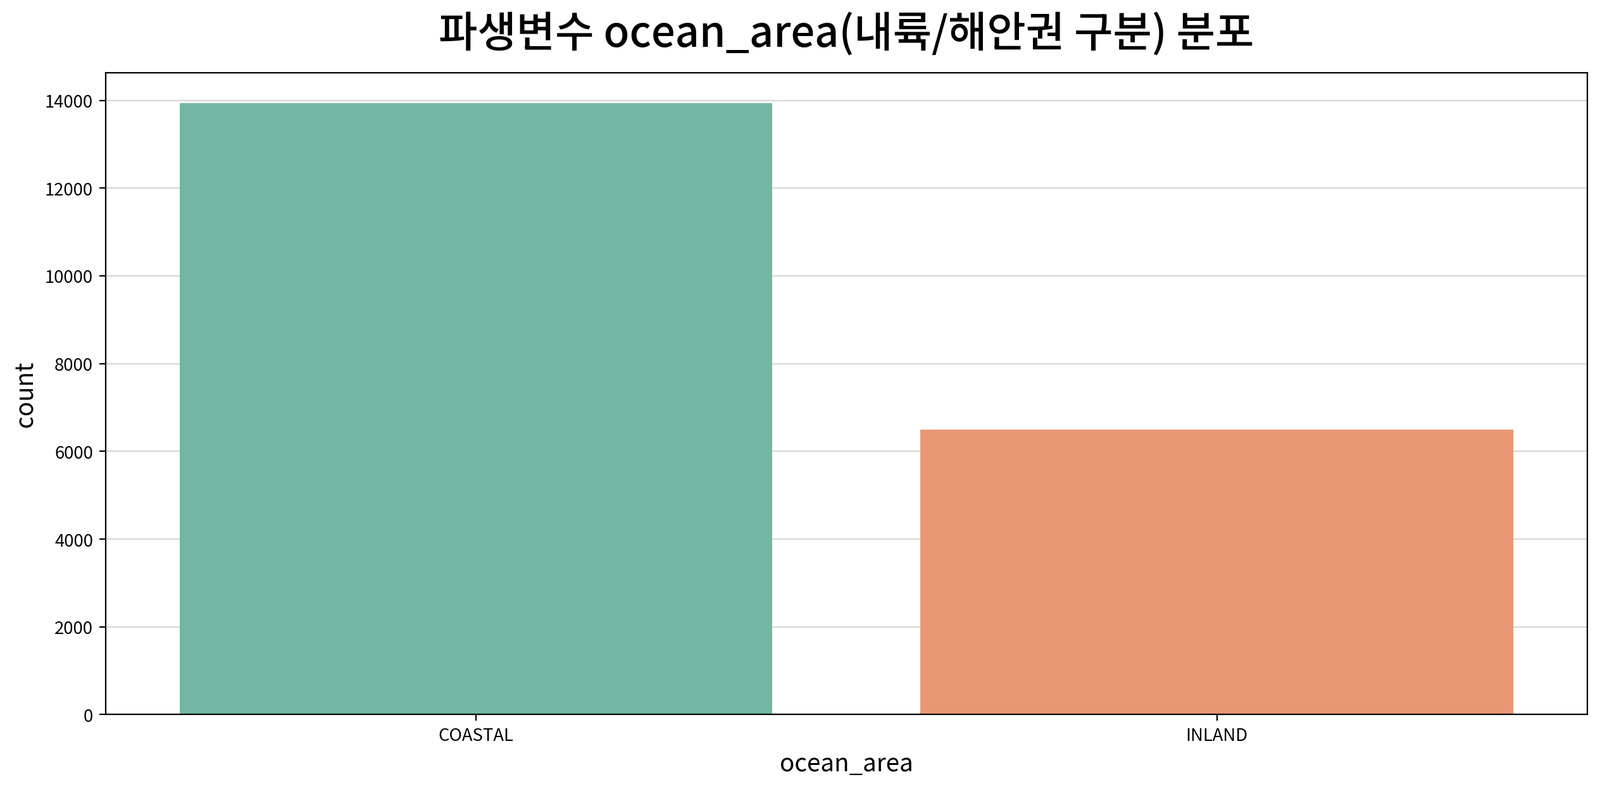

,count,unique,top,freq
ocean_area,20433,2,COASTAL,13937


,빈도,비율
ocean_area,,
COASTAL,13937,0.682
INLAND,6496,0.318


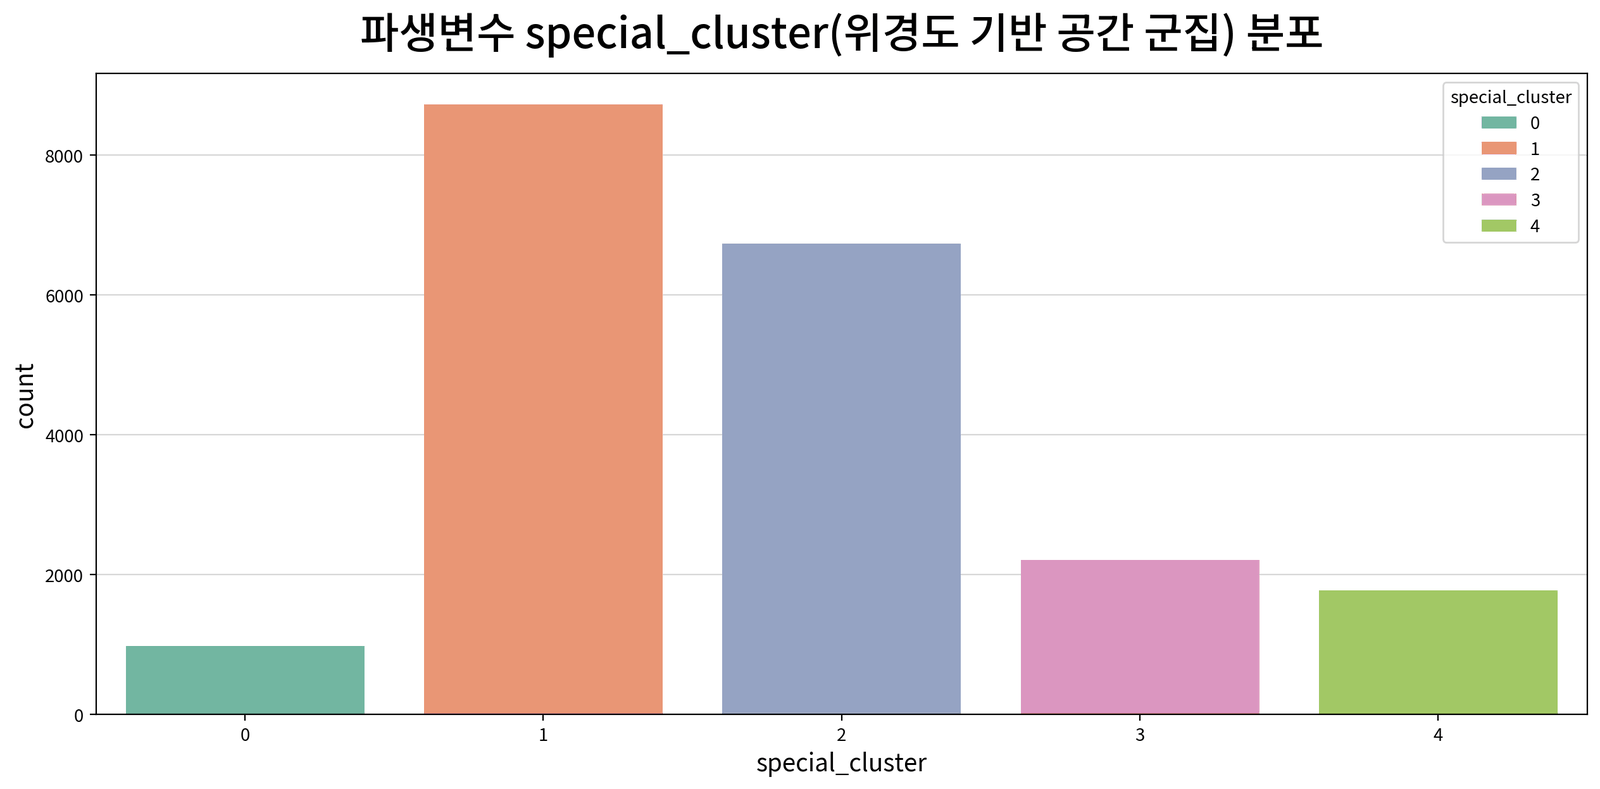

,count,unique,top,freq
special_cluster,20433,5,1,8729


,빈도,비율
special_cluster,,
1,8729,0.427
2,6736,0.330
3,2211,0.108
4,1778,0.087
0,979,0.048


In [24]:
for n in derived_nominal:
    # 범주형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2",
                      title=f"파생변수 {n}({column_means[n]}) 분포")

    # 범주형 기술통계량
    display(derived_cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

##### 인사이트

| 변수 | 범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|---|
| `ocean_area` | 2 | COASTAL 13,937 (68.2%) | INLAND : 6,496건 (31.8%) | 양호 | 병합 목적 달성 |
| `is_age_capped` | 2 | 0 : 19,168 (93.8%) | 1 : 1,265건 (6.2%) | 불균형 | 검정에 충분 |
| `is_income_capped` | 2 | 0 : 20,383 (99.8%) | 1 : 50건 (0.2%) | 극심한 불균형 | 심한 불균형. 채택하지 않는 것을 고려 |
| `special_cluster` | 5 | 1 : 8729 (42.7%) | 0 : 979건 (0.4%) | 극심한 불균형 | 주의 |

- **`ocean_area`의 병합은 의도대로 작동했다.** 병합 전 `ocean_proximity`는 최빈 44.2%\~최소 0.02%(`ISLAND` 5건)의 5범주였다. 2범주로 줄인 뒤 최소 범주가 6,496건(31.8%)이 되어 불균형 문제가 사라졌다.
- **`is_income_capped` 50건(0.2%)은 EDA의 `ISLAND` 5건과 같은 성격의 문제다.** 표본이 적으면 그 범주의 추정치가 불안정해진다. `ISLAND`는 병합으로 해결했지만 이 플래그는 병합할 대상이 없으므로, 투입 여부를 별도로 판단해야 한다(`#03-6`에서 다시 본다).
- `is_age_capped`는 1,265건(6.2%)으로 소수 범주지만 검정에는 충분하다.

#### 6. 상관분석 (x: 연속형 파생변수 → y: 연속형 종속변수)

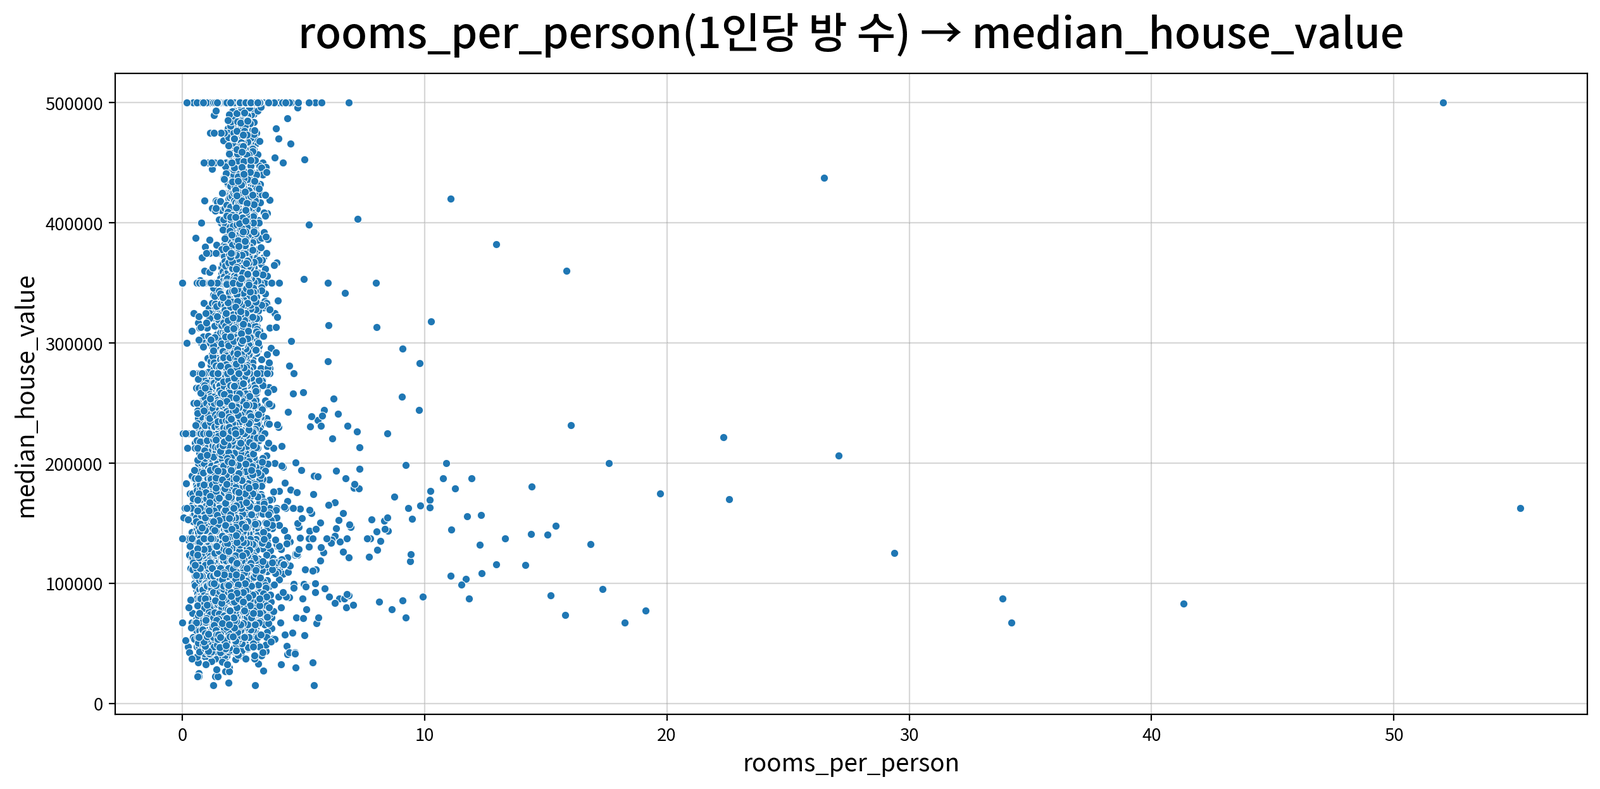

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
rooms_per_person,median_house_value,Spearman,0.400,0.000,Moderate,True,False,False,False,True,True


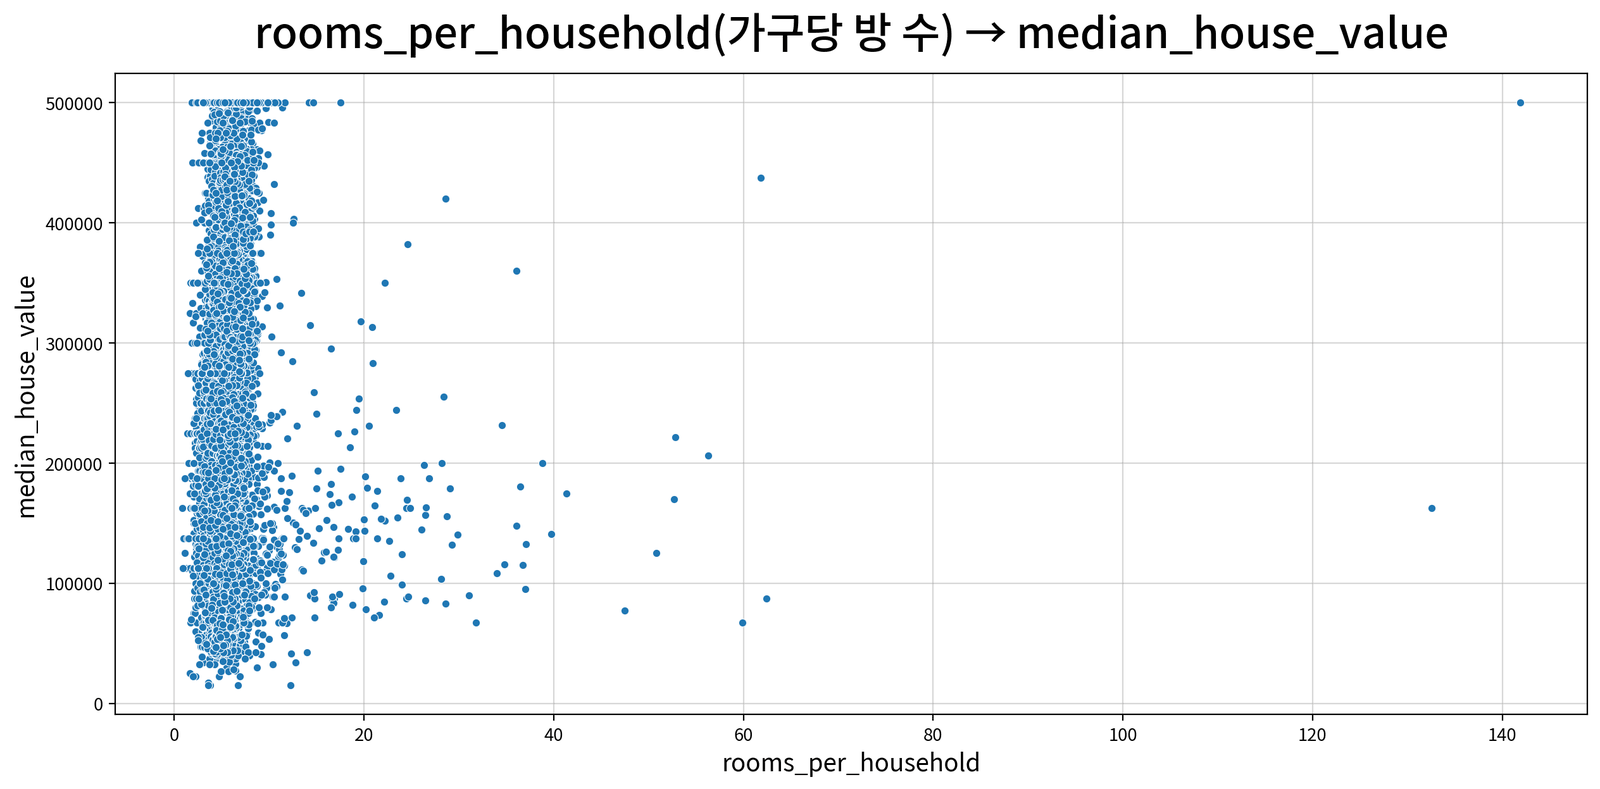

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
rooms_per_household,median_house_value,Spearman,0.263,0.000,Weak,True,False,False,False,True,True


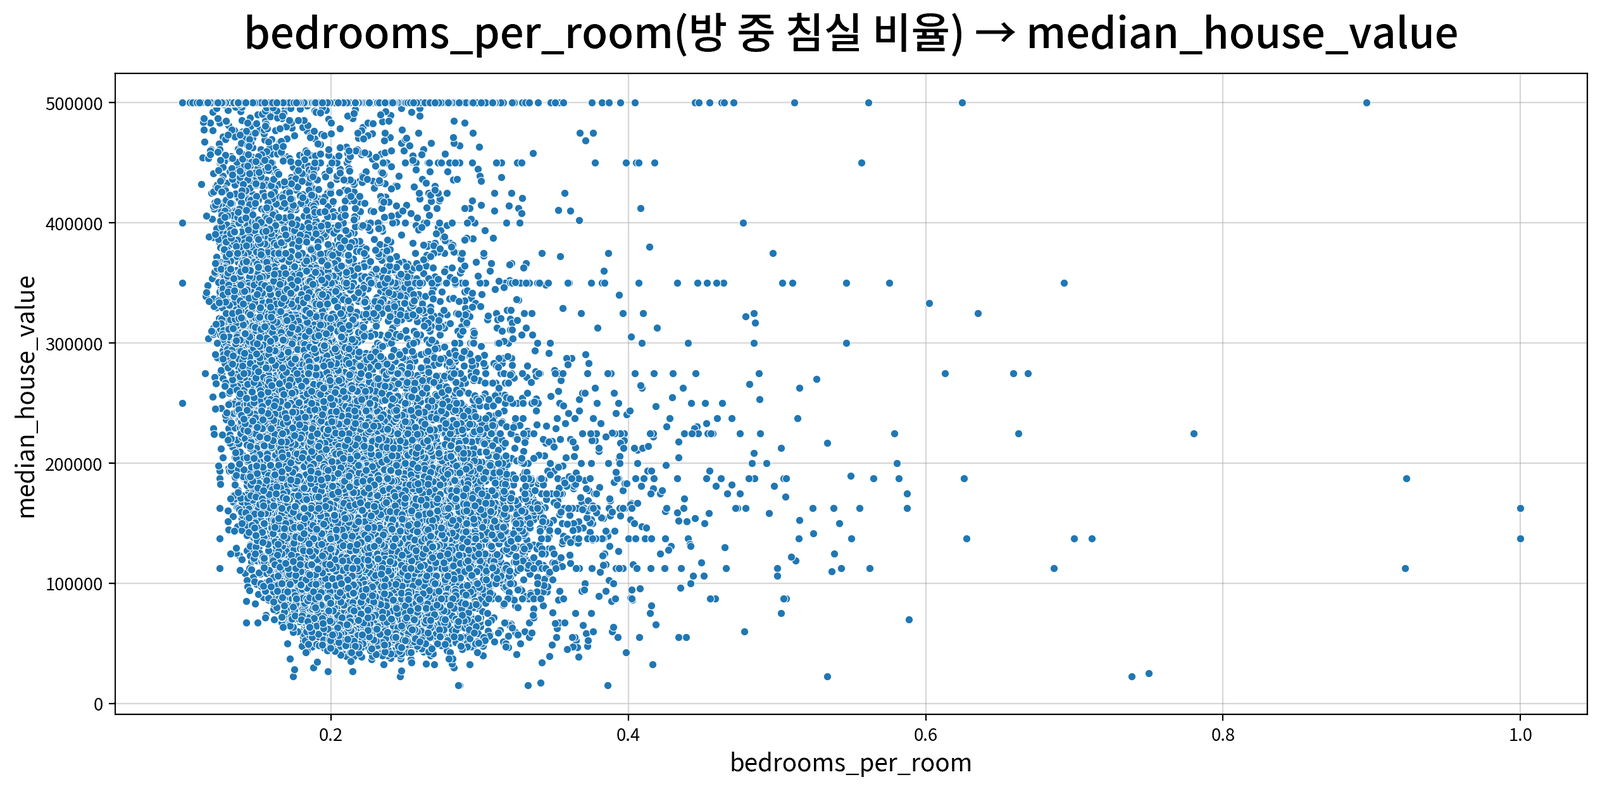

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bedrooms_per_room,median_house_value,Spearman,-0.332,0.000,Moderate,True,False,False,False,False,True


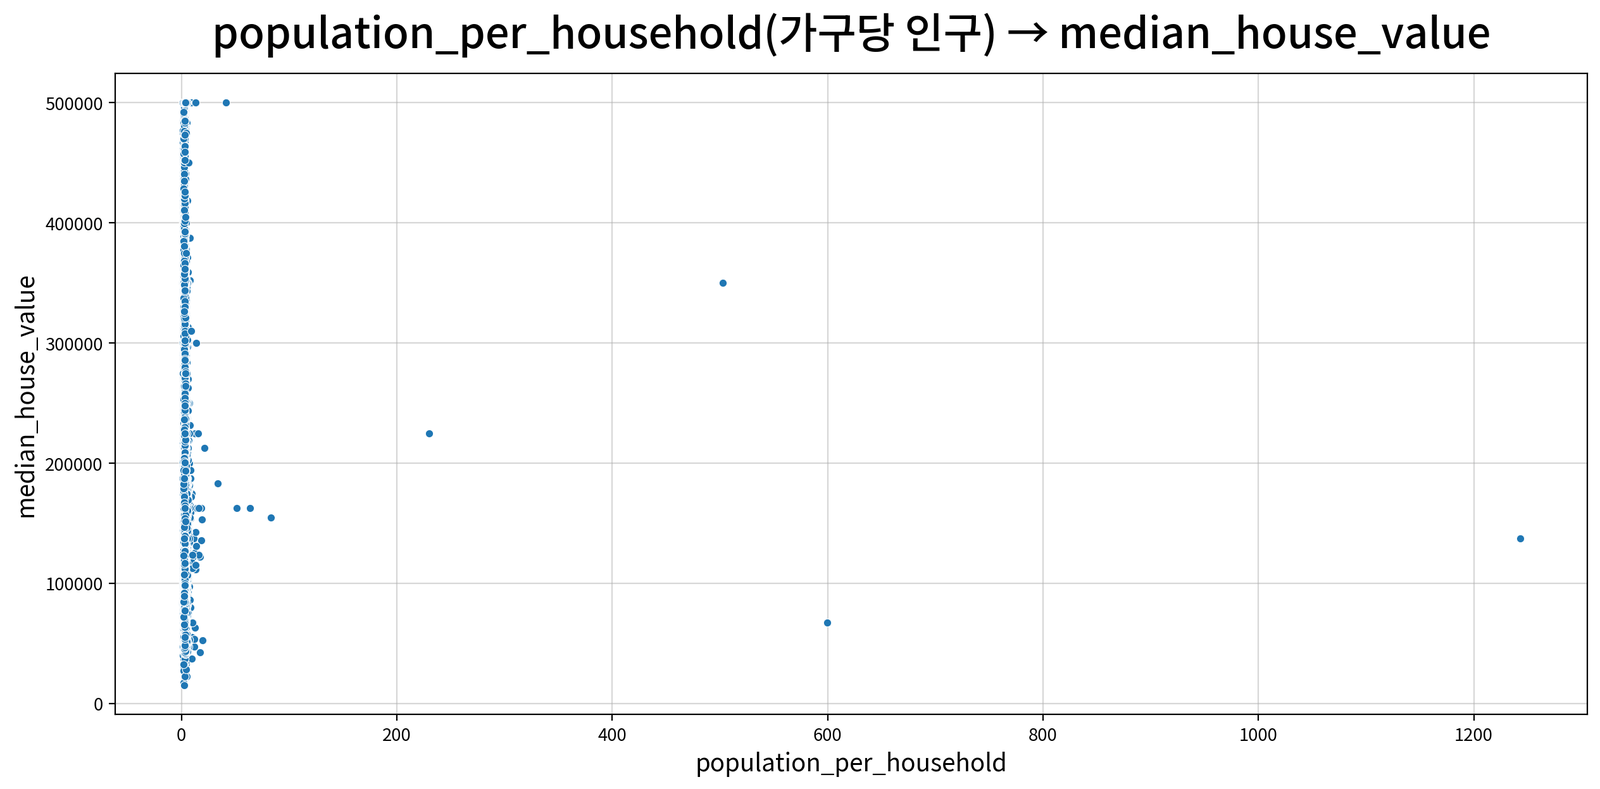

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
population_per_household,median_house_value,Spearman,-0.256,0.000,Weak,True,False,False,False,True,True


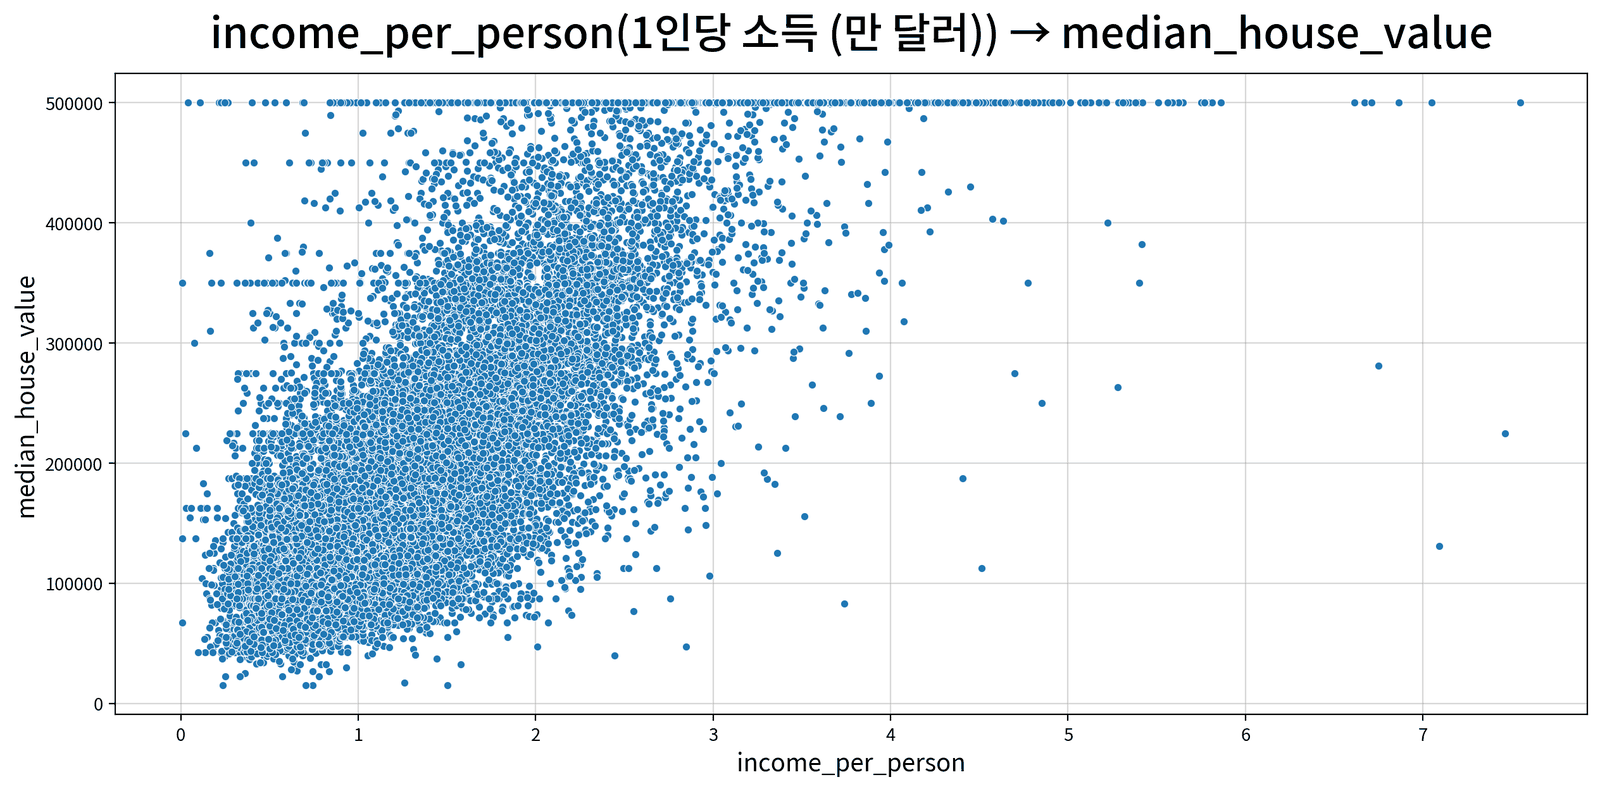

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
income_per_person,median_house_value,Spearman,0.722,0.000,Strong,True,False,False,False,False,True


In [25]:
# 연속형 파생변수 이름을 탐색하면서 반복
for f in derived_continuous:
    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        linewidth=0.4, size=20,
                        title=f"{f}({column_means[f]}) → {target}")

    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

##### 인사이트

| 변수 | method | coef | strength | p-value | significant |
|---|---|---|---|---|---|
| `income_per_person` | Spearman | **+0.722** | **Strong** | 0.000 | True |
| `rooms_per_person` | Spearman | +0.400 | Moderate | 0.000 | True |
| `bedrooms_per_room` | Spearman | **−0.332** | Moderate | 0.000 | True |
| `rooms_per_household` | Spearman | +0.263 | Weak | 0.000 | True |
| `population_per_household` | Spearman | −0.256 | Weak | 0.000 | True |

###### 결과표에서 읽은 것

- **파생 5종 모두 유의하다(p=0.000).** EDA에서 유일하게 비유의했던 `population`(p=0.681)이 분모로 들어간 `rooms_per_person`·`population_per_household`도 마찬가지다. 단독으로는 관계가 없던 변수가 다른 변수와 조합되면서 정보를 갖게 됐다.
- **`strength`가 Weak이 아닌 변수가 3종으로 늘었다.** EDA에서는 6종 중 `median_income` 하나뿐이었다. 규모 효과가 가격 신호를 덮고 있었다는 EDA의 판단이 수치로 확인된 셈이다.
- **`income_per_person`이 이 데이터셋에서 유일한 Strong 변수다.** 소득은 가구 단위로 기록되어 있지만, 집값을 좌우하는 것은 1인당 구매력에 더 가깝다는 해석이 가능하다.
- **`bedrooms_per_room`만 부호가 음수다.** 방 중 침실 비율이 낮을수록(= 거실·기타 공간이 넓을수록) 비싸다는 뜻이다. 총량 변수로는 관측할 수 없던 관계다.
  → 근거: `coef` 열

#### 7. T-Test (x: 2집단 범주형 파생변수 → y: 종속변수)

범주형 파생변수 중 **2집단인 것만** 여기서 검정한다.

#### ▶︎ is_age_capped(주택 연령 상한 절단 여부) → median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.136e-75 U_stat=8.384e+06


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


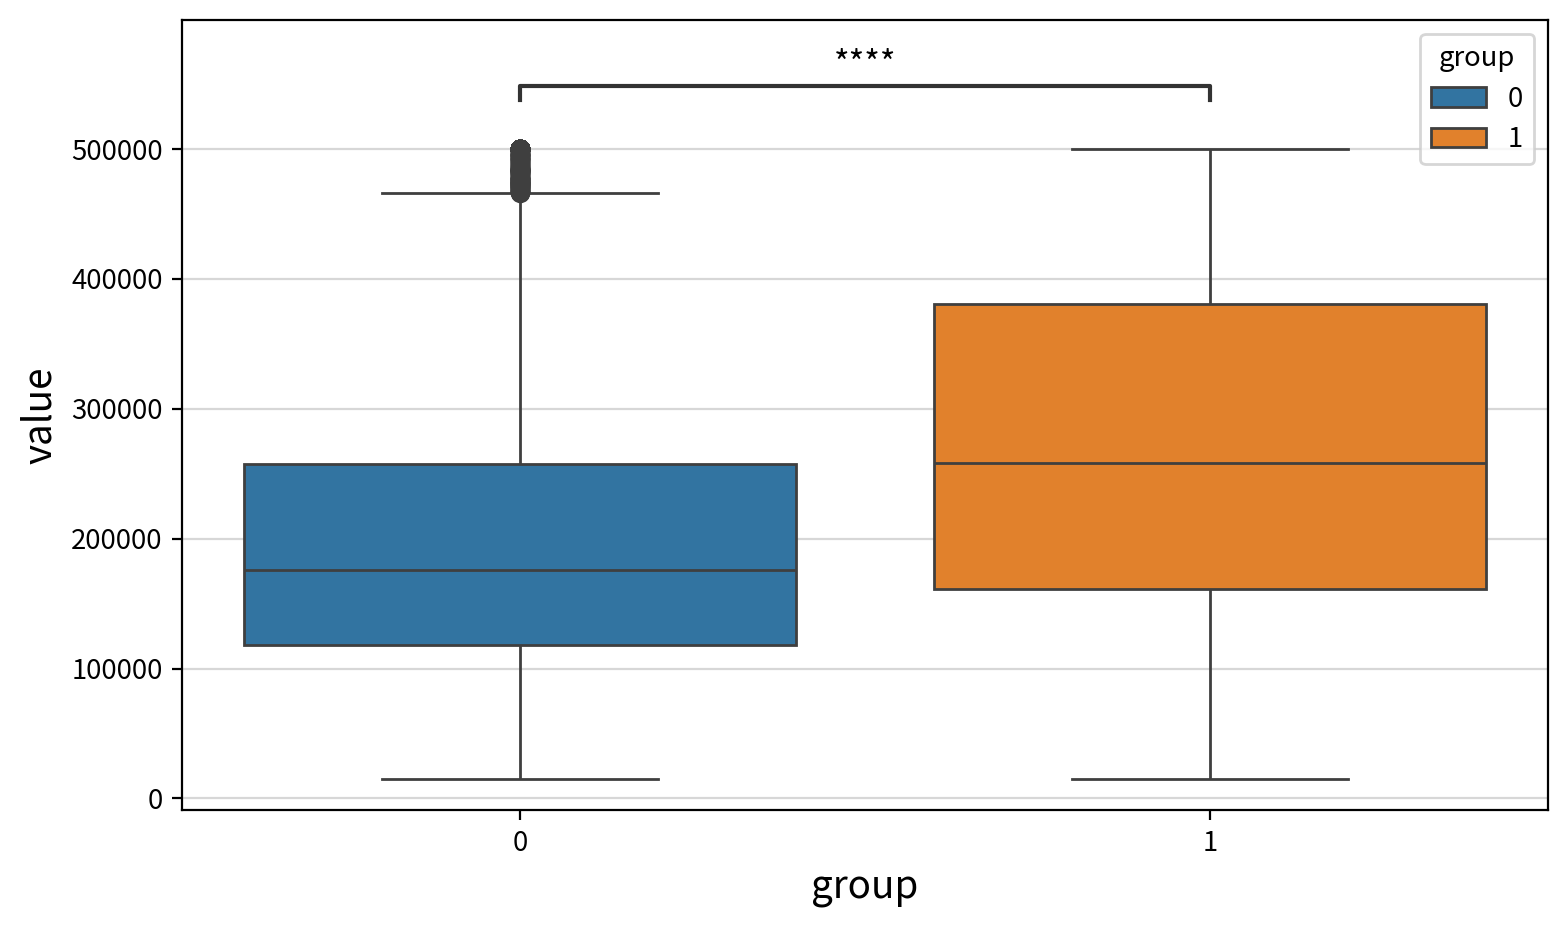

statistic  p-value  significant  result
test                alternative                                          
Mann-Whitney U test two-sided   8383512.000    0.000         True  0 != 1
                    less        8383512.000    0.000         True   0 < 1
                    greater     8383512.000    1.000        False  0 <= 1

#### ▶︎ is_income_capped(소득 상한 절단 여부) → median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.829e-29 U_stat=4.007e+04


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


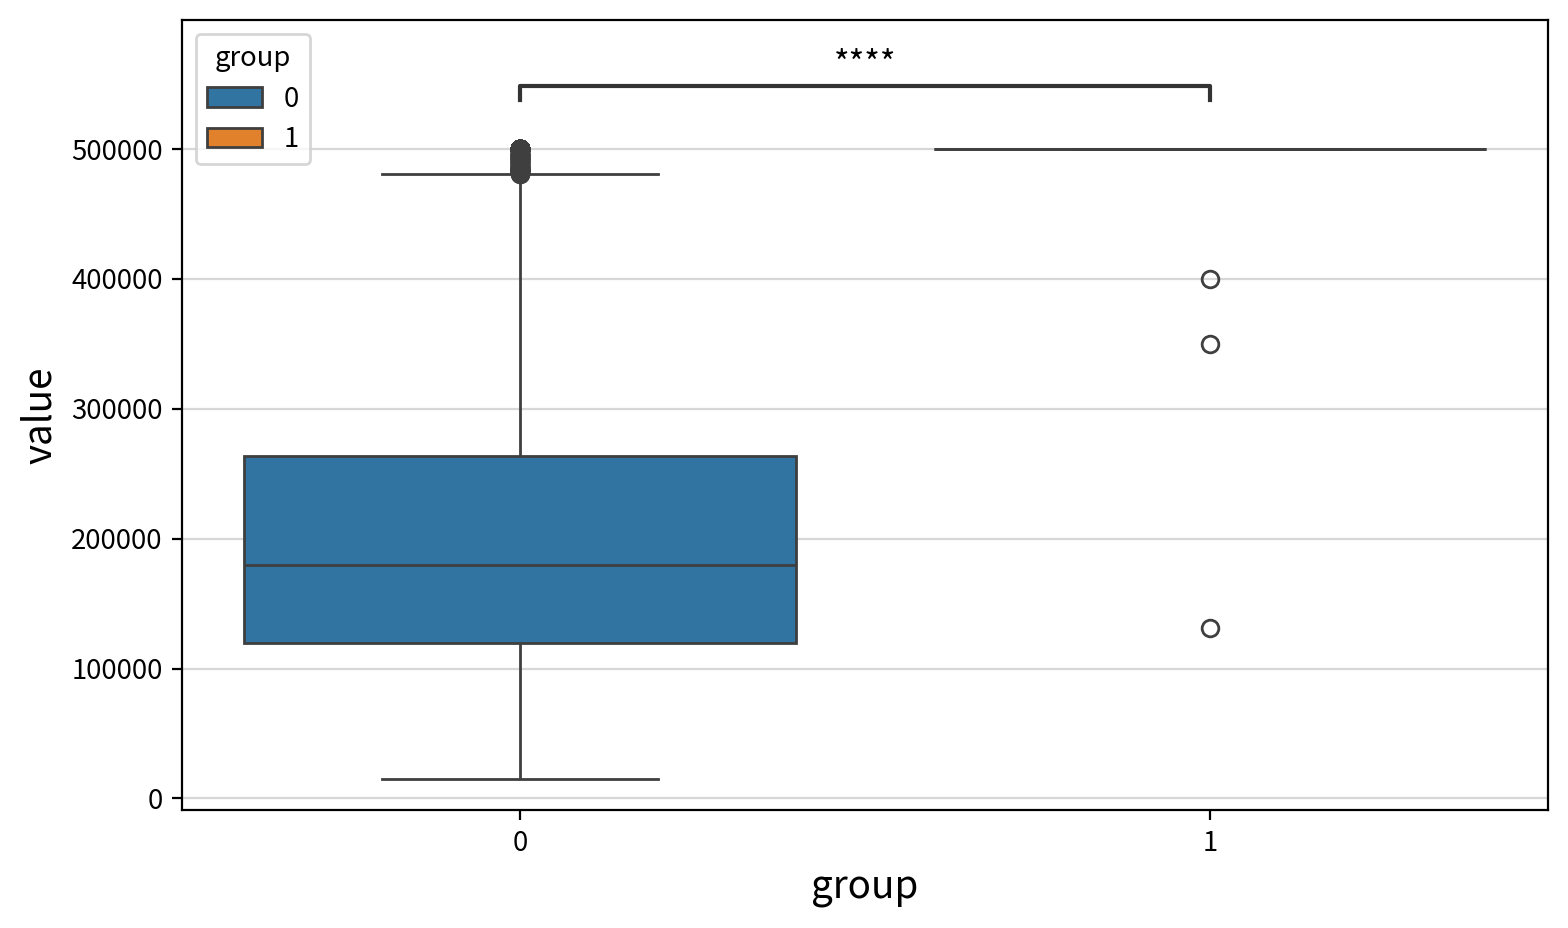

statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided    40072.000    0.000         True  0 != 1
                    less         40072.000    0.000         True   0 < 1
                    greater      40072.000    1.000        False  0 <= 1

#### ▶︎ ocean_area(내륙/해안권 구분) → median_house_value

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

COASTAL vs. INLAND: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=7.704e+07


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


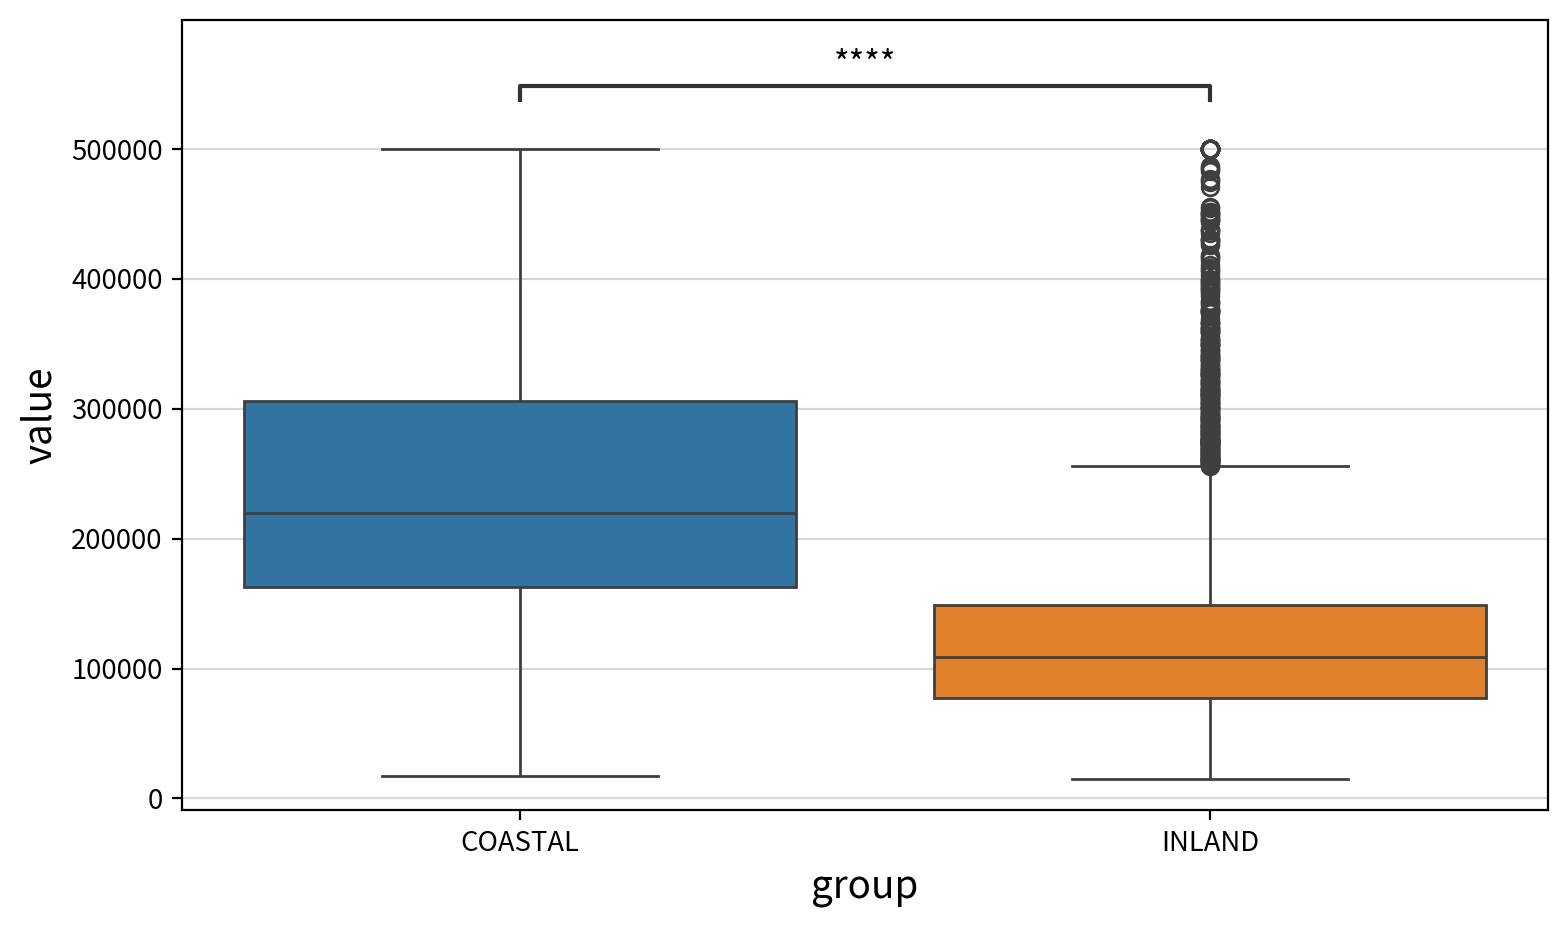

statistic  p-value  significant  \
test                alternative                                      
Mann-Whitney U test two-sided   77038278.500    0.000         True   
                    less        77038278.500    1.000        False   
                    greater     77038278.500    0.000         True   

                                            result  
test                alternative                     
Mann-Whitney U test two-sided    COASTAL != INLAND  
                    less         COASTAL >= INLAND  
                    greater       COASTAL > INLAND

In [26]:
for n in derived_nominal:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                    group1=wide_df.columns[0], group2=wide_df.columns[1],
                    width=800, height=480))

##### 인사이트

| 변수 | 집단 1 평균 | 집단 0 평균 | 차이 | 검정 결과 | 채택 여부 |
|---|---|---|---|---|---|
| `ocean_area` | COASTAL 245,069\$ | INLAND 124,897\$ | 120,172\$ | 유의 (p<0.001) | 채택 |
| `is_age_capped` | 275,393\$ | 202,342\$ | 73,051\$ | 유의 (p<0.001) | 채택 |
| `is_income_capped` | 487,627\$ | 206,176\$ | 281,451\$ | 유의 (p<0.001) | 보류 |

- **`ocean_area`는 병합 후에도 EDA 수준의 설명력을 유지한다.** EDA에서 5범주 `ocean_proximity`의 `INLAND` 평균은 124,897\$였고, 병합된 해안권 3종의 평균은 240,268\~259,279\$였다. 하나로 묶은 COASTAL의 평균 245,069\$가 그 범위 안에 들어온다. 범주를 5개에서 2개로 줄였지만 잃은 것이 거의 없다는 뜻이다.
- **`is_age_capped`는 주택 연령 자체와 다른 정보를 담는다.** EDA에서 `housing_median_age`의 상관은 ρ=+0.075로 거의 없었지만, "52년으로 잘릴 만큼 오래된 동네"라는 표시는 7만\$ 이상의 차이를 만든다. 연속형으로는 잡히지 않던 신호이며, 오래 자리 잡은 도심 지역이 여기에 해당한다.
- **`is_income_capped`는 차이가 가장 크지만 채택을 보류한다.** 평균 차이 28만\$에 중앙값이 500,001\$로 종속변수 상한과 겹친다. 문제는 n=50(0.2%)이라는 점이다. 차이의 크기가 아니라 **그 차이를 50건으로 추정했다는 사실**이 위험하다. EDA에서 `ISLAND` 5건을 해석에 쓰지 않기로 한 것과 같은 이유다.
- 검정된 것은 2집단 변수 셋뿐이다. `special_cluster`(5범주)는 조건에 걸려 건너뛰었고 `#04-7`에서 다룬다. 종속변수의 500,001\$ 절단 구간은 `#02-4`에서 플래그를 만들지 않았으므로 애초에 목록에 없다.

#### 8. ANOVA (x: 3집단 이상 범주형 파생변수 → y: 종속변수)

앞에서 만든 공간정보 `special_cluster`가 대상이다.

In [27]:
for n in derived_nominal:
    # 3개 이상의 고유값이 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 분산분석
        display(my_stats.anova_oneway(df, y=target, between=n))

        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶︎ special_cluster(위경도 기반 공간 군집) → median_house_value

c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,special_cluster,4,5508.155,2299.156,0.000,0.126,Medium


c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index=df.groupby(hue).cumcount(),
c:\Users\jh\취준_데이터분석_0901\kaggle프로젝트\California Housing 주택가격 예측\notebooks\helpers\my_prep.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pivot_table(data=df,


비교한 조합 쌍: 10개
유의한 쌍: 10개
평균 차이가 가장 큰 쌍: (0) vs (1) -> 차이 136984.354, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (0) vs (1)-> 차이 136984.354, 효과크기 Large, p-value 0.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,0,1,93638.609,230622.962,-136984.354,1643.444,-83.352,3961.218,0.000,-1.277,True,Large
1,Games-Howell,0,2,93638.609,224715.951,-131077.342,1802.992,-72.700,4815.611,0.000,-1.201,True,Large
2,Games-Howell,0,3,93638.609,177071.846,-83433.237,2347.525,-35.541,3095.476,0.000,-1.004,True,Large
3,Games-Howell,0,4,93638.609,121984.265,-28345.656,2429.515,-11.667,2529.102,0.000,-0.373,True,Small
4,Games-Howell,1,2,230622.962,224715.951,5907.012,1857.209,3.181,14257.849,0.013,0.052,True,Negligible
5,Games-Howell,1,3,230622.962,177071.846,53551.117,2389.418,22.412,3857.101,0.000,0.489,True,Small
6,Games-Howell,1,4,230622.962,121984.265,108638.697,2470.018,43.983,2998.000,0.000,0.995,True,Large
7,Games-Howell,2,3,224715.951,177071.846,47644.105,2501.838,19.044,4450.040,0.000,0.427,True,Small
8,Games-Howell,2,4,224715.951,121984.265,102731.686,2578.926,39.835,3464.306,0.000,0.923,True,Large
9,Games-Howell,3,4,177071.846,121984.265,55087.581,2985.122,18.454,3895.262,0.000,0.584,True,Medium


##### 인사이트

| 군집 | 건수 | 평균 집값 | 중심 좌표 | 해당 권역 |
|---|---|---|---|---|
| 1 | 8,729 | 230,623\$ | (34.01, −118.13) | 남부 (LA 권역) |
| 2 | 6,736 | 224,716\$ | (37.85, −121.87) | 중북부 (베이 권역) |
| 3 | 2,211 | 177,072\$ | (33.09, −116.95) | 최남부 (샌디에이고 권역) |
| 4 | 1,778 | 121,984\$ | (36.00, −119.70) | 중부 내륙 (센트럴밸리) |
| 0 | 979 | 93,639\$ | (39.93, −122.32) | 북부 내륙 |

- **유의하며 효과크기도 충분하다.** Welch F=2,299.2 (p<0.001), np2=**0.126(Medium)**. 좌표 두 개만 가지고 만든 단일 변수가 집값 분산의 12.6%를 설명한다.
- **10쌍이 모두 유의하다.** 5개 군집이 서로 다른 가격대를 형성하고 있다는 뜻이다. 최저인 군집 0(북부 내륙, 93,639\$)과 최고인 군집 1(LA 권역, 230,623\$)의 격차는 13.7만\$, hedges 1.277(Large)다.
- **`#03`의 Moran's I(0.790)가 실체를 가졌다.** "인접한 주택끼리 가격이 비슷하다"는 진단이 5개의 구체적인 시장 권역으로 번역됐고, 그 권역 구분이 통계적으로 확인됐다.

#### 9. 연속형 파생변수 간 상관 분석

재료가 같은 변수끼리는 겹칠 수밖에 없다. 어느 정도인지 확인해 둔다.

In [28]:
corr = my_stats.multi_correlation(df, columns=derived_continuous, plot=False)
my_stats.correlation_summary(corr)

,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person
rooms_per_person,1.000,0.662,-0.542,-0.675,0.737
rooms_per_household,0.662,1.000,-0.888,0.018,0.536
bedrooms_per_room,-0.542,-0.888,1.000,-0.080,-0.599
population_per_household,-0.675,0.018,-0.080,1.000,-0.469
income_per_person,0.737,0.536,-0.599,-0.469,1.000


,max-y,max-coef,count,columns
x,,,,
bedrooms_per_room,rooms_per_household,-0.888,1,rooms_per_household
rooms_per_household,bedrooms_per_room,-0.888,1,bedrooms_per_room
income_per_person,rooms_per_person,0.737,1,rooms_per_person
rooms_per_person,income_per_person,0.737,1,income_per_person
population_per_household,rooms_per_person,-0.675,0,-


##### 인사이트

- **EDA의 총량 4종(상호 ρ≥0.90)보다는 나아졌지만 중복이 사라진 것은 아니다.** 5종을 만들었어도 재료는 여전히 5개 원본 변수이므로, 어느 조합이든 분자나 분모를 공유한다.

#### ✅ 종합 판단

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| 채택 | `income_per_person` | Spearman | $< 0.05$ | ρ=+0.722 (Strong) | 우편향(+1.46) / log 변환 | O (`rooms_per_person` 0.737) | 데이터셋 유일의 Strong. EDA 최강이던 `median_income`(+0.677)도 상회하므로 1순위 |
| 채택 | `ocean_area` | Mann-Whitney U | $< 0.05$ | 평균차 120,172\$ | 해당 없음 | X | 5범주를 2범주로 줄이고도 EDA 수준의 집단 격차 유지 |
| 채택 | `rooms_per_person` | Spearman | $< 0.05$ | ρ=+0.400 (Moderate) | 극단 우편향(+17.76) / log 변환 | O (`income_per_person` 0.737) | 규모 축 대표. 원본 `total_rooms`(+0.205)의 2배 |
| 채택 | `bedrooms_per_room` | Spearman | $< 0.05$ | ρ=−0.332 (Moderate) | 우편향(+2.25) / log 변환 | O (`rooms_per_household` −0.888) | 파생 중 분포가 가장 안정. 총량으로는 못 보던 음의 관계 |
| 후보 | `is_age_capped` | Mann-Whitney U | $< 0.05$ | 평균차 73,051\$ | 해당 없음 | 미점검 | `housing_median_age`(ρ=+0.075)가 못 잡던 신호. 6.2%로 검정에 충분 |
| 채택 | `special_cluster` | Welch ANOVA | $< 0.05$ | np2=0.126 (Medium) → 통제 후 **0.162 (Large)** | 해당 없음 | △ (`ocean_area` V=0.411, 보완 관계) | `ocean_area` 통제 후에도 Large를 유지하고 교호작용까지 유의(`#04-9`). 내륙 내부를 np2=0.170(Large)으로 갈라내 `ocean_area`가 못 하던 구분을 담당 |
| 후보 | `rooms_per_household` | Spearman | $< 0.05$ | ρ=+0.263 (Weak) | 극단 우편향(+20.68) / log 변환 | O (`bedrooms_per_room` −0.888) | `bedrooms_per_room`과 중복이 심해 둘 중 하나만. VIF로 판정 |
| 후보 | `population_per_household` | Spearman | $< 0.05$ | ρ=−0.256 (Weak) | 최악(+97.16) / log 변환 | O (`rooms_per_person` −0.675) | 설명력 최약이면서 분포도 최악. 우선 제거 후보 |
| 보류 | `is_income_capped` | Mann-Whitney U | $< 0.05$ | 평균차 281,451\$ | 해당 없음 | 미점검 | 차이는 크지만 n=50(0.2%). 추정 안정성이 낮아 투입 여부 재판단 필요 |

### #07. 파생변수 데이터셋 저장

#### 1. 투입 변수 정리

In [29]:
# 모형에 투입할 변수 (원본 1종 + 연속형 파생 5종 + 범주형 파생 4종)
feature_cols = [
    "housing_median_age",         # 유지된 원본
    "rooms_per_person",           # 연속형 파생변수
    "rooms_per_household",        # 연속형 파생변수
    "bedrooms_per_room",          # 연속형 파생변수
    "population_per_household",   # 연속형 파생변수
    "income_per_person",          # 연속형 파생변수
    "is_age_capped",              # 범주형 파생
    "is_income_capped",           # 범주형 파생
    "ocean_area",                 # 범주형 파생
    "special_cluster",            # 공간정보
]

print("투입 변수 :", len(feature_cols), "종\n")
print("투입 변수 목록 :", feature_cols)

투입 변수 : 10 종

투입 변수 목록 : ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']


#### 2. 파생변수 데이터셋 저장

로그 변환·라벨링을 적용하기 전, 원 단위 그대로의 상태를 먼저 남긴다.


In [30]:
# 저장 대상 = 투입 변수 + 종속변수
save_cols = feature_cols + [target]
print(save_cols)

# 변환할 변수만 추출
df_derived = df[save_cols]

# 범주형 변수 타입 변환
df_derived = my_qtcheck.set_type(df_derived, as_category=["is_age_capped", "is_income_capped", "ocean_area", "special_cluster"])

# 저장
df_derived.to_excel("california_housing_features.xlsx", index=False)
print("저장 완료 :", df_derived.shape)

['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster', 'median_house_value']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   housing_median_age        20433 non-null  int64   
 1   rooms_per_person          20433 non-null  float64 
 2   rooms_per_household       20433 non-null  float64 
 3   bedrooms_per_room         20433 non-null  float64 
 4   population_per_household  20433 non-null  float64 
 5   income_per_person         20433 non-null  float64 
 6   is_age_capped             20433 non-null  category
 7   is_income_capped          20433 non-null  category
 8   ocean_area                20433 non-null  category
 9   special_cluster           20433 non-null  

### #08. 로그 변환 및 데이터 라벨링

#### 1. 변환 대상 확인

- 기술통계량 표에서 로그 변환 필요성 여부만 확인한다.

In [31]:
feature_desc = my_qtcheck.numerical_summary(df_derived)
feature_desc['log_need'].T

housing_median_age          none
rooms_per_person             log
rooms_per_household          log
bedrooms_per_room            log
population_per_household     log
income_per_person            log
median_house_value           log
Name: log_need, dtype: object

#### 2. 로그 변환 대상 추출

In [32]:
# log_need 판정에 따라 변환 대상을 분류한다.
log_cols = feature_desc[feature_desc["log_need"] == "log"].index.tolist()
log1p_cols = feature_desc[feature_desc["log_need"] == "log1p"].index.tolist()
reflect_cols = feature_desc[feature_desc["log_need"] == "reverse_log1p"].index.tolist()

print("log(x)      :", log_cols)
print("log(1+x)    :", log1p_cols)
print("반사 후 log :", reflect_cols)

log(x)      : ['rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person', 'median_house_value']
log(1+x)    : []
반사 후 log : []


#### 3. 독립변수 및 종속변수 로그 변환

In [33]:
# 앞에서 확정한 투입 변수만 변환한다.
df_log = my_prep.log_transform(df_derived,
            log_columns=log_cols,
            log1p_columns=log1p_cols,
            reflect_columns=reflect_cols)


컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
rooms_per_person우측 꼬리     log(x)                exp(y)                  17.76 -> -0.73
rooms_per_household우측 꼬리     log(x)                exp(y)                   20.68 -> 0.88
bedrooms_per_room우측 꼬리     log(x)                exp(y)                    2.25 -> 0.54
population_per_household우측 꼬리     log(x)                exp(y)                   97.15 -> 2.14
income_per_person우측 꼬리     log(x)                exp(y)                   1.46 -> -0.55
median_house_value우측 꼬리     log(x)                exp(y)                   0.98 -> -0.17


#### 4. 범주형 라벨링

In [34]:
# 라벨링 대상 : category 타입인 범주형 파생변수
# -> 절단 플래그 2종은 이미 0/1 정수이므로 대상이 아니다.
label_cols = ["ocean_area", "special_cluster"]

df_label = my_prep.labeling(df_log, columns=label_cols)

df_label[label_cols].head()

ocean_area (2종): COASTAL=0,INLAND=1
special_cluster (5종): 0=0,1=1,2=2,3=3,4=4


,ocean_area,special_cluster
0,0,2
1,0,2
2,0,2
3,0,2
4,0,2


#### 5. 최종 데이터셋 저장

In [35]:
df_label.to_excel("california_housing_features.xlsx", index=False)

print("저장 완료 :", df_label.shape)
df_label.head()

저장 완료 : (20433, 11)


,housing_median_age,rooms_per_person,rooms_per_household,bedrooms_per_room,population_per_household,income_per_person,is_age_capped,is_income_capped,ocean_area,special_cluster,median_house_value
0,41,1.005,1.944,-1.920,0.938,1.181,0,0,0,2,13.023
1,21,1.084,1.831,-1.859,0.747,1.370,0,0,0,2,12.790
2,52,1.084,2.115,-2.044,1.030,0.952,1,0,0,2,12.772
3,52,0.826,1.761,-1.690,0.935,0.795,1,0,0,2,12.741
4,52,1.058,1.838,-1.760,0.780,0.567,1,0,0,2,12.743


<a id="stage-04"></a>

## #4. 회귀모델링과 하이퍼파라미터 튜닝

> 선형·비선형·트리·앙상블 회귀모형을 동일한 분할 기준으로 비교하고 튜닝 모델을 선정합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | 로그 변환과 라벨링이 완료된 모델 입력 데이터 |
| 핵심 작업 | 11개 회귀모형 학습·비교, GridSearchCV 기반 튜닝 |
| 산출물 | `ml_models/<실행시각>` 및 `<실행시각>_tuned` 모델 |

**분석 목차:** [01. 분석 개요와 데이터 품질 점검](#stage-01) · [02. 탐색적 데이터 분석 (EDA)](#stage-02) · [03. 분석용 데이터 전처리](#stage-03) · [04. 회귀모델링과 하이퍼파라미터 튜닝](#stage-04) · [05. 최종모델 진단과 결과 해석](#stage-05)

---

### #01. 준비작업

#### 1. 패키지 설치


In [1]:
!pip install --upgrade xgboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install --upgrade lightgbm


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install --upgrade catboost


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 2. 기본 라이브러리 참조

In [4]:
from jussam import load_data
from helpers import *
import datetime as dt
import os
import glob as gl   # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈

# 훈련,검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


#### 3. 머신러닝 학습 모델 라이브러리 참조

In [5]:
# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

#### 4. 데이터 불러오기

- 파생변수를 포함한 최종 변수 채택 후 로그 변환과 라벨링이 완료된 데이터

In [6]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = load_data("california_housing_feature_log_labelled")
df = my_qtcheck.set_type(origin, as_category=["is_age_capped", "is_income_capped", "ocean_area", "special_cluster"])

📚 캘리포니아 주택 가격 데이터셋의 파생변수 추가 버전에 대한 로그 변환 및 라벨링 처리 데이터 (출처: 자체 작업)

    field                     description
--  ------------------------  -------------------------------------------------
 0  housing_median_age        주택 중위 연령 (로그변환됨)
 1  rooms_per_person          인당 방 수 (로그변환됨)
 2  rooms_per_household       가구당 방 수 (로그변환됨)
 3  bedrooms_per_room         방당 침실 수 (로그변환됨)
 4  population_per_household  가구당 인구 (로그변환됨)
 5  income_per_person         인당 소득 (로그변환됨)
 6  is_age_capped             주택 연령 제한 여부(범주형: 제한안함=0, 제한함=1)
 7  is_income_capped          소득 제한 여부(범주형: 제한안함=0, 제한함=1)
 8  ocean_area                해양 지역 여부(범주형: COASTAL=0, INLAND=1)
 9  special_cluster           공간정보 클러스터 여부(범주형 0~4)
10  median_house_value        주택 중위 가격(종속변수, 로그변환됨)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   housing_median_age   

#### 5. 데이터에서 독립변수와 종속변수 분리

- 머신러닝에서는 독립변수를 feature, 종속변수를 target으로 명명한다.

In [7]:
feature = df.drop(columns=["median_house_value"])
target = df["median_house_value"]
feature.shape, target.shape

((20433, 10), (20433,))

#### 6. 훈련, 검증 데이터 분리

In [8]:
# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16346, 10), (4087, 10), (16346,), (4087,))

#### 7. 학습을 완료한 모델이 저장될 폴더

In [9]:
timestemp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
workdir = f"ml_models/{timestemp}"

if not os.path.exists(workdir):
    os.makedirs(workdir)

### #02. 선형계열 모델

#### 1. LinearRegressor

In [10]:
# 파이프라인 구축 -> 학습 -> 저장
linear = my_ml.fit_pipeline(
                model=LinearRegression(),  # <-- LinearRegressor 학습 모델
                x_train=x_train, y_train=y_train, 
                vif=True, 
                scale=False, 
                drop_first=True,
                save_path=f"{workdir}/linear.pkl")

linear

대상: 16346행 x 10열 | 모델: linear
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: linear
모델 저장: ml_models/20260902_114312/linear.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 2. Ridge

In [11]:
# 파이프라인 구축 -> 학습 -> 저장
ridge = my_ml.fit_pipeline(
                model=Ridge(random_state=RANDOM_STATE),
                x_train=x_train, y_train=y_train,
                vif=True, 
                scale=True, 
                drop_first=True,
                save_path=f"{workdir}/ridge.pkl")

ridge

대상: 16346행 x 10열 | 모델: ridge
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: ridge
모델 저장: ml_models/20260902_114312/ridge.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 3. Lasso

In [12]:
lasso = my_ml.fit_pipeline(
                model=Lasso(random_state=RANDOM_STATE),
                x_train=x_train, y_train=y_train,
                vif=True, 
                scale=True, 
                drop_first=True,
                save_path=f"{workdir}/lasso.pkl")
lasso

대상: 16346행 x 10열 | 모델: lasso
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: lasso
모델 저장: ml_models/20260902_114312/lasso.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 4. ElasticNet

In [13]:
elasticnet = my_ml.fit_pipeline(
                model=ElasticNet(random_state=RANDOM_STATE),
                x_train=x_train, y_train=y_train,
                vif=True, 
                scale=True, 
                drop_first=True,
                save_path=f"{workdir}/elasticnet.pkl")
elasticnet

대상: 16346행 x 10열 | 모델: elasticnet
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: elasticnet
모델 저장: ml_models/20260902_114312/elasticnet.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### #03. 비선형 계열 모델

#### 1. KNN

In [14]:
knn = my_ml.fit_pipeline(
                model=KNeighborsRegressor(n_jobs=-1),
                x_train=x_train, y_train=y_train,
                vif=True, 
                scale=True, 
                drop_first=True,
                save_path=f"{workdir}/knn.pkl")

knn

대상: 16346행 x 10열 | 모델: kneighbors
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: kneighbors
모델 저장: ml_models/20260902_114312/knn.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 2. Support Vector Regressor

In [15]:
svr = my_ml.fit_pipeline(
                model=SVR(),
                x_train=x_train, y_train=y_train,
                vif=True,
                scale=True, 
                drop_first=True,
                save_path=f"{workdir}/svr.pkl")
svr

대상: 16346행 x 10열 | 모델: svr
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0) → 정규화(standard)
  명목형: 더미변수 인코딩(drop_first=True)

모델 학습 완료: svr
모델 저장: ml_models/20260902_114312/svr.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### #04. 트리 계열 모델

#### 1. Decision Tree

In [16]:
dtree = my_ml.fit_pipeline(
                model=DecisionTreeRegressor(random_state=RANDOM_STATE),
                x_train=x_train, y_train=y_train,
                vif=True, 
                encode=True, 
                save_path=f"{workdir}/dtree.pkl")
dtree

대상: 16346행 x 10열 | 모델: decisiontree
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: decisiontree
모델 저장: ml_models/20260902_114312/dtree.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### #05. 앙상블 모델

#### 1. Random Forest

In [17]:
rf = my_ml.fit_pipeline(
                model=RandomForestRegressor(
                    random_state=RANDOM_STATE, n_jobs=-1),
                x_train=x_train, y_train=y_train,
                vif=True, 
                encode=True, 
                save_path=f"{workdir}/rf.pkl")
rf

대상: 16346행 x 10열 | 모델: randomforest
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: randomforest
모델 저장: ml_models/20260902_114312/rf.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 2. XGBoost

In [18]:
xgb = my_ml.fit_pipeline(
            model=XGBRegressor(
                random_state=RANDOM_STATE, n_jobs=-1),
            x_train=x_train, y_train=y_train,
            vif=True, 
            encode=True, 
            save_path=f"{workdir}/xgb.pkl")
xgb

대상: 16346행 x 10열 | 모델: xgb
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: xgb
모델 저장: ml_models/20260902_114312/xgb.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 3.  LightGBM

In [19]:
lgbm = my_ml.fit_pipeline(
            model=LGBMRegressor(
                    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
            x_train=x_train, y_train=y_train,
            vif=True, 
            encode=True, 
            save_path=f"{workdir}/lgbm.pkl")
lgbm

대상: 16346행 x 10열 | 모델: lgbm
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: 더미변수 인코딩(drop_first=False)

모델 학습 완료: lgbm
모델 저장: ml_models/20260902_114312/lgbm.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 4. CatBoost

In [20]:
catboost = my_ml.fit_pipeline(
            model=CatBoostRegressor(
                    random_state=RANDOM_STATE, verbose=0),
            x_train=x_train, y_train=y_train,
            vif=True, 
            encode=False,   # CatBoost는 자체적으로 범주형 처리하므로 encode=False
            save_path=f"{workdir}/catboost.pkl",
            # 이름이 `단계명__인자명` 형식인 인자는 모델의 fit 으로 그대로 전달된다
            model__cat_features=my_qtcheck.get_categorical_column_names(x_train))
catboost

대상: 16346행 x 10열 | 모델: catboost
명목형: ['is_age_capped', 'is_income_capped', 'ocean_area', 'special_cluster']
연속형: ['housing_median_age', 'rooms_per_person', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_per_person']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: (변환 없음)

모델 학습 완료: catboost
모델 저장: ml_models/20260902_114312/catboost.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

### #06. 최고 성능 모델 선정

#### 1. 학습 모델 파일 목록

In [21]:
# 작업폴더 내의 모든 pkl 파일 목록 확인
model_pickles = gl.glob(f"{workdir}/*.pkl")
print(model_pickles)

['ml_models/20260902_114312\\catboost.pkl', 'ml_models/20260902_114312\\dtree.pkl', 'ml_models/20260902_114312\\elasticnet.pkl', 'ml_models/20260902_114312\\knn.pkl', 'ml_models/20260902_114312\\lasso.pkl', 'ml_models/20260902_114312\\lgbm.pkl', 'ml_models/20260902_114312\\linear.pkl', 'ml_models/20260902_114312\\rf.pkl', 'ml_models/20260902_114312\\ridge.pkl', 'ml_models/20260902_114312\\svr.pkl', 'ml_models/20260902_114312\\xgb.pkl']


#### 2. 학습 모델 불러오기

In [22]:
models = {}                         # 모델명과 모델 객체를 저장할 딕셔너리

for p in model_pickles:
    model_name = p.split(".")[0]    # 파일 목록에서 파일명만 분리
    model = my_ml.load_model(p)     # 모델 로드
    models[model.name_] = model     # 모델명과 모델 객체를 딕셔너리에 저장

# 로드된 모델과 모델 객체의 타입 출력
for name, model in models.items():
    print(f"- {name}: {type(model)}")

- catboost: <class 'sklearn.pipeline.Pipeline'>
- decisiontree: <class 'sklearn.pipeline.Pipeline'>
- elasticnet: <class 'sklearn.pipeline.Pipeline'>
- kneighbors: <class 'sklearn.pipeline.Pipeline'>
- lasso: <class 'sklearn.pipeline.Pipeline'>
- lgbm: <class 'sklearn.pipeline.Pipeline'>
- linear: <class 'sklearn.pipeline.Pipeline'>
- randomforest: <class 'sklearn.pipeline.Pipeline'>
- ridge: <class 'sklearn.pipeline.Pipeline'>
- svr: <class 'sklearn.pipeline.Pipeline'>
- xgb: <class 'sklearn.pipeline.Pipeline'>


#### 3. 특정 모델의 성능지표 확인

In [24]:
my_ml.reg_score(models['catboost'], x_test, y_test)

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.781,0.196,0.072,0.269,0.021,0.016,-0.000


#### 4. 모델간 성능평가 비교

In [25]:
my_ml.reg_compare_models(models,               # 모델 객체들을 담은 딕셔너리
                         x_test,               # 검증 데이터의 독립 변수
                         y_test,               # 검증 데이터의 종속 변수
                         primary="RMSE",       # 주 지표
                         aux=["MAE", "R2"])    # 보조 지표


◆ Score Table Ranking : primary='RMSE', aux=['MAE', 'R2']

▲ step1: 주 지표(RMSE) 기준 정렬 — 낮을수록 좋음 (ASC)
    1. svr            RMSE  =            0.266
    2. catboost       RMSE  =            0.269
    3. lgbm           RMSE  =            0.272
    4. randomforest   RMSE  =            0.276
    5. xgb            RMSE  =            0.278
    6. kneighbors     RMSE  =            0.281
    7. linear         RMSE  =            0.307
    8. ridge          RMSE  =            0.307
    9. decisiontree   RMSE  =            0.375
   10. elasticnet     RMSE  =            0.574
   11. lasso          RMSE  =            0.574

▲ step2: 근소 격차 그룹 묶기 (1등의 5% 이내)
   - 1등 RMSE   : 0.266
   - 허용 범위    : RMSE ≤ 0.280
   - 근소 격차 그룹 (5) : ['svr', 'catboost', 'lgbm', 'randomforest', 'xgb']
   - 그룹 외부     (6) : ['kneighbors', 'linear', 'ridge', 'decisiontree', 'elasticnet', 'lasso']

▲ step3: 보조 지표 결정적 결함 점검 (근소 격차 그룹 내부)
   - 그룹 1등 점수 / 결함 임계치:
       · MAE    best=     0.191   결함조건: row > 0.210  (1등 × 1.10)
 

,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap
name,,,,,,,,,,,
svr,1,Contender,SVR,0.784,0.191,0.071,0.266,0.021,0.016,0.000,0.000
catboost,2,Contender,CatBoostRegressor,0.781,0.196,0.072,0.269,0.021,0.016,-0.000,0.008
lgbm,3,Contender,LGBMRegressor,0.775,0.199,0.074,0.272,0.021,0.017,-0.001,0.021
randomforest,4,Contender,RandomForestRegressor,0.768,0.201,0.076,0.276,0.021,0.017,-0.000,0.037
xgb,5,Contender,XGBRegressor,0.764,0.201,0.078,0.278,0.021,0.017,-0.000,0.045
kneighbors,6,Outside,KNeighborsRegressor,0.760,0.203,0.079,0.281,0.022,0.017,-0.000,0.055
linear,7,Outside,LinearRegression,0.713,0.233,0.094,0.307,0.024,0.019,-0.001,0.153
ridge,8,Outside,Ridge,0.713,0.233,0.094,0.307,0.024,0.019,-0.001,0.153
decisiontree,9,Outside,DecisionTreeRegressor,0.572,0.272,0.141,0.375,0.029,0.023,0.000,0.408


### #08. 하이퍼파라미터 튜닝

#### 1. LinearRegressor

In [26]:
# 튜닝 결과가 저장될 위치
output_dir = f"{workdir}_tuned"

In [27]:
%%time

# LinearRegression 은 규제 항이 없어 성능을 조절할 하이퍼파라미터가 사실상 없다.
# 아래 두 옵션이 가질 수 있는 값의 전부라, 이 그리드가 곧 전체 탐색 범위다.
# 즉 "튜닝으로 좋아지지 않는 모델"을 확인하는 것이 이 셀의 목적이다.
param_grid = {
    "model__fit_intercept": [True, False],   # 절편 사용 여부
    "model__positive": [True, False]         # 계수를 양수로 제한할지 여부
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/linear.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/linear.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
LinearRegression,0.713,0.233,0.094,0.307,0.024,0.019,-0.001


CPU times: total: 234 ms
Wall time: 2.74 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__fit_intercept': [True, False], 'model__positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

#### 2. Ridge

In [28]:
%%time

# [실제 탐색용] 20개 조합
# param_grid = {
#     "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
#     "model__solver": ["auto", "svd", "cholesky", "lsqr"]
# }

# [수업용] 8개 조합. alpha 가 클수록 계수를 0 쪽으로 강하게 눌러 분산을 줄인다.
param_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 100.0],   # 규제 강도
    "model__solver": ["auto", "lsqr"]          # 최적화 알고리즘
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/ridge.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/ridge.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
Ridge,0.713,0.233,0.094,0.307,0.024,0.019,-0.001


CPU times: total: 781 ms
Wall time: 1.69 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.1, 1.0, ...], 'model__solver': ['auto', 'lsqr']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

#### 3. Lasso

In [29]:
%%time

# [실제 탐색용] 15개 조합
# param_grid = {
#     "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
#     "model__max_iter": [1000, 5000, 10000]
# }

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/lasso.pkl")

# [수업용] 8개 조합. 기본값 alpha=1.0 은 이 데이터의 타깃 편차(약 0.57)에 비해 너무 강해
# 모든 계수가 0 이 되어 버린다. 작은 alpha 를 넣어야 모델이 살아난다.
param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1],   # 규제 강도 (L1)
    "model__max_iter": [1000, 5000]               # 좌표하강 반복 횟수
}

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/lasso.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
Lasso,0.713,0.233,0.094,0.307,0.024,0.019,-0.001


CPU times: total: 906 ms
Wall time: 1.83 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...], 'model__max_iter': [1000, 5000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

#### 4. ElasticNet

In [30]:
%%time

# [실제 탐색용] 20개 조합
# param_grid = {
#     "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0],
#     "model__l1_ratio": [0.1, 0.3, 0.5, 0.9]
# }

# [수업용] 8개 조합. l1_ratio 는 L1(Lasso)과 L2(Ridge)의 혼합 비율로,
# 1 에 가까울수록 Lasso, 0 에 가까울수록 Ridge 처럼 동작한다.
param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1],   # 규제 강도
    "model__l1_ratio": [0.2, 0.8]                 # L1 규제의 비중
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/elasticnet.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/elasticnet.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
ElasticNet,0.713,0.233,0.094,0.307,0.024,0.019,-0.001


CPU times: total: 1.03 s
Wall time: 1.84 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...], 'model__l1_ratio': [0.2, 0.8]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

#### 5. KNN

In [31]:
%%time

# [실제 탐색용] 24개 조합
# param_grid = {
#     "model__n_neighbors": [3, 5, 10, 20, 30, 50],
#     "model__weights": ["uniform", "distance"],
#     "model__p": [1, 2]
# }

# [수업용] 8개 조합. 이웃 수가 적으면 과대적합, 많으면 과소적합 쪽으로 기운다.
param_grid = {
    "model__n_neighbors": [5, 10, 20, 30],       # 참조할 이웃 수
    "model__weights": ["uniform", "distance"]    # 거리에 따른 가중 방식
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/knn.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/knn.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
KNeighborsRegressor,0.772,0.198,0.075,0.274,0.021,0.016,-0.000


CPU times: total: 1.83 s
Wall time: 2.99 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(n_jobs=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [5, 10, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

#### 6. Support Vector Machine

In [32]:
%%time

# [실제 탐색용] 27개 조합 --> 표본 수의 제곱에 비례해 학습 시간이 늘어나므로 매우 오래 걸린다
# param_grid = {
#     "model__C": [0.1, 1.0, 10.0],
#     "model__gamma": ["scale", 0.01, 0.1],
#     "model__epsilon": [0.05, 0.1, 0.2]
# }

# [수업용] SVR 은 이 노트북에서 가장 느린 모델이므로 튜닝 시간을 줄이기 위해 조합을 3개로 축소한다.
param_grid = {
    "model__C": [1.0],           # 오차 허용에 대한 벌점 (클수록 훈련 데이터에 밀착)
    "model__gamma": [0.01],      # RBF 커널의 영향 반경
    "model__epsilon": [0.1]      # 오차를 무시하는 epsilon-tube 폭 (클수록 더 많은 오차를 허용)
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/svr.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/svr.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs


,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
SVR,0.753,0.209,0.081,0.285,0.022,0.017,0.000


CPU times: total: 8.16 s
Wall time: 16.4 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [1.0], 'model__epsilon': [0.1], 'model__gamma': [0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

#### 7. Decision Tree

In [33]:
%%time

# [실제 탐색용] 24개 조합
# param_grid = {
#     "model__max_depth": [4, 6, 10, 14, 20, None],
#     "model__min_samples_leaf": [1, 5, 10, 20]
# }

# [수업용] 8개 조합. 기본값(max_depth=None)은 잎이 순수해질 때까지 쪼개
# 훈련 R2 가 1.0 이 되는 전형적인 과대적합 상태다. 깊이를 제한해 이를 완화한다.
param_grid = {
    "model__max_depth": [6, 10, 14, None],   # 트리의 최대 깊이
    "model__min_samples_leaf": [1, 10]       # 잎 노드가 가져야 할 최소 표본 수
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/dtree.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/dtree.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
DecisionTreeRegressor,0.742,0.213,0.085,0.291,0.022,0.018,-0.000


CPU times: total: 641 ms
Wall time: 1.58 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [6, 10, ...], 'model__min_samples_leaf': [1, 10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

#### 8. Random Forest

In [34]:
%%time

# [실제 탐색용] 18개 조합
# param_grid = {
#     "model__n_estimators": [100, 300, 500],
#     "model__max_depth": [10, 20, None],
#     "model__min_samples_leaf": [1, 5]
# }

# [수업용] 트리를 n_estimators 개 만큼 학습하므로 조합 하나가 비싸다.
# 4개 조합으로 줄였다 (SVR 과 함께 이 노트북에서 오래 걸리는 축에 속한다).
param_grid = {
    "model__n_estimators": [100, 300],     # 숲을 이루는 트리 개수
    "model__min_samples_leaf": [1, 5]      # 잎 노드가 가져야 할 최소 표본 수
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/rf.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/rf.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
RandomForestRegressor,0.773,0.198,0.075,0.273,0.021,0.016,-0.001


CPU times: total: 30.6 s
Wall time: 29.6 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=3217))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__min_samples_leaf': [1, 5], 'model__n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

#### 9. XGBoost

In [35]:
%%time

# [실제 탐색용] 27개 조합
# param_grid = {
#     "model__n_estimators": [300, 600, 1000],
#     "model__max_depth": [3, 4, 6],
#     "model__learning_rate": [0.03, 0.05, 0.1]
# }

# [수업용] 8개 조합. learning_rate 를 낮추면 n_estimators 를 늘려야 하므로
# 두 값은 짝지어 움직인다는 점을 확인한다.
param_grid = {
    "model__n_estimators": [300, 600],        # 부스팅 라운드 수
    "model__max_depth": [4, 6],               # 트리 깊이
    "model__learning_rate": [0.05, 0.1]       # 각 트리의 반영 비율
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/xgb.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/xgb.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
XGBRegressor,0.775,0.198,0.074,0.272,0.021,0.016,-0.000


CPU times: total: 9.36 s
Wall time: 8.69 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [4, 6], 'model__n_estimators': [300, 600]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

#### 10.  LightGBM

In [36]:
%%time

# [실제 탐색용] 27개 조합
# param_grid = {
#     "model__n_estimators": [300, 600, 1000],
#     "model__num_leaves": [15, 31, 63],
#     "model__learning_rate": [0.03, 0.05, 0.1]
# }

# [수업용] 8개 조합. LightGBM 은 깊이 대신 잎 개수(num_leaves)로 복잡도를 조절한다.
param_grid = {
    "model__n_estimators": [300, 600],        # 부스팅 라운드 수
    "model__num_leaves": [31, 63],            # 트리 하나가 가질 잎 개수
    "model__learning_rate": [0.05, 0.1]       # 각 트리의 반영 비율
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/lgbm.pkl")

gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다. 이 호출이 있어야 best_estimator_ 가 만들어지고,
# 이후 예측·성능비교가 가능해진다.
gs.fit(x_train, y_train)

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/lgbm.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

gs

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
LGBMRegressor,0.778,0.198,0.073,0.270,0.021,0.016,-0.000


CPU times: total: 8.09 s
Wall time: 30.2 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__n_estimators': [300, 600], 'model__num_leaves': [31, 63]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

#### 11. CatBoost

In [37]:
%%time

# [실제 탐색용] 36개 조합 x 5-fold = CatBoost 학습 180회 --> 수십 분 이상 소요
# param_grid = {
#     "model__iterations": [500, 1000, 2000],
#     "model__depth": [4, 6, 8, 10],
#     "model__learning_rate": [0.03, 0.05, 0.1]
# }

# [수업용] 각 하이퍼파라미터를 일부만 두어 조합을 축소한다.
# 수업 시간에 탐색 과정을 직접 돌려보기 위한 것이므로, 실제 분석에서는 위 범위를 쓴다.
param_grid = {
    "model__iterations": [500, 1000],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

# 베이스모델 로드
model = my_ml.load_model(f"{workdir}/catboost.pkl")

# 하이퍼파라미터 탐색을 위한 GridSearchCV 객체를 생성
gs = GridSearchCV(estimator=model, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

# 탐색을 실제로 수행한다.
# CatBoost 는 범주형 컬럼 목록을 fit 시점에 받으므로 여기서도 함께 넘겨야 한다.
gs.fit(x_train, y_train,
       model__cat_features=my_qtcheck.get_categorical_column_names(x_train))

# 튜닝이 완료된 객체에게 모델이름을 부여한다.
gs.name_ = f"{model.name_}_tuned"

# 튜닝이 완료된 모델을 저장한다.
my_ml.save_model(gs, f"{output_dir}/catboost.pkl")

# 성능 평가
display(my_ml.reg_score(gs, x_test, y_test))

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.785,0.194,0.071,0.266,0.020,0.016,-0.000


CPU times: total: 5min 22s
Wall time: 9min 57s


### #09. 최고 성능 모델 선정

#### 1. 학습 모델 파일 목록

In [38]:
# 작업폴더 내의 모든 pkl 파일 목록 확인
model_pickles = gl.glob(f"{output_dir}/*.pkl")
print(model_pickles)

['ml_models/20260902_114312_tuned\\catboost.pkl', 'ml_models/20260902_114312_tuned\\dtree.pkl', 'ml_models/20260902_114312_tuned\\elasticnet.pkl', 'ml_models/20260902_114312_tuned\\knn.pkl', 'ml_models/20260902_114312_tuned\\lasso.pkl', 'ml_models/20260902_114312_tuned\\lgbm.pkl', 'ml_models/20260902_114312_tuned\\linear.pkl', 'ml_models/20260902_114312_tuned\\rf.pkl', 'ml_models/20260902_114312_tuned\\ridge.pkl', 'ml_models/20260902_114312_tuned\\svr.pkl', 'ml_models/20260902_114312_tuned\\xgb.pkl']


#### 2. 학습 모델 불러오기

In [39]:
models = {}

for p in model_pickles:
    # 파일 목록에서 파일명만 분리
    model_name = p.split(".")[0]

    # 모델 로드
    model = my_ml.load_model(p)

    # 모델명과 모델 객체를 딕셔너리에 저장
    models[model.name_] = model

for name, model in models.items():
    print(f"- {name}: {type(model)}")

- catboost_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- decisiontree_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- elasticnet_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- kneighbors_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- lasso_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- lgbm_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- linear_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- randomforest_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- ridge_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- svr_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>
- xgb_tuned: <class 'sklearn.model_selection._search.GridSearchCV'>


#### 3. 모델간 성능평가 비교

In [40]:
my_ml.reg_compare_models(models,               # 모델 객체들을 담은 딕셔너리
                         x_test,               # 검증 데이터의 독립 변수
                         y_test,               # 검증 데이터의 종속 변수
                         primary="RMSE",       # 주 지표
                         aux=["MAE", "R2"])    # 보조 지표


◆ Score Table Ranking : primary='RMSE', aux=['MAE', 'R2']

▲ step1: 주 지표(RMSE) 기준 정렬 — 낮을수록 좋음 (ASC)
    1. catboost_tuned RMSE  =            0.266
    2. lgbm_tuned     RMSE  =            0.270
    3. xgb_tuned      RMSE  =            0.272
    4. randomforest_tuned RMSE  =            0.273
    5. kneighbors_tuned RMSE  =            0.274
    6. svr_tuned      RMSE  =            0.285
    7. decisiontree_tuned RMSE  =            0.291
    8. linear_tuned   RMSE  =            0.307
    9. ridge_tuned    RMSE  =            0.307
   10. elasticnet_tuned RMSE  =            0.307
   11. lasso_tuned    RMSE  =            0.307

▲ step2: 근소 격차 그룹 묶기 (1등의 5% 이내)
   - 1등 RMSE   : 0.266
   - 허용 범위    : RMSE ≤ 0.279
   - 근소 격차 그룹 (5) : ['catboost_tuned', 'lgbm_tuned', 'xgb_tuned', 'randomforest_tuned', 'kneighbors_tuned']
   - 그룹 외부     (6) : ['svr_tuned', 'decisiontree_tuned', 'linear_tuned', 'ridge_tuned', 'elasticnet_tuned', 'lasso_tuned']

▲ step3: 보조 지표 결정적 결함 점검 (근소 격차 그룹 내부)
   - 그룹 1등 점

,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap
name,,,,,,,,,,,
catboost_tuned,1,Contender,CatBoostRegressor,0.785,0.194,0.071,0.266,0.020,0.016,-0.000,0.000
lgbm_tuned,2,Contender,LGBMRegressor,0.778,0.198,0.073,0.270,0.021,0.016,-0.000,0.016
xgb_tuned,3,Contender,XGBRegressor,0.775,0.198,0.074,0.272,0.021,0.016,-0.000,0.023
randomforest_tuned,4,Contender,RandomForestRegressor,0.773,0.198,0.075,0.273,0.021,0.016,-0.001,0.027
kneighbors_tuned,5,Contender,KNeighborsRegressor,0.772,0.198,0.075,0.274,0.021,0.016,-0.000,0.029
svr_tuned,6,Outside,SVR,0.753,0.209,0.081,0.285,0.022,0.017,0.000,0.070
decisiontree_tuned,7,Outside,DecisionTreeRegressor,0.742,0.213,0.085,0.291,0.022,0.018,-0.000,0.096
linear_tuned,8,Outside,LinearRegression,0.713,0.233,0.094,0.307,0.024,0.019,-0.001,0.155
ridge_tuned,9,Outside,Ridge,0.713,0.233,0.094,0.307,0.024,0.019,-0.001,0.155


<a id="stage-05"></a>

## #5. 최종모델 진단과 결과 해석

> 최종 CatBoost 모델의 일반화 성능과 과적합 여부를 점검하고 예측에 중요한 요인을 해석합니다.

| 구분 | 내용 |
|---|---|
| 분석 대상 | 1990년 미국 인구조사 기반 California Housing 데이터 |
| 종속변수 | `median_house_value` — 지역별 주택 중위가격 |
| 입력 | 튜닝된 CatBoost 모델과 검증 데이터 |
| 핵심 작업 | 과적합 진단, Feature Importance, 변수 축소 재학습, SHAP |
| 산출물 | 최종 성능표와 변수 영향 해석 |

**분석 목차:** [01. 분석 개요와 데이터 품질 점검](#stage-01) · [02. 탐색적 데이터 분석 (EDA)](#stage-02) · [03. 분석용 데이터 전처리](#stage-03) · [04. 회귀모델링과 하이퍼파라미터 튜닝](#stage-04) · [05. 최종모델 진단과 결과 해석](#stage-05)

---

### #01. 준비작업

#### 1. 라이브러리 참조


In [1]:
from jussam import load_data
from helpers import *
from sklearn.base import clone
import glob as gl
from sklearn.model_selection import train_test_split
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


In [2]:
# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

#### 2. 데이터 불러오기 + 타입 체크

In [3]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = load_data("california_housing_feature_log_labelled")
df = my_qtcheck.set_type(origin, as_category=["is_age_capped", "is_income_capped", "ocean_area", "special_cluster"])

📚 캘리포니아 주택 가격 데이터셋의 파생변수 추가 버전에 대한 로그 변환 및 라벨링 처리 데이터 (출처: 자체 작업)

    field                     description
--  ------------------------  -------------------------------------------------
 0  housing_median_age        주택 중위 연령 (로그변환됨)
 1  rooms_per_person          인당 방 수 (로그변환됨)
 2  rooms_per_household       가구당 방 수 (로그변환됨)
 3  bedrooms_per_room         방당 침실 수 (로그변환됨)
 4  population_per_household  가구당 인구 (로그변환됨)
 5  income_per_person         인당 소득 (로그변환됨)
 6  is_age_capped             주택 연령 제한 여부(범주형: 제한안함=0, 제한함=1)
 7  is_income_capped          소득 제한 여부(범주형: 제한안함=0, 제한함=1)
 8  ocean_area                해양 지역 여부(범주형: COASTAL=0, INLAND=1)
 9  special_cluster           공간정보 클러스터 여부(범주형 0~4)
10  median_house_value        주택 중위 가격(종속변수, 로그변환됨)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20433 entries, 0 to 20432
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   housing_median_age   

#### 3. 데이터 분할

In [4]:
# 독립변수 분리
feature = df.drop(columns=["median_house_value"])

# 종속변수 분리
target = df["median_house_value"]

# 훈련, 검증 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(
        feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((16346, 10), (4087, 10), (16346,), (4087,))

#### 4. 저장폴더 지정

In [5]:
# 04번 노트북에서 생성된 튜닝 폴더 중 가장 최근 폴더를 사용한다.
tuned_dirs = sorted(gl.glob("ml_models/*_tuned"))
if not tuned_dirs:
    raise FileNotFoundError("먼저 04번 노트북을 실행해 튜닝 모델을 저장하세요.")

workdir = tuned_dirs[-1]
workdir


'ml_models\\20260902_114312_tuned'

In [6]:
# 새로운 학습 결과를 저장할 폴더 위치
savedir = workdir.replace("tuned", "importance")
savedir

'ml_models\\20260902_114312_importance'

### #02. 상위 성능 모델에 대한 과적합 판정

#### 1. CatBoost 

- 모델 학습시 설정한 범주형 변수 지정이 필요하다.

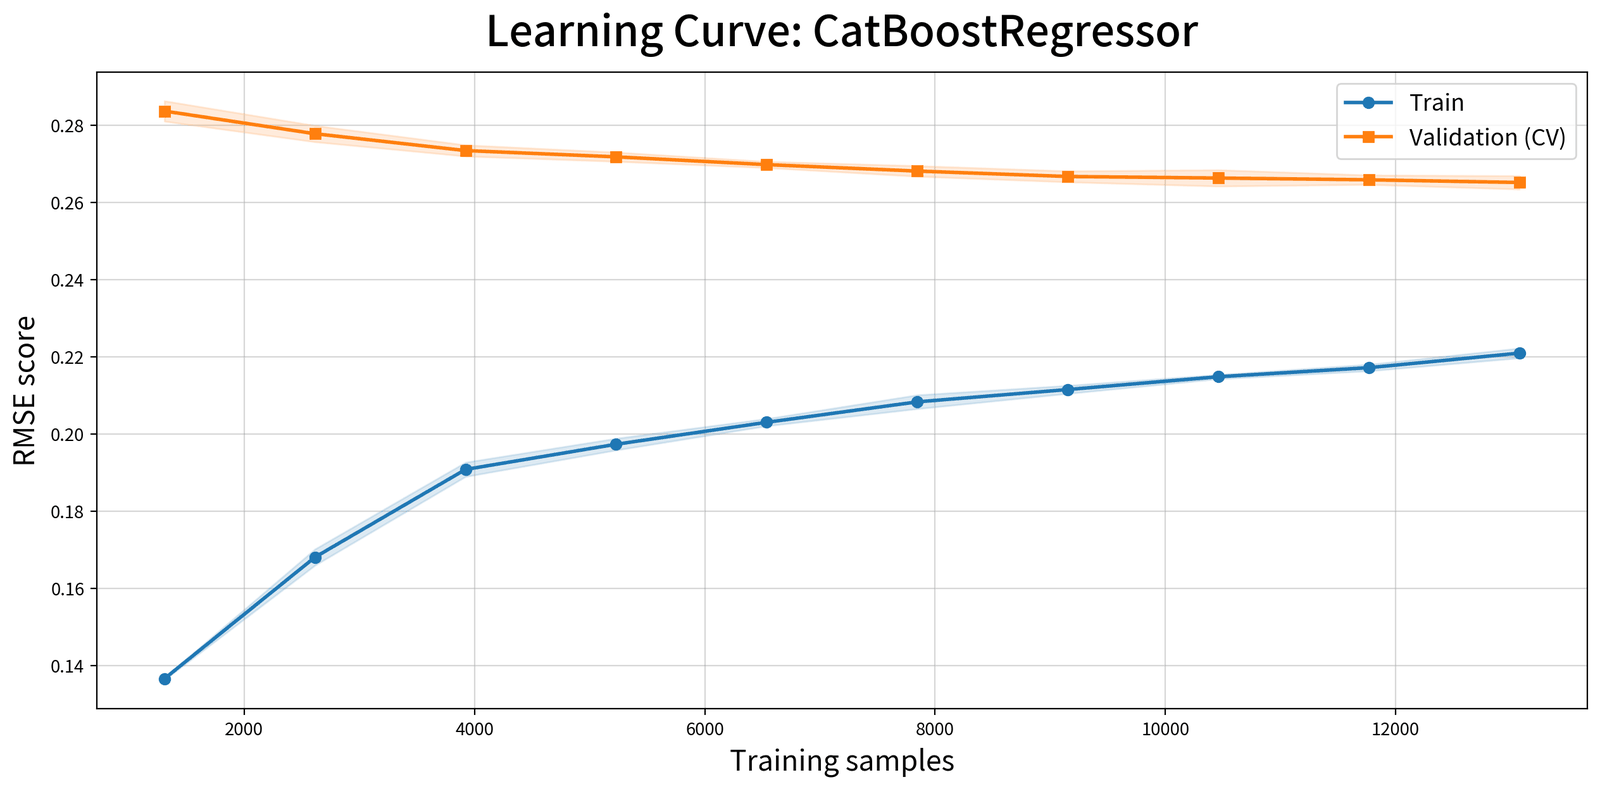


◆ Fit Diagnosis: CatBoostRegressor  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - RMSE    Train=     0.2246  CV=     0.2653 (±0.0016)  Test=     0.2660  Gap%=   15.36%  [과대적합] ⚠

   ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) — 훈련↔CV 격차가 큼
     · train R2=0.8438 (과소적합 기준 < 0.3) · CV R2=0.7818

CPU times: total: 3.59 s
Wall time: 10min 27s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.225,0.265,0.002,0.266,0.041,15.360,과대적합


In [7]:
%%time
model = my_ml.load_model(f"{workdir}/catboost.pkl")
my_ml.reg_overfit(model, x_train, y_train, x_test, y_test, metrics='RMSE', fit_params={'model__cat_features': my_qtcheck.get_categorical_column_names(x_train)})

### #03. Feature Importance

#### 1. Feature Importance 도출

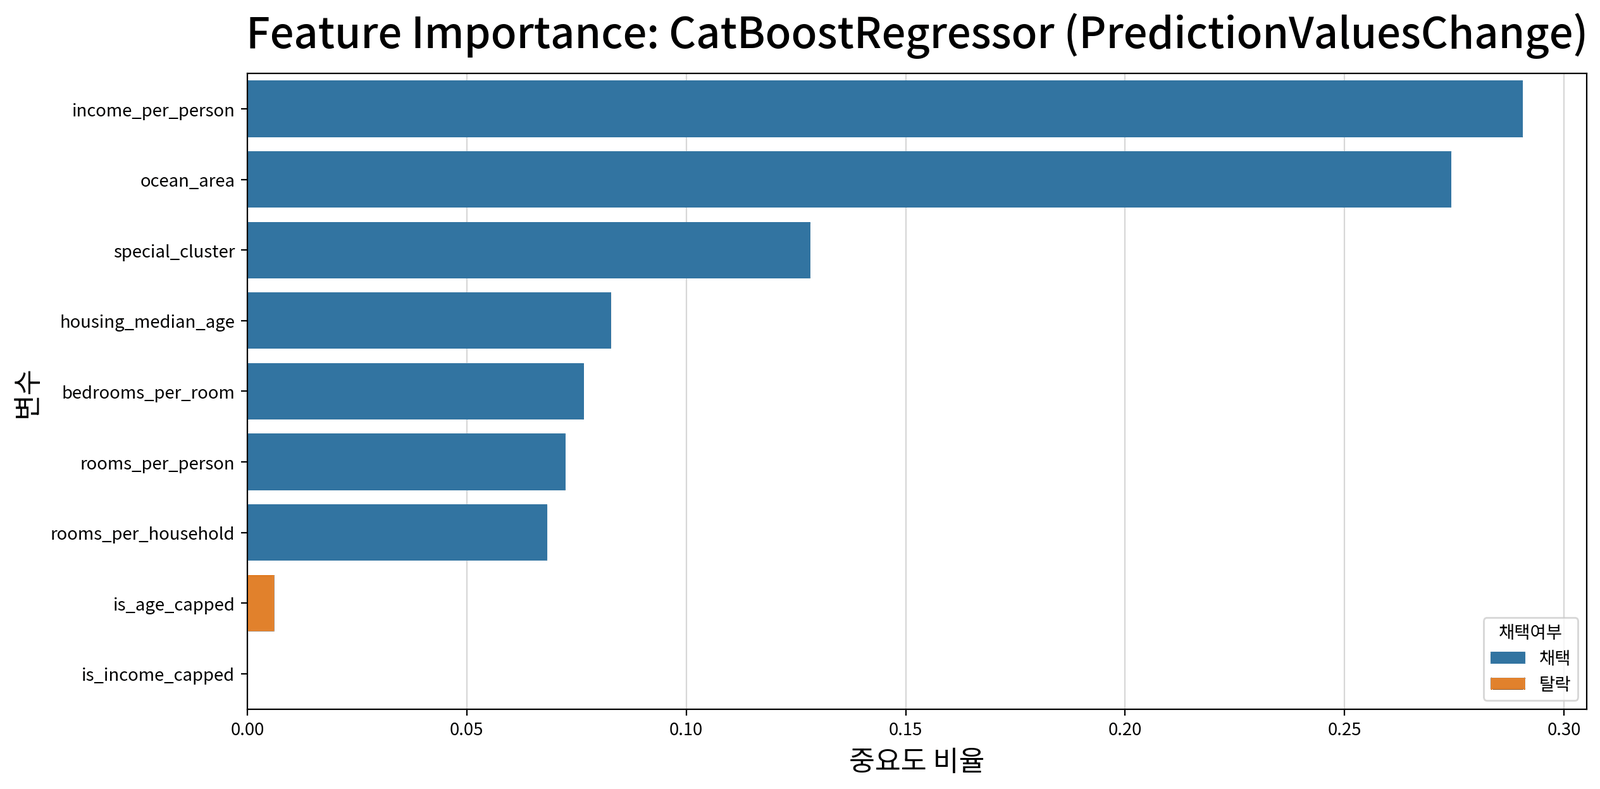


◆ Feature Importance: CatBoostRegressor  (중요도 기준=PredictionValuesChange, 채택 기준=cum_ratio=95%)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   전체 변수 9개 중 7개 채택 (누적 중요도 99.37% 설명)
   ▶ 채택된 변수: ['income_per_person', 'ocean_area', 'special_cluster', 'housing_median_age', 'bedrooms_per_room', 'rooms_per_person', 'rooms_per_household']



,Importance,Ratio,CumRatio,채택여부
Feature,,,,
income_per_person,29.062,0.291,0.291,채택
ocean_area,27.427,0.274,0.565,채택
special_cluster,12.824,0.128,0.693,채택
housing_median_age,8.289,0.083,0.776,채택
bedrooms_per_room,7.676,0.077,0.853,채택
rooms_per_person,7.250,0.073,0.925,채택
rooms_per_household,6.840,0.068,0.994,채택
is_age_capped,0.617,0.006,1.000,탈락
is_income_capped,0.014,0.000,1.000,탈락


In [8]:
model = my_ml.load_model(f"{workdir}/catboost.pkl")
fi = my_ml.feature_importance(model, cum_ratio=0.95)
fi

#### 2. 채택된 변수 추출

- `feature_importance()` 의 반환 표에서 채택/탈락을 확인하고    
   **채택된 변수 목록만** 꺼내 재학습에 사용한다.

In [9]:
# 채택된 변수 목록 (재학습에 사용)
selected = fi.attrs['selected_features']
dropped = [c for c in x_train.columns if c not in selected]

print(f"채택 {len(selected)}개: {selected}")
print(f"탈락 {len(dropped)}개: {dropped}")

채택 7개: ['income_per_person', 'ocean_area', 'special_cluster', 'housing_median_age', 'bedrooms_per_room', 'rooms_per_person', 'rooms_per_household']
탈락 3개: ['population_per_household', 'is_age_capped', 'is_income_capped']


#### 3. 데이터에서 채택된 변수만 추출

In [10]:
# 훈련 데이터에서 채택된 변수만 추출
x_tr = x_train[selected]
display(x_tr.columns)

# 검증 데이터에서 채택된 변수만 추출
x_te = x_test[selected]
display(x_te.columns)

Index(['income_per_person', 'ocean_area', 'special_cluster',
       'housing_median_age', 'bedrooms_per_room', 'rooms_per_person',
       'rooms_per_household'],
      dtype='object')

Index(['income_per_person', 'ocean_area', 'special_cluster',
       'housing_median_age', 'bedrooms_per_room', 'rooms_per_person',
       'rooms_per_household'],
      dtype='object')

#### 4. 베이스모델 재학습

In [11]:
catboost = my_ml.fit_pipeline(
            model=CatBoostRegressor(
                    random_state=RANDOM_STATE, verbose=0),
            x_train=x_tr, y_train=y_train,
            vif=True, 
            encode=False,   # CatBoost는 자체적으로 범주형 처리하므로 encode=False
            # 이름이 `단계명__인자명` 형식인 인자는 모델의 fit 으로 그대로 전달된다
            model__cat_features=my_qtcheck.get_categorical_column_names(x_tr))

display(my_ml.reg_score(catboost, x_te, y_test))

catboost


대상: 16346행 x 7열 | 모델: catboost
명목형: ['ocean_area', 'special_cluster']
연속형: ['income_per_person', 'housing_median_age', 'bedrooms_per_room', 'rooms_per_person', 'rooms_per_household']

전처리 단계
  연속형: 다중공선성 제거(VIF >= 10.0)
  명목형: (변환 없음)

모델 학습 완료: catboost


,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.782,0.195,0.072,0.268,0.021,0.016,-0.000


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### 5. 하이퍼파라미터 튜닝

In [12]:
# 수업용 탐색 조합
param_grid = {
    "model__iterations": [500, 1000],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

# 하이퍼파라미터 튜닝 수행
gs = GridSearchCV(estimator=catboost, param_grid=param_grid,
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

gs.fit(x_tr, y_train,
       model__cat_features=my_qtcheck.get_categorical_column_names(x_tr))

gs.name_ = f"{model.name_}_tuned"   # 튜닝이 완료된 객체에게 모델이름을 부여한다.
my_ml.save_model(gs, f"{savedir}/catboost.pkl") # 튜닝이 완료된 모델을 저장한다.
display(my_ml.reg_score(gs, x_te, y_test))      # 성능 평가

,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE
Model,,,,,,,
CatBoostRegressor,0.785,0.194,0.071,0.266,0.020,0.016,-0.000


#### 6. 과적합 판정

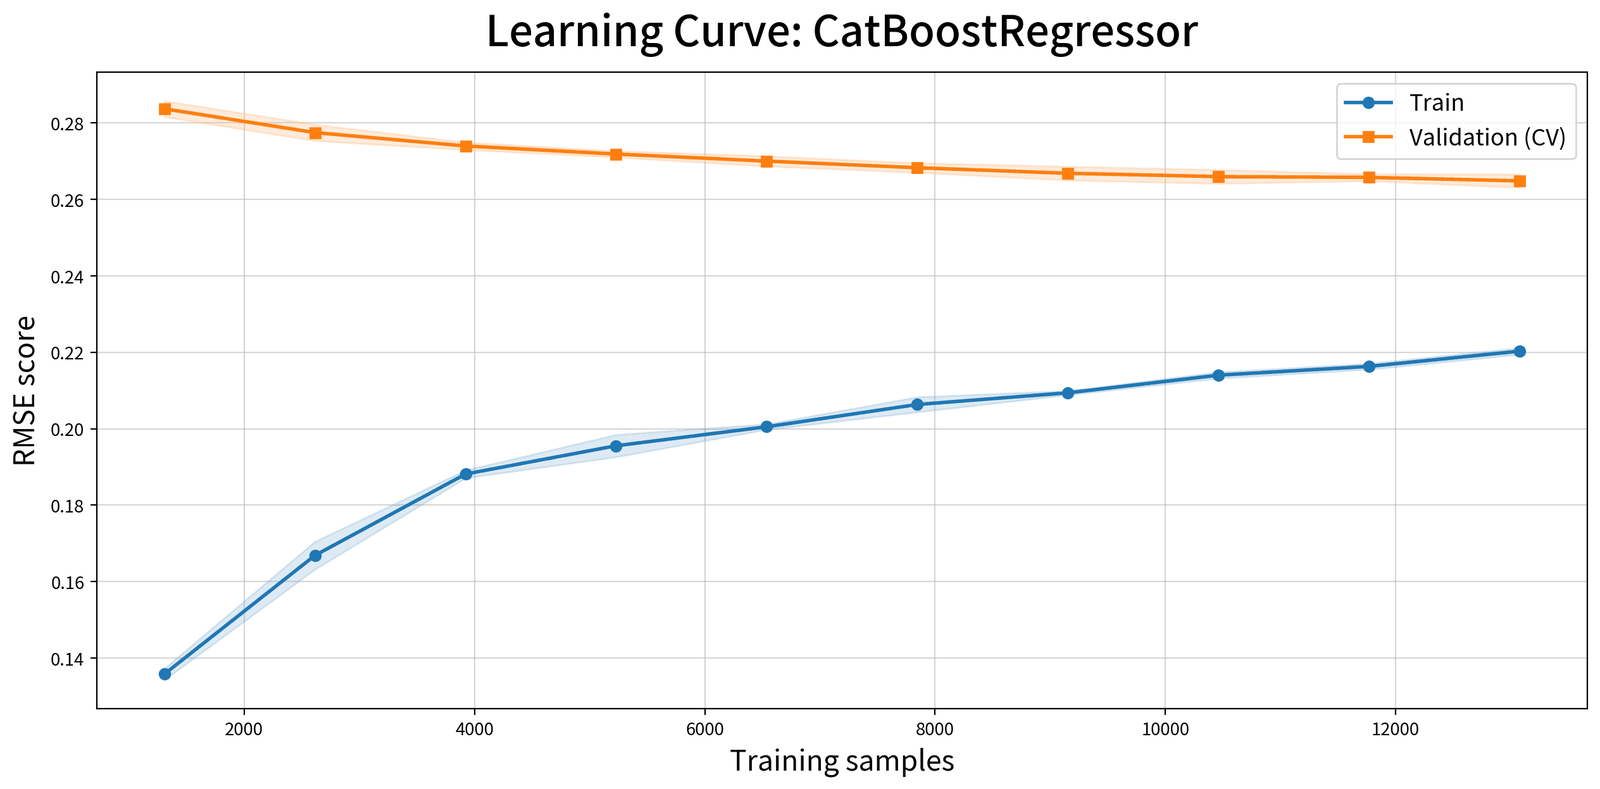


◆ Fit Diagnosis: CatBoostRegressor  (threshold=15%, 기준=Train↔CV 5-Fold)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
   - RMSE    Train=     0.2236  CV=     0.2651 (±0.0016)  Test=     0.2659  Gap%=   15.66%  [과대적합] ⚠

   ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) — 훈련↔CV 격차가 큼
     · train R2=0.8451 (과소적합 기준 < 0.3) · CV R2=0.7822

CPU times: total: 3.81 s
Wall time: 10min 39s


,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.224,0.265,0.002,0.266,0.042,15.660,과대적합


In [13]:
%%time
my_ml.reg_overfit(gs, x_tr, y_train, x_te, y_test, metrics="RMSE", 
    fit_params={'model__cat_features': my_qtcheck.get_categorical_column_names(x_tr)})

### #04 SHAP 분석

#### 1. SHAP Explainer 객체 생성

- 모듈 내부에서 모델 유형에 맞는 Explainer가 생성된다.
- 두 종류의 Summary Plot이 시각화 된다 (Bar Plot과 Beeswarm)

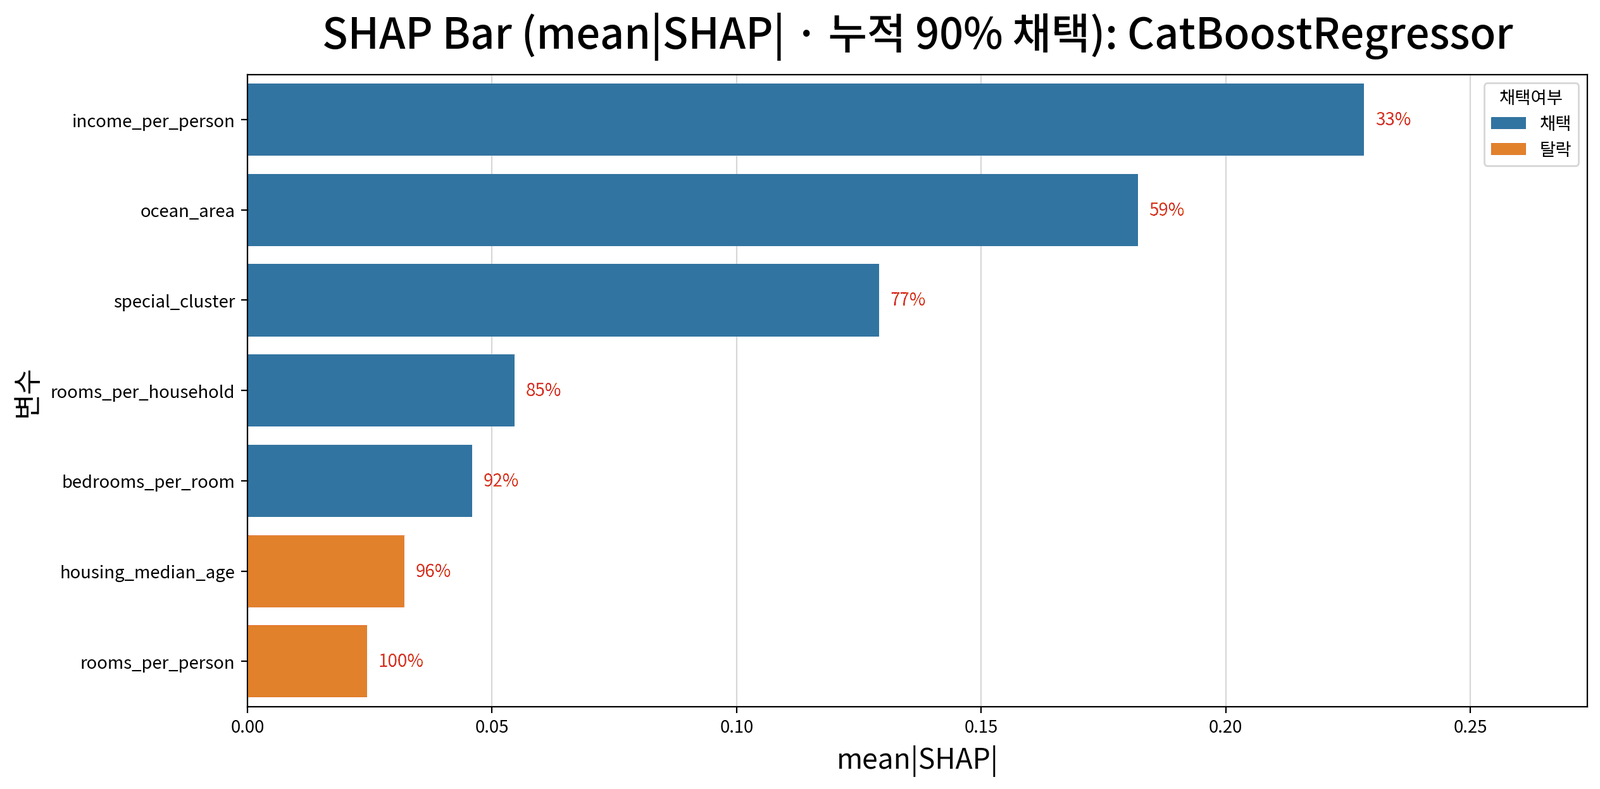

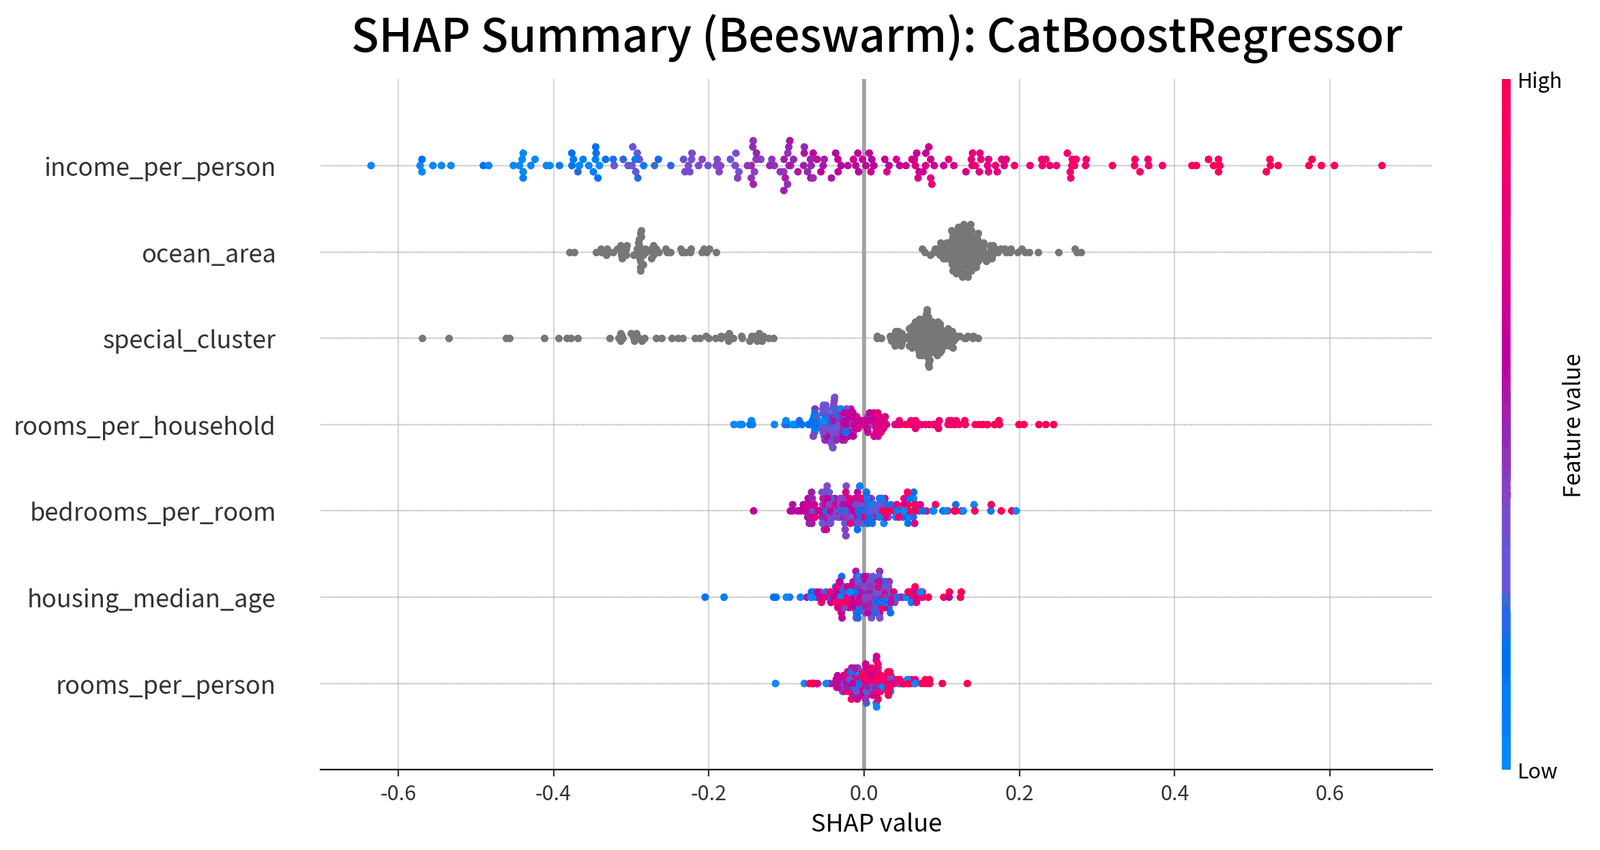


◆ SHAP Analysis: CatBoostRegressor  (TreeExplainer, regression)
   ▷ 탐색 객체의 best_params: {'model__depth': 8, 'model__iterations': 1000, 'model__learning_rate': 0.03}
   설명 표본 200행 × 변수 7개 · base value=12.0859 · SHAP 단위=예측값(y 단위)
   income_per_person      mean|SHAP|=0.2283  방향=감소  비선형/불안정
   ocean_area             mean|SHAP|=0.1820  방향=증가  비선형/불안정
   special_cluster        mean|SHAP|=0.1292  방향=감소  비선형/불안정
   rooms_per_household    mean|SHAP|=0.0547  방향=감소  비선형/불안정
   bedrooms_per_room      mean|SHAP|=0.0460  방향=증가  비선형/불안정



In [14]:
# 앞에서 학습 완료한 최종 모델과 데이터 사용
shap = my_ml.shap_analysis(gs, x_tr)

##### SHAP 요약 — 현재 실행 결과

- 설명 표본은 200행이며 최종 입력 변수는 7개이다.
- mean|SHAP| 상위 변수는 `income_per_person`(0.2283), `ocean_area`(0.1820), `special_cluster`(0.1292), `rooms_per_household`(0.0547), `bedrooms_per_room`(0.0460) 순이다.
- Feature Importance 단계에서 선택된 변수에는 `rooms_per_person`이 포함되고 `population_per_household`는 제외되었다. 이전 실행의 변수 목록과 혼동하지 않는다.
- 소득 대리변수와 입지 변수가 이 모델의 예측 설명에서 상위권에 있다. 이는 인과효과나 특정 비율의 가격 결정력을 뜻하지 않는다.
- SHAP은 로그 예측값 단위이다. 평균 절대 SHAP을 단순히 지수화하여 대칭적인 가격 상승·하락률로 해석하지 않는다.
- 콘솔의 방향 요약만으로 변수의 증가·감소 효과를 단정하지 않고 Beeswarm과 Dependence Plot을 함께 확인한다.
- Feature Importance와 SHAP은 서로 다른 중요도 지표이며, 순위 일치가 독립적인 교차검증이나 변수 제거의 안전성을 보장하지 않는다.


#### 2. Dependence Plot

◆ SHAP Dependence — 변수쌍(주변수 × 상호작용변수) · 선정기준=cum_ratio=90%
   income_per_person  ×  rooms_per_household
   ocean_area  ×  special_cluster
   special_cluster  ×  income_per_person
   rooms_per_household  ×  bedrooms_per_room
   bedrooms_per_room  ×  rooms_per_household


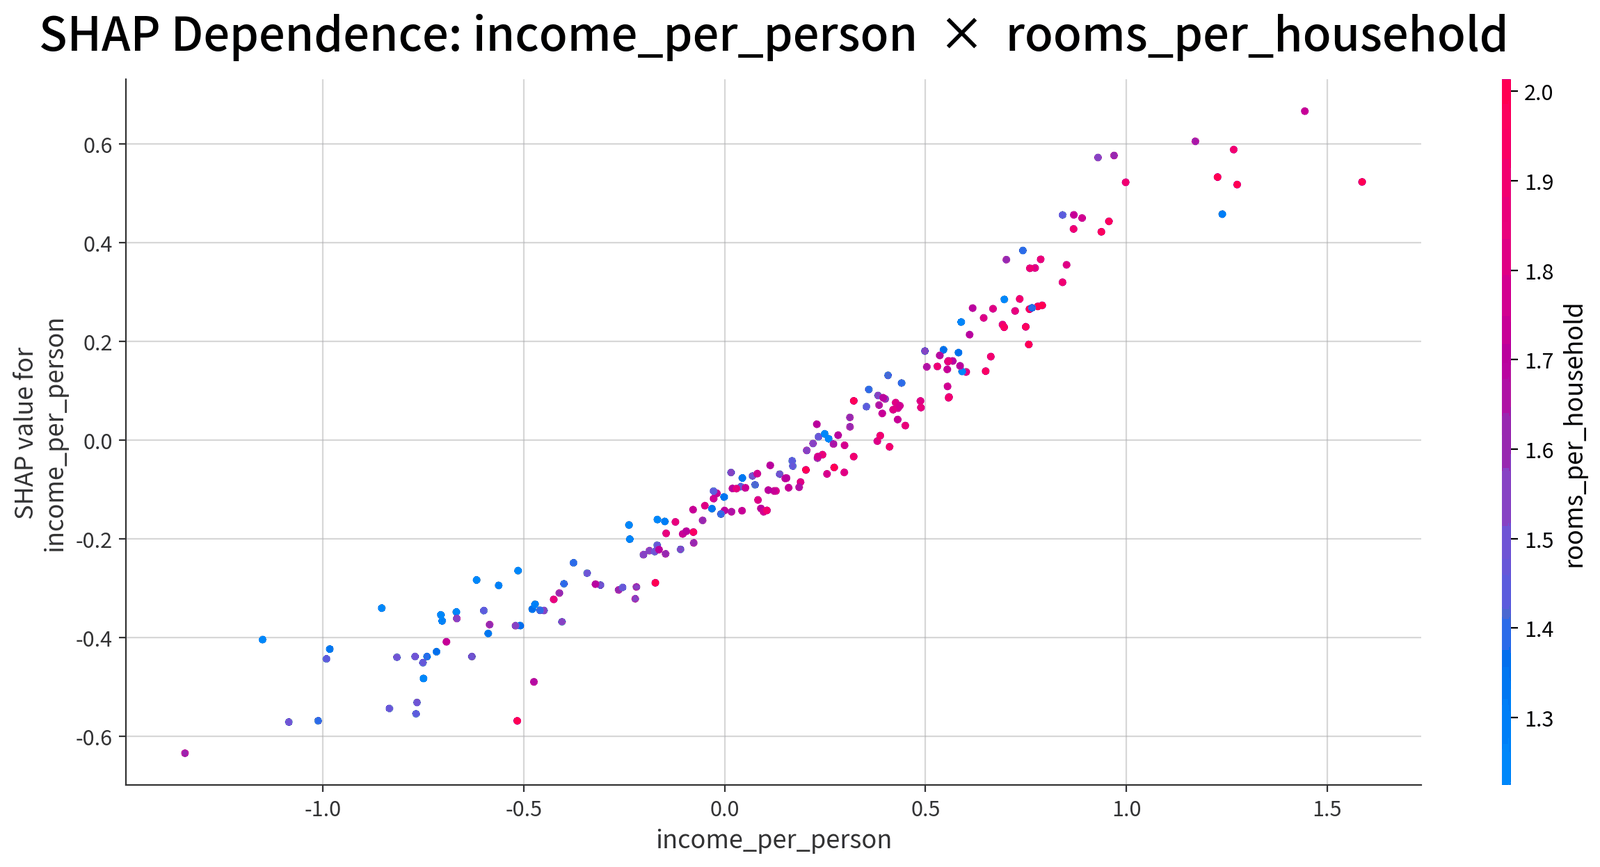

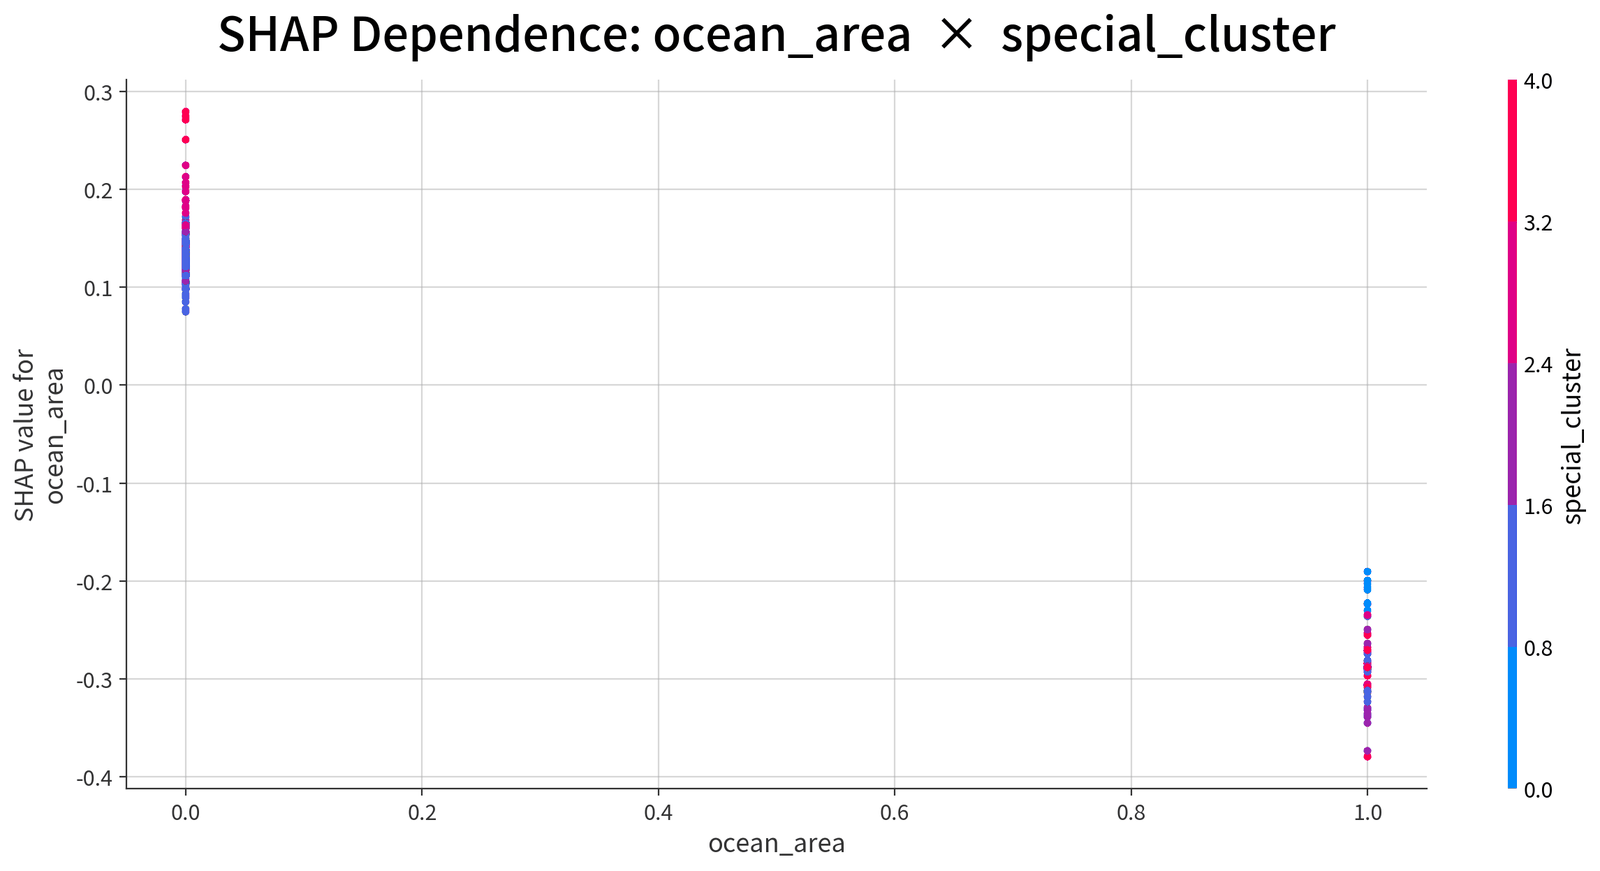

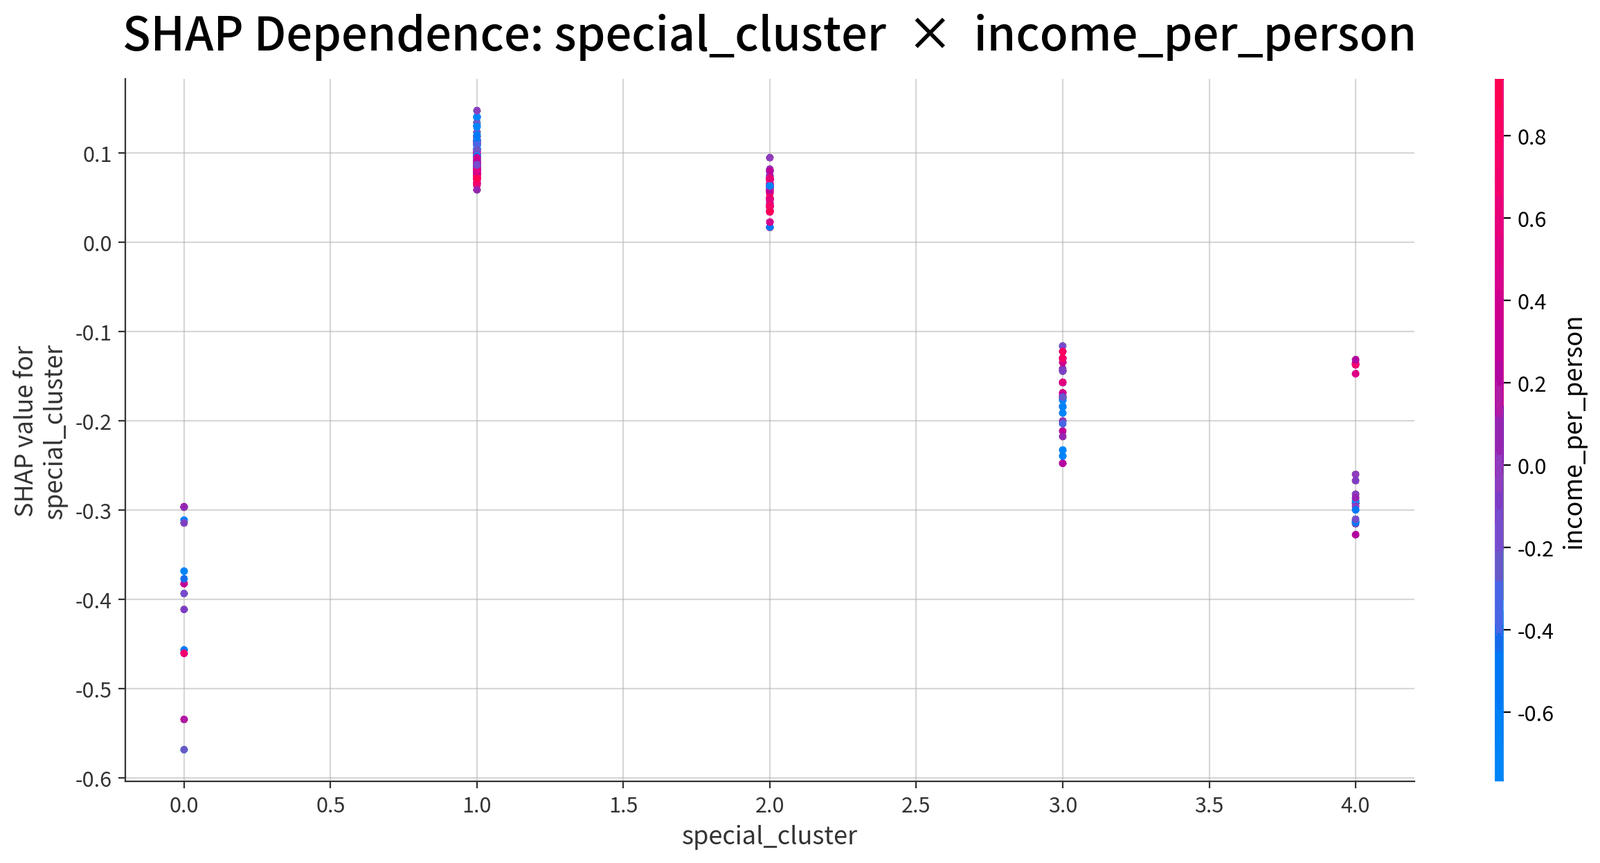

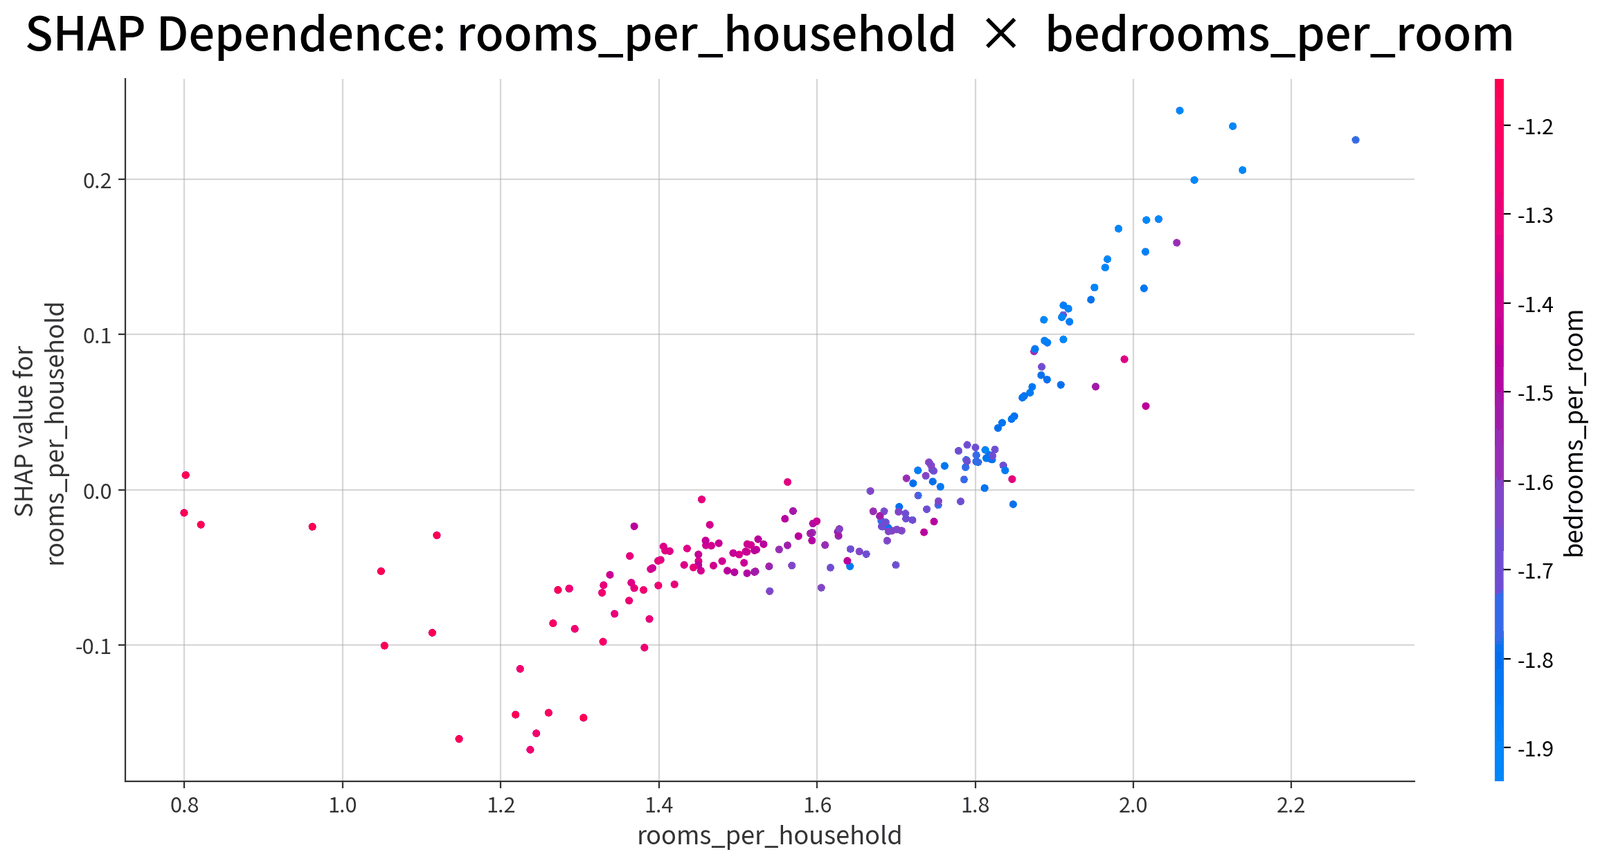

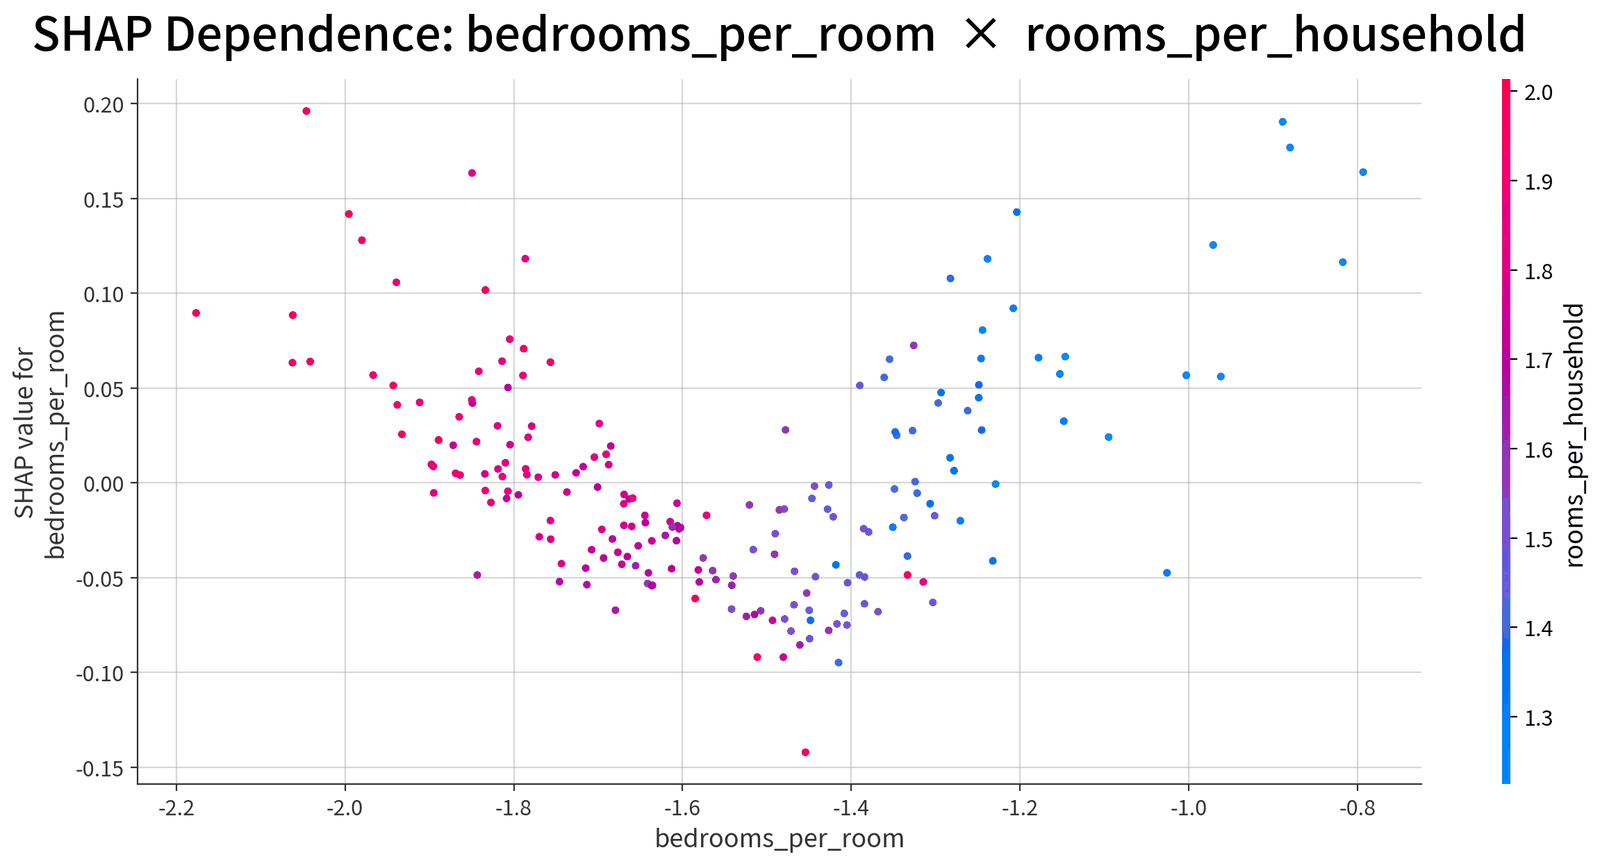

[{'feature': 'income_per_person',
  'interaction_feature': 'rooms_per_household'},
 {'feature': 'ocean_area', 'interaction_feature': 'special_cluster'},
 {'feature': 'special_cluster', 'interaction_feature': 'income_per_person'},
 {'feature': 'rooms_per_household',
  'interaction_feature': 'bedrooms_per_room'},
 {'feature': 'bedrooms_per_room',
  'interaction_feature': 'rooms_per_household'}]

In [15]:
# 데이터는 shap.attrs 에서 읽으므로 훈련데이터를 넘기지 않는다.
# features 를 비워야 cum_ratio/top_k 자동선정이 동작한다.
my_ml.shap_dependence_plot(shap)

##### Dependence Plot — 현재 실행에서 선정된 변수쌍

| 주변수 | 색상으로 표시한 변수 |
|---|---|
| `income_per_person` | `rooms_per_household` |
| `ocean_area` | `special_cluster` |
| `special_cluster` | `income_per_person` |
| `rooms_per_household` | `bedrooms_per_room` |
| `bedrooms_per_room` | `rooms_per_household` |

위 표는 이번 실행의 자동 선정 결과와 일치한다. 각 그래프의 x축은 변수값, y축은 해당 변수의 SHAP 기여도이다. 색상 패턴은 상호작용을 탐색하는 단서이나 그 자체로 상호작용이나 인과관계를 입증하지 않는다. 표본이 적은 구간의 가격 효과나 임계값을 단정하지 않는다.

최종 평가: R² 약 **0.785**, RMSE **0.2659**(로그 척도), 5-Fold CV RMSE **0.2651 ± 0.0016**. 훈련–CV 격차 **15.66%**로 도우미 함수의 15% 경험적 기준에서 과대적합 경고가 남았다. 성능과 이 한계를 함께 보고한다.
